# Final Analysis: PR Merge Outcomes on GitHub

This notebook is the final ADES project narrative. It studies whether PR-level features can help explain and predict GitHub pull request merge outcomes while controlling for target leakage and class imbalance.

## Final answer, read first

PR-level features contain measurable but moderate predictive signal for GitHub PR merge outcomes. The headline model is selected from the regenerated validation comparison using the `headline_leakage_safer_features` policy under a stated prediction-time contract. This stricter headline policy excludes `prior_review_num`; that field is reported only as an integrator-assumed sensitivity check because source documentation describes it as integrator/reviewer experience.

The right conclusion is not that merge outcomes can be predicted perfectly or used for automated decisions. The evidence supports predictive association: contributor history, project context, and PR scope contain useful signal, but feature timing, class imbalance, and generalizability remain the main threats to validity.


## Research question and dataset

**Research question:** Can PR-level features help explain and predict PR merge outcomes on GitHub?

The project uses the Zenodo dataset **GitHub Pull Request Analysis: Sentiment Data and Developer Survey Responses**. The main analysis uses `prfeatures_train_data.csv` and `prfeatures_test_data.csv`, with `merged_or_not` as the locked binary target. The comment and survey files are documented but not used as core inputs because the PR-level task is already well-defined and the timing of comment-derived fields creates leakage risk.


In [1]:
from __future__ import annotations

import hashlib
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit, RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

RANDOM_STATE = 42
TARGET_COLUMN = "merged_or_not"
TARGET_LABELS = {0: "Not merged", 1: "Merged"}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data" / "raw").exists():
            return candidate
    fallback = Path("/Users/mahmoudali/Documents/ADES - first project")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the ADES project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
CHECKPOINT2_DIR = PROJECT_ROOT / "deliverables" / "checkpoint-2"
FINAL_DIR = PROJECT_ROOT / "deliverables" / "final"
FIGURE_DIR = FINAL_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"

metadata_columns = ["project_id", "creator_id", "last_close_time"]

exclude_ids = ["id", "project_id", "creator_id", "last_closer_id"]
exclude_post_outcome = ["last_close_time", "lifetime_minutes", "reopen_or_not"]
ambiguous_features = [
    "num_comments", "has_comments", "num_participants", "core_comment",
    "contrib_comment", "inte_comment", "has_exchange", "at_tag",
    "num_code_comments", "num_code_comments_con", "perc_neg_emotion",
    "perc_pos_emotion", "comment_conflict", "contrib_open", "contrib_cons",
    "contrib_extra", "contrib_agree", "contrib_neur", "inte_open",
    "inte_cons", "inte_extra", "inte_agree", "inte_neur",
    "perc_contrib_pos_emo", "perc_contrib_neg_emo", "perc_inte_pos_emo",
    "perc_inte_neg_emo", "social_strength", "same_user", "ci_build_num",
    "ci_failed_perc", "integrator_availability",
]
headline_safe_features = [
    "first_pr", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "contrib_perc_commit", "sloc", "team_size", "language",
    "open_issue_num", "project_age", "open_pr_num", "fork_num",
    "test_lines_per_kloc", "stars",
    "test_cases_per_kloc", "asserts_per_kloc", "perc_external_contribs",
    "churn_addition", "churn_deletion", "description_length",
    "test_inclusion", "ci_exists", "friday_effect",
]

t0_creation_features = [
    "first_pr", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "contrib_perc_commit", "sloc", "team_size", "language",
    "open_issue_num", "project_age", "open_pr_num", "fork_num",
    "test_lines_per_kloc", "stars",
    "test_cases_per_kloc", "asserts_per_kloc", "perc_external_contribs",
    "description_length", "ci_exists", "friday_effect",
]

ultra_conservative_features = [
    "first_pr", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "language", "project_age", "description_length",
    "test_inclusion", "ci_exists", "friday_effect",
]

integrator_assumed_extension_features = [
    "prior_review_num",
]

timing_assumed_extension_features = [
    "pr_succ_rate", "requester_succ_rate", "num_commits",
    "src_churn", "files_changed", "test_churn",
]

review_process_features = [
    "num_comments", "has_comments", "num_participants", "core_comment",
    "contrib_comment", "inte_comment", "has_exchange", "at_tag",
    "num_code_comments", "num_code_comments_con", "perc_neg_emotion",
    "perc_pos_emotion", "comment_conflict", "contrib_open", "contrib_cons",
    "contrib_extra", "contrib_agree", "contrib_neur", "inte_open",
    "inte_cons", "inte_extra", "inte_agree", "inte_neur",
    "perc_contrib_pos_emo", "perc_contrib_neg_emo", "perc_inte_pos_emo",
    "perc_inte_neg_emo", "social_strength", "same_user", "ci_build_num",
    "ci_failed_perc", "integrator_availability", "prior_review_num",
]

t2_review_process_features = [
    *headline_safe_features,
    *review_process_features,
]

prediction_contracts = {
    "T0_creation": {
        "features": t0_creation_features,
        "label": "PR creation",
        "interpretation": "Earliest defensible model: contributor history, project snapshots, description length, CI presence, and calendar context only.",
    },
    "T1_diff": {
        "features": headline_safe_features,
        "label": "Submitted diff",
        "interpretation": "Headline early-information model: T0 plus initial PR diff/test-inclusion signals under the stated timing contract.",
    },
    "T2_review_process": {
        "features": t2_review_process_features,
        "label": "Review process",
        "interpretation": "Late-stage process model: adds comments, discussion, CI-progress, and reviewer/integrator context after review has started.",
    },
}

integrator_assumed_features = [
    *headline_safe_features,
    *integrator_assumed_extension_features,
]

extended_timing_assumed_features = [
    *headline_safe_features,
    *timing_assumed_extension_features,
]

# Backward-compatible aliases used by the Checkpoint 2 notebook and helper
# defaults. In the final notebook, these represent the headline leakage-safer policy.
candidate_safe_features = headline_safe_features
questionable_timing_features = timing_assumed_extension_features
strict_safe_features = headline_safe_features

safe_usecols = [TARGET_COLUMN, *headline_safe_features]
ultra_conservative_usecols = [TARGET_COLUMN, *ultra_conservative_features]
integrator_assumed_usecols = [TARGET_COLUMN, *integrator_assumed_features]
extended_usecols = [TARGET_COLUMN, *extended_timing_assumed_features]
analysis_usecols = [
    TARGET_COLUMN,
    *dict.fromkeys([
        *extended_timing_assumed_features,
        *integrator_assumed_extension_features,
        *review_process_features,
    ]),
]
analysis_load_usecols = [*metadata_columns, *analysis_usecols]
strict_safe_usecols = safe_usecols

binary_features = [
    "first_pr", "core_member", "test_inclusion", "ci_exists", "friday_effect"
]
categorical_features = ["language"]
numeric_features = [
    feature for feature in candidate_safe_features
    if feature not in binary_features and feature not in categorical_features
]

safe_feature_timing_reason = {
    "first_pr": "Contributor history flag available before or at PR submission.",
    "prior_review_num": "Integrator/reviewer history count; held out of the headline model because it may require knowing the eventual reviewer/integrator before the final decision.",
    "core_member": "Author role/affiliation metadata available before review outcome.",
    "prior_interaction": "Historical author-integrator interaction count before the current PR outcome.",
    "followers": "Contributor profile context available at PR submission.",
    "prev_pullreqs": "Contributor historical PR count before the current PR outcome.",
    "account_creation_days": "Contributor account age at PR submission.",
    "contrib_perc_commit": "Contributor historical share of project commits before the current PR outcome.",
    "sloc": "Project size snapshot available independently of the current PR closure.",
    "team_size": "Project/team context available before the current PR outcome.",
    "language": "Project language category available before modeling; treated as nominal.",
    "open_issue_num": "Project issue-count snapshot used as pre-outcome project context.",
    "project_age": "Repository age at PR submission.",
    "open_pr_num": "Project open-PR workload snapshot; used only under the assumption it is measured at or before PR submission.",
    "fork_num": "Repository popularity/context snapshot available before the current PR outcome.",
    "pr_succ_rate": "Target-adjacent historical project PR success rate; held for timing-assumed sensitivity unless pre-PR computation is verified.",
    "test_lines_per_kloc": "Project test-density snapshot available before closure.",
    "stars": "Repository popularity snapshot available before the current PR outcome.",
    "test_cases_per_kloc": "Project test-density snapshot available before closure.",
    "asserts_per_kloc": "Project test/assertion-density snapshot available before closure.",
    "perc_external_contribs": "Historical project contributor-mix rate before the current PR outcome.",
    "requester_succ_rate": "Target-adjacent requester merge-success rate; held for timing-assumed sensitivity unless pre-PR computation is verified.",
    "churn_addition": "Initial PR diff size available after submission and before final closure.",
    "churn_deletion": "Initial PR diff size available after submission and before final closure.",
    "description_length": "PR description length available at submission.",
    "test_inclusion": "Initial PR diff/test-inclusion flag available before final closure.",
    "ci_exists": "Repository CI configuration/availability flag, not a CI outcome.",
    "test_churn": "PR evolution/test-churn field treated as timing-sensitive because source docs distinguish open-time and close-time variants.",
    "num_commits": "PR evolution field treated as timing-sensitive because source docs describe the unsuffixed version as close-time commit count.",
    "src_churn": "PR evolution field treated as timing-sensitive because source docs distinguish open-time and close-time source churn.",
    "files_changed": "PR evolution field treated as timing-sensitive because source docs distinguish open-time and close-time file-change counts.",
    "friday_effect": "Submission calendar flag available immediately at PR creation.",
}

feature_source_notes = {
    "zenodo_prfeatures": "Zenodo PRFeatures record: 80/20 split, 72 PR-related variables, language label encoding, preprocessing notes.",
    "msr2020_dataset": "Zhang, Rastogi, and Yu MSR 2020 dataset paper: Table 1 describes contributor, project, pull-request, and CI factors.",
    "gitlink_field_readme": "new_pullreq field README: field-level timing notes distinguish submission-time snapshots from close-time PR evolution fields.",
    "tse2022_decisions": "Zhang et al. TSE 2022 PR-decision paper: discusses pull-request decision factors and integrator experience.",
}

feature_timing_evidence_records = {
    "first_pr": ("contributor_history", "pre-pr contributor history", "Contributor first-PR flag before or at PR submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "core_member": ("contributor_history", "pre-pr contributor/project role", "Contributor core-member flag before review outcome.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "prior_interaction": ("contributor_history", "historical interaction", "Contributor-project interaction count from prior three months.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "followers": ("contributor_history", "profile snapshot", "Contributor profile context at PR submission.", "low", "headline", "GitLink README"),
    "prev_pullreqs": ("contributor_history", "pre-pr contributor history", "Contributor previous PR count before the current PR.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "account_creation_days": ("contributor_history", "pre-pr contributor history", "Account age at PR creation.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "contrib_perc_commit": ("contributor_history", "historical contribution share", "Contributor share of project commits before the current PR outcome.", "medium", "headline", "GitLink README"),
    "sloc": ("project_context", "submission-time project snapshot", "Project source lines of code at PR submission.", "low", "headline", "GitLink README"),
    "team_size": ("project_context", "submission-time project snapshot", "Core developer count at PR submission.", "low", "headline", "GitLink README"),
    "language": ("project_context", "project metadata", "Main project language; encoded as nominal category.", "low", "headline", "MSR 2020 Table 1; Zenodo record"),
    "open_issue_num": ("project_context", "submission-time project snapshot", "Open issue count when submitting the PR.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "project_age": ("project_context", "submission-time project snapshot", "Project age at PR creation.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "open_pr_num": ("project_context", "submission-time project snapshot", "Open PR workload when submitting the PR.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "fork_num": ("project_context", "submission-time project snapshot", "Fork count when submitting the PR.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "test_lines_per_kloc": ("testing_context", "submission-time project snapshot", "Project test-code density at PR submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "stars": ("project_context", "submission-time project snapshot", "Repository star/watch count at PR submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "test_cases_per_kloc": ("testing_context", "submission-time project snapshot", "Project test-case density at PR submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "asserts_per_kloc": ("testing_context", "submission-time project snapshot", "Project assertion density at PR submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "perc_external_contribs": ("project_context", "submission-time project snapshot", "External contributor percentage at PR submission.", "low", "headline", "GitLink README"),
    "churn_addition": ("pr_scope", "submission-time PR diff", "Added lines at PR submission according to field README.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "churn_deletion": ("pr_scope", "submission-time PR diff", "Deleted lines at PR submission according to field README.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "description_length": ("pr_scope", "submission-time PR text", "PR description length available at submission.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "test_inclusion": ("testing_context", "submission-time PR diff", "Whether the submitted PR includes test code.", "low", "headline", "MSR 2020 Table 1; GitLink README"),
    "ci_exists": ("testing_context", "CI presence, not CI result", "Whether the PR/repository uses CI; CI outcome fields remain held back.", "medium", "headline", "MSR 2020 Table 1; GitLink README"),
    "friday_effect": ("calendar", "submission-time calendar", "Whether PR was submitted on Friday.", "low", "headline", "GitLink README"),
    "prior_review_num": ("integrator_assumed", "integrator history", "Prior reviews of an integrator; held back because the eventual integrator may be unknown at prediction time.", "high", "sensitivity_only", "MSR 2020 Table 1; TSE 2022"),
    "pr_succ_rate": ("target_adjacent", "historical project outcome rate", "Project PR acceptance rate; held back as target-adjacent unless pre-PR computation is verified.", "high", "sensitivity_only", "MSR 2020 Table 1; GitLink README"),
    "requester_succ_rate": ("target_adjacent", "historical requester outcome rate", "Contributor PR success rate; held back as target-adjacent unless pre-PR computation is verified.", "high", "sensitivity_only", "GitLink README"),
    "num_commits": ("close_time_pr_evolution", "close-time PR state", "Commit count at PR close; not part of headline model.", "high", "sensitivity_only", "GitLink README"),
    "src_churn": ("close_time_pr_evolution", "close-time PR state", "Source churn at PR close; not part of headline model.", "high", "sensitivity_only", "GitLink README"),
    "files_changed": ("close_time_pr_evolution", "close-time PR state", "Changed file count at PR close; not part of headline model.", "high", "sensitivity_only", "GitLink README"),
    "test_churn": ("close_time_pr_evolution", "close-time PR state", "Test churn at PR close; not part of headline model.", "high", "sensitivity_only", "GitLink README"),
}

feature_family_groups = {
    "contributor_history": [
        "first_pr", "core_member", "prior_interaction", "followers",
        "prev_pullreqs", "account_creation_days", "contrib_perc_commit",
    ],
    "project_context": [
        "sloc", "team_size", "open_issue_num", "project_age",
        "open_pr_num", "fork_num", "stars", "perc_external_contribs",
    ],
    "pr_scope": ["churn_addition", "churn_deletion", "description_length"],
    "testing_ci_context": [
        "test_lines_per_kloc", "test_cases_per_kloc", "asserts_per_kloc",
        "test_inclusion", "ci_exists",
    ],
    "language_calendar": ["language", "friday_effect"],
}


def availability_reason(feature_name: str) -> str:
    return safe_feature_timing_reason.get(
        feature_name,
        "Conservative pre-outcome PR-level feature retained for modeling.",
    )


def target_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    return pd.DataFrame(
        {
            "split": split,
            "target_value": counts.index,
            "label": [TARGET_LABELS[int(value)] for value in counts.index],
            "count": counts.values,
            "percentage": (counts.values / len(df) * 100).round(2),
        }
    )


def stratified_sample(df: pd.DataFrame, n: int | None, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if n is None or n >= len(df):
        return df.copy()
    _, sample = train_test_split(
        df,
        test_size=n,
        stratify=df[TARGET_COLUMN],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)


def feature_type_groups(feature_list: list[str] | None = None) -> tuple[list[str], list[str], list[str]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    selected_binary = [feature for feature in binary_features if feature in selected_features]
    selected_categorical = [feature for feature in categorical_features if feature in selected_features]
    selected_numeric = [
        feature for feature in selected_features
        if feature not in selected_binary and feature not in selected_categorical
    ]
    return selected_numeric, selected_binary, selected_categorical


def make_preprocessor(feature_list: list[str] | None = None) -> ColumnTransformer:
    selected_numeric, selected_binary, selected_categorical = feature_type_groups(feature_list)
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), selected_numeric),
            ("binary", SimpleImputer(strategy="most_frequent"), selected_binary),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), selected_categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_models(y_train: pd.Series, feature_list: list[str] | None = None) -> dict[str, Pipeline]:
    models: dict[str, Pipeline] = {
        "Dummy majority": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic regression balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Decision tree balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=80,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random forest balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", RandomForestClassifier(
                n_estimators=80,
                max_depth=14,
                min_samples_leaf=60,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "Hist gradient boosting weighted": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", HistGradientBoostingClassifier(
                max_iter=140,
                max_leaf_nodes=31,
                learning_rate=0.08,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            )),
        ]),
    }
    return models


def score_merged_probability(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    elif hasattr(pipeline[-1], "decision_function"):
        decision = pipeline.decision_function(X)
        return 1 / (1 + np.exp(-decision))
    return pipeline.predict(X).astype(float)


def predict_with_not_merged_threshold(
    pipeline: Pipeline,
    X: pd.DataFrame,
    threshold: float,
) -> np.ndarray:
    score_not_merged = 1 - score_merged_probability(pipeline, X)
    return np.where(score_not_merged >= threshold, 0, 1)


def score_predictions(
    name: str,
    y: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str = "default_model_threshold",
    threshold_value: float | None = None,
) -> dict[str, object]:
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    try:
        roc_auc = roc_auc_score(y, y_score_merged)
    except ValueError:
        roc_auc = np.nan
    try:
        average_precision_not_merged = average_precision_score(1 - y, 1 - y_score_merged)
    except ValueError:
        average_precision_not_merged = np.nan

    return {
        "model": name,
        "threshold_label": threshold_label,
        "threshold_value": threshold_value,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_not_merged": precision_score(y, y_pred, pos_label=0, zero_division=0),
        "recall_not_merged": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "f1_not_merged": f1_score(y, y_pred, pos_label=0, zero_division=0),
        "precision_merged": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_merged": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_merged": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "roc_auc_merged": roc_auc,
        "average_precision_not_merged": average_precision_not_merged,
        "actual_not_merged_predicted_not_merged": int(cm[0, 0]),
        "actual_not_merged_predicted_merged": int(cm[0, 1]),
        "actual_merged_predicted_not_merged": int(cm[1, 0]),
        "actual_merged_predicted_merged": int(cm[1, 1]),
        "actual_not_merged": int(cm[0, :].sum()),
        "actual_merged": int(cm[1, :].sum()),
        "predicted_not_merged": int(cm[:, 0].sum()),
        "predicted_merged": int(cm[:, 1].sum()),
        "correct_not_merged": int(cm[0, 0]),
        "missed_not_merged": int(cm[0, 1]),
        "false_not_merged": int(cm[1, 0]),
        "correct_merged": int(cm[1, 1]),
    }


def score_pipeline(
    name: str,
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float | None = None,
    threshold_label: str = "default_model_threshold",
) -> dict[str, object]:
    y_score_merged = score_merged_probability(pipeline, X)
    if threshold is None:
        y_pred = pipeline.predict(X)
        threshold_value = None
    else:
        y_pred = predict_with_not_merged_threshold(pipeline, X, threshold)
        threshold_value = float(threshold)
    return score_predictions(
        name,
        y,
        y_pred,
        y_score_merged,
        threshold_label=threshold_label,
        threshold_value=threshold_value,
    )


def add_metric_metadata(
    row_or_df: dict[str, object] | pd.DataFrame,
    *,
    feature_policy: str,
    feature_count: int,
    source_rows: int,
    training_rows: int,
    validation_rows: int | None,
    training_scope: str,
) -> dict[str, object] | pd.DataFrame:
    metadata = {
        "feature_policy": feature_policy,
        "feature_count": feature_count,
        "source_rows": source_rows,
        "training_rows": training_rows,
        "validation_rows": validation_rows,
        "training_scope": training_scope,
    }
    if isinstance(row_or_df, pd.DataFrame):
        df = row_or_df.copy()
        for column, value in reversed(metadata.items()):
            df.insert(0, column, value)
        return df
    return {**metadata, **row_or_df}


def fit_pipeline(name: str, pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    fitted_pipeline = clone(pipeline)
    if name == "Hist gradient boosting weighted":
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        fitted_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight)
    else:
        fitted_pipeline.fit(X_train, y_train)
    return fitted_pipeline


def fit_and_compare(
    train_df: pd.DataFrame,
    model_sample_size: int | None,
    validation_size: float = 0.25,
    feature_list: list[str] | None = None,
    feature_policy: str = "headline_leakage_safer_features",
) -> tuple[pd.DataFrame, dict[str, Pipeline], tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    model_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = model_df[selected_features]
    y = model_df[TARGET_COLUMN]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=validation_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    models = build_models(y_train, selected_features)
    fitted: dict[str, Pipeline] = {}
    rows: list[dict[str, object]] = []

    for name, pipeline in models.items():
        fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
        fitted[name] = fitted_pipeline
        rows.append(score_pipeline(name, fitted_pipeline, X_valid, y_valid))

    training_scope = (
        "full_source_internal_validation"
        if model_sample_size is None or len(model_df) == len(train_df)
        else f"stratified_sample_{len(model_df)}"
    )
    comparison = pd.DataFrame(rows).sort_values(
        ["f1_not_merged", "balanced_accuracy", "average_precision_not_merged"],
        ascending=False,
    )
    comparison = add_metric_metadata(
        comparison.reset_index(drop=True),
        feature_policy=feature_policy,
        feature_count=len(selected_features),
        source_rows=len(train_df),
        training_rows=len(X_train),
        validation_rows=len(X_valid),
        training_scope=training_scope,
    )
    return comparison, fitted, (X_train, X_valid, y_train, y_valid)


def threshold_tuning_table(pipeline: Pipeline, X_valid: pd.DataFrame, y_valid: pd.Series) -> pd.DataFrame:
    score_not_merged = 1 - score_merged_probability(pipeline, X_valid)
    precision, recall, thresholds = precision_recall_curve(1 - y_valid, score_not_merged)
    table = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision_not_merged": precision[:-1],
            "recall_not_merged": recall[:-1],
        }
    )
    table["f1_not_merged"] = (
        2 * table["precision_not_merged"] * table["recall_not_merged"]
        / (table["precision_not_merged"] + table["recall_not_merged"]).replace(0, np.nan)
    ).fillna(0)
    table = table.sort_values(
        ["f1_not_merged", "recall_not_merged", "precision_not_merged"],
        ascending=[False, False, False],
    )
    return table.reset_index(drop=True)


def repeated_validation_summary(
    train_df: pd.DataFrame,
    model_sample_size: int,
    feature_list: list[str] | None = None,
    feature_policy: str = "headline_leakage_safer_features",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    cv_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = cv_df[selected_features]
    y = cv_df[TARGET_COLUMN]
    cv_n_splits = 3
    splitter = RepeatedStratifiedKFold(n_splits=cv_n_splits, n_repeats=2, random_state=RANDOM_STATE)
    rows: list[dict[str, object]] = []
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        for name, pipeline in build_models(y_train, selected_features).items():
            fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
            row = score_pipeline(name, fitted_pipeline, X_valid, y_valid)
            row["fold"] = fold_number
            row["feature_policy"] = feature_policy
            row["feature_count"] = len(selected_features)
            row["source_rows"] = len(train_df)
            row["training_rows"] = len(X_train)
            row["validation_rows"] = len(X_valid)
            row["training_scope"] = f"{len(cv_df)}_row_repeated_cv_diagnostic"
            rows.append(row)
    fold_scores = pd.DataFrame(rows)
    metric_columns = [
        "accuracy", "balanced_accuracy", "precision_not_merged",
        "recall_not_merged", "f1_not_merged", "roc_auc_merged",
        "average_precision_not_merged",
    ]
    summary = (
        fold_scores.groupby("model")[metric_columns]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = [
        column[0] if column[1] == "" else f"{column[0]}_{column[1]}"
        for column in summary.columns.to_flat_index()
    ]
    summary = summary.sort_values(
        [
            "f1_not_merged_mean",
            "balanced_accuracy_mean",
            "average_precision_not_merged_mean",
        ],
        ascending=False,
    ).reset_index(drop=True)
    summary.insert(1, "cv_folds", 6)
    summary.insert(2, "model_sample_size", len(cv_df))
    summary.insert(3, "feature_policy", feature_policy)
    summary.insert(4, "feature_count", len(selected_features))
    summary.insert(5, "source_rows", len(train_df))
    summary.insert(6, "training_rows", len(cv_df) * (cv_n_splits - 1) // cv_n_splits)
    summary.insert(7, "validation_rows", len(cv_df) // cv_n_splits)
    summary.insert(8, "training_scope", f"{len(cv_df)}_row_repeated_cv_diagnostic")
    return summary, fold_scores


def bootstrap_metric_intervals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str,
    point_estimates: dict[str, float] | None = None,
    n_resamples: int = 500,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    y_score_array = np.asarray(y_score_merged)
    metric_rows: list[dict[str, float | str]] = []
    samples: dict[str, list[float]] = {
        "precision_not_merged": [],
        "recall_not_merged": [],
        "f1_not_merged": [],
        "balanced_accuracy": [],
        "roc_auc_merged": [],
    }
    for _ in range(n_resamples):
        indices = rng.integers(0, len(y_true_array), len(y_true_array))
        y_boot = y_true_array[indices]
        pred_boot = y_pred_array[indices]
        score_boot = y_score_array[indices]
        samples["precision_not_merged"].append(precision_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["recall_not_merged"].append(recall_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["f1_not_merged"].append(f1_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["balanced_accuracy"].append(balanced_accuracy_score(y_boot, pred_boot))
        if len(np.unique(y_boot)) == 2:
            samples["roc_auc_merged"].append(roc_auc_score(y_boot, score_boot))
    for metric, values in samples.items():
        clean_values = np.asarray([value for value in values if not pd.isna(value)])
        metric_rows.append(
            {
                "threshold_label": threshold_label,
                "metric": metric,
                "estimate": float(point_estimates.get(metric, np.mean(clean_values)) if point_estimates else np.mean(clean_values)),
                "bootstrap_mean": float(np.mean(clean_values)),
                "ci_lower_95": float(np.quantile(clean_values, 0.025)),
                "ci_upper_95": float(np.quantile(clean_values, 0.975)),
                "bootstrap_resamples": n_resamples,
            }
        )
    return pd.DataFrame(metric_rows)


def feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocess"]
    return preprocessor.get_feature_names_out()


def feature_importance_table(pipeline: Pipeline) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    names = feature_names_from_pipeline(pipeline)
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_[0])
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def raw_data_fingerprint(paths: dict[str, Path]) -> pd.DataFrame:
    rows = []
    for label, path in paths.items():
        header = pd.read_csv(path, nrows=0)
        first_column = header.columns[0]
        row_count = sum(
            len(chunk)
            for chunk in pd.read_csv(
                path,
                usecols=[first_column],
                chunksize=250_000,
                low_memory=False,
            )
        )
        rows.append(
            {
                "dataset": label,
                "path": str(path.relative_to(PROJECT_ROOT)),
                "bytes": path.stat().st_size,
                "rows": row_count,
                "columns": len(header.columns),
                "sha256": file_sha256(path),
                "header_preview": ", ".join(header.columns[:8]),
            }
        )
    return pd.DataFrame(rows)


def feature_timing_evidence_table() -> pd.DataFrame:
    rows = []
    ordered_features = [
        *headline_safe_features,
        *integrator_assumed_extension_features,
        *timing_assumed_extension_features,
    ]
    for feature in ordered_features:
        family, timing, evidence, risk, model_role, source = feature_timing_evidence_records[feature]
        rows.append(
            {
                "feature": feature,
                "feature_family": family,
                "documented_timing": timing,
                "evidence": evidence,
                "risk_level": risk,
                "model_role": model_role,
                "source": source,
            }
        )
    return pd.DataFrame(rows)


def prediction_contract_feature_map_table() -> pd.DataFrame:
    availability_by_contract = {
        "T0_creation": "available at PR creation or from prior contributor/project history",
        "T1_diff": "available after the submitted PR diff is visible, before final closure",
        "T2_review_process": "available only after review/discussion/CI process has started",
    }
    rows = []
    seen: set[tuple[str, str]] = set()
    for contract_name, contract in prediction_contracts.items():
        for feature in contract["features"]:
            key = (contract_name, feature)
            if key in seen:
                continue
            seen.add(key)
            family, timing, evidence, risk, role, source = feature_timing_evidence_records.get(
                feature,
                (
                    "review_process",
                    "during-review process",
                    "Review, discussion, CI-progress, or integrator-context field; excluded from earlier contracts.",
                    "high" if contract_name == "T2_review_process" else "medium",
                    "review_stage",
                    "PRFeatures schema",
                ),
            )
            rows.append(
                {
                    "contract": contract_name,
                    "contract_label": contract["label"],
                    "feature": feature,
                    "feature_family": family,
                    "availability": availability_by_contract[contract_name],
                    "documented_timing": timing,
                    "risk_level": risk,
                    "model_role": role if contract_name != "T2_review_process" else "review_process",
                    "rationale": evidence,
                    "source": source,
                }
            )
    return pd.DataFrame(rows)


def review_process_feature_audit_table() -> pd.DataFrame:
    included = set(review_process_features)
    rows = []
    for feature in [*ambiguous_features, *integrator_assumed_extension_features]:
        rows.append(
            {
                "feature": feature,
                "stage": "T2_review_process" if feature in included else "held_back",
                "included_in_t2": feature in included,
                "excluded_from_early_reason": (
                    "This field can encode review discussion, participant behavior, CI progress, "
                    "or reviewer/integrator context that is unavailable at PR creation."
                ),
                "late_stage_rationale": (
                    "Used only to estimate the extra signal available after review starts."
                    if feature in included
                    else "Still held back because the field is not needed for the review-stage contrast."
                ),
            }
        )
    return pd.DataFrame(rows)


def comment_dataset_profile_table(path: Path) -> pd.DataFrame:
    usecols = [
        "owner_name", "repo_name", "pull_no", "merged_or_not",
        "word_count", "has_code_element", "pos_vr", "neu_vr",
        "neg_vr", "compound", "emotion_vr",
    ]
    comments = pd.read_csv(path, usecols=usecols, low_memory=False)
    repo_keys = comments["owner_name"].astype(str) + "/" + comments["repo_name"].astype(str)
    pr_keys = repo_keys + "#" + comments["pull_no"].astype(str)
    label_counts = comments["merged_or_not"].value_counts(dropna=False).to_dict()
    rows = [
        {
            "metric": "raw_rows",
            "value": len(comments),
            "interpretation": "Comment-level rows available in the separate comment dataset.",
        },
        {
            "metric": "unique_repositories",
            "value": repo_keys.nunique(),
            "interpretation": "Unique owner/repository keys in the comment dataset.",
        },
        {
            "metric": "unique_repo_pr_keys",
            "value": pr_keys.nunique(),
            "interpretation": "Unique owner/repository/pull-number keys in the comment dataset.",
        },
        {
            "metric": "merged_comment_rows",
            "value": int(label_counts.get(1, 0)),
            "interpretation": "Comment rows labeled as merged by the comment dataset.",
        },
        {
            "metric": "not_merged_comment_rows",
            "value": int(label_counts.get(0, 0)),
            "interpretation": "Comment rows labeled as not merged by the comment dataset.",
        },
        {
            "metric": "mean_word_count",
            "value": float(comments["word_count"].mean()),
            "interpretation": "Average comment length in the comment dataset.",
        },
        {
            "metric": "mean_negative_valence",
            "value": float(comments["neg_vr"].mean()),
            "interpretation": "Average negative sentiment score in published comments.",
        },
        {
            "metric": "joined_to_prfeatures",
            "value": "false",
            "interpretation": "The PRFeatures files expose numeric project/PR ids, while the comment file exposes owner/repo/pull number; no reliable local join key is present.",
        },
    ]
    return pd.DataFrame(rows)


def split_overlap_summary(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for column in ["project_id", "creator_id"]:
        train_values = set(train_df[column].unique())
        test_values = set(test_df[column].unique())
        overlap_values = train_values & test_values
        test_overlap_rows = int(test_df[column].isin(overlap_values).sum())
        rows.append(
            {
                "entity": column,
                "train_unique": len(train_values),
                "test_unique": len(test_values),
                "overlap_unique": len(overlap_values),
                "test_unique_overlap_pct": len(overlap_values) / len(test_values) * 100 if test_values else np.nan,
                "test_rows_with_seen_entity": test_overlap_rows,
                "test_rows_with_seen_entity_pct": test_overlap_rows / len(test_df) * 100,
            }
        )
    return pd.DataFrame(rows)


def data_quality_summary(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for split, df in {"train": train_df, "test": test_df}.items():
        rows.extend(
            [
                {"split": split, "check": "rows", "value": len(df)},
                {"split": split, "check": "columns_loaded", "value": df.shape[1]},
                {"split": split, "check": "explicit_null_cells", "value": int(df.isna().sum().sum())},
                {"split": split, "check": "duplicate_loaded_rows", "value": int(df.duplicated().sum())},
                {"split": split, "check": "not_merged_rate_pct", "value": (1 - df[TARGET_COLUMN].mean()) * 100},
                {"split": split, "check": "project_count", "value": df["project_id"].nunique()},
                {"split": split, "check": "creator_count", "value": df["creator_id"].nunique()},
            ]
        )
    return pd.DataFrame(rows)


def numeric_distribution_summary(df: pd.DataFrame, feature_list: list[str]) -> pd.DataFrame:
    numeric = [feature for feature in feature_list if feature != "language"]
    desc = df[numeric].describe(percentiles=[0.5, 0.9, 0.99]).T
    summary = desc[["mean", "std", "50%", "90%", "99%", "max"]].reset_index(names="feature")
    summary["skew"] = df[numeric].skew(numeric_only=True).values
    summary["outlier_flag"] = np.where(summary["99%"] < summary["max"], "extreme_tail", "no_extreme_tail")
    return summary


def class_conditioned_feature_summary(df: pd.DataFrame, feature_list: list[str]) -> pd.DataFrame:
    numeric = [feature for feature in feature_list if feature != "language"]
    rows = []
    grouped = df.groupby(TARGET_COLUMN)
    for feature in numeric:
        for target_value, values in grouped[feature]:
            rows.append(
                {
                    "feature": feature,
                    "target_value": target_value,
                    "target_label": TARGET_LABELS[int(target_value)],
                    "mean": values.mean(),
                    "median": values.median(),
                    "p90": values.quantile(0.9),
                }
            )
    return pd.DataFrame(rows)


def language_project_context_summary(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    language_summary = (
        df.groupby("language")[TARGET_COLUMN]
        .agg(pr_count="size", merge_rate="mean")
        .reset_index()
    )
    language_summary["not_merged_rate"] = 1 - language_summary["merge_rate"]
    language_summary[["merge_rate", "not_merged_rate"]] *= 100

    project_summary = (
        df.groupby("project_id")[TARGET_COLUMN]
        .agg(pr_count="size", merge_rate="mean")
        .reset_index()
    )
    project_summary["not_merged_rate"] = (1 - project_summary["merge_rate"]) * 100
    project_summary["merge_rate"] *= 100
    size_codes = pd.qcut(
        project_summary["pr_count"],
        q=4,
        labels=False,
        duplicates="drop",
    )
    size_labels = ["small", "medium", "large", "very_large"]
    project_summary["size_bin"] = size_codes.map(lambda value: size_labels[int(value)] if pd.notna(value) else "single_bin")
    project_bins = (
        project_summary.groupby("size_bin", observed=False)
        .agg(project_count=("project_id", "size"), median_pr_count=("pr_count", "median"), median_not_merged_rate=("not_merged_rate", "median"))
        .reset_index()
    )
    return language_summary.round(3), project_bins.round(3)


def project_creator_concentration(df: pd.DataFrame, split: str) -> pd.DataFrame:
    rows = []
    for entity in ["project_id", "creator_id"]:
        counts = df[entity].value_counts()
        for top_n in [10, 100, 500]:
            capped_n = min(top_n, len(counts))
            rows.append(
                {
                    "split": split,
                    "entity": entity,
                    "top_n": top_n,
                    "unique_entities": len(counts),
                    "rows_covered": int(counts.head(capped_n).sum()),
                    "row_pct": counts.head(capped_n).sum() / len(df) * 100,
                }
            )
    return pd.DataFrame(rows).round({"row_pct": 3})


def eda_key_findings(
    train_df: pd.DataFrame,
    target_dist: pd.DataFrame,
    concentration: pd.DataFrame,
) -> pd.DataFrame:
    train_targets = target_dist[target_dist["split"] == "train"].set_index("label")

    def not_merged_rate_for(feature: str, value: int) -> float:
        subset = train_df[train_df[feature] == value]
        return (1 - subset[TARGET_COLUMN].mean()) * 100

    def class_median(feature: str, target_value: int) -> float:
        return float(train_df.loc[train_df[TARGET_COLUMN] == target_value, feature].median())

    language_rates = (
        train_df.groupby("language")[TARGET_COLUMN]
        .agg(pr_count="size", merge_rate="mean")
        .assign(not_merged_rate=lambda df: (1 - df["merge_rate"]) * 100)
        .sort_values("not_merged_rate", ascending=False)
    )
    project_top_500 = concentration[
        (concentration["split"] == "train")
        & (concentration["entity"] == "project_id")
        & (concentration["top_n"] == 500)
    ].iloc[0]
    creator_top_500 = concentration[
        (concentration["split"] == "train")
        & (concentration["entity"] == "creator_id")
        & (concentration["top_n"] == 500)
    ].iloc[0]
    most_difficult_language = language_rates.iloc[0]
    least_difficult_language = language_rates.iloc[-1]

    rows = [
        {
            "finding": "Class imbalance drives metric choice",
            "evidence": (
                f"Merged PRs: {int(train_targets.loc['Merged', 'count']):,} "
                f"({train_targets.loc['Merged', 'percentage']:.2f}%); not merged: "
                f"{int(train_targets.loc['Not merged', 'count']):,} "
                f"({train_targets.loc['Not merged', 'percentage']:.2f}%)."
            ),
            "interpretation": "Accuracy-only evaluation would reward the majority class and hide not-merged failures.",
        },
        {
            "finding": "First-time contributors have visibly higher non-merge rates",
            "evidence": (
                f"First PR not-merged rate {not_merged_rate_for('first_pr', 1):.2f}% "
                f"vs {not_merged_rate_for('first_pr', 0):.2f}% for non-first PRs."
            ),
            "interpretation": "Contributor history is a meaningful association, not a causal claim.",
        },
        {
            "finding": "Core-member status separates outcomes",
            "evidence": (
                f"Non-core not-merged rate {not_merged_rate_for('core_member', 0):.2f}% "
                f"vs {not_merged_rate_for('core_member', 1):.2f}% for core members."
            ),
            "interpretation": "Role/context features help explain why contributor-history features matter.",
        },
        {
            "finding": "Merged PRs come from contributors with deeper prior project history",
            "evidence": (
                f"Median previous PRs: {class_median('prev_pullreqs', 0):.0f} for not-merged "
                f"vs {class_median('prev_pullreqs', 1):.0f} for merged; median contribution share "
                f"{class_median('contrib_perc_commit', 0):.3f} vs {class_median('contrib_perc_commit', 1):.3f}."
            ),
            "interpretation": "The model's reliance on contributor-history signals is consistent with EDA.",
        },
        {
            "finding": "Non-merged PRs are associated with larger or busier project contexts",
            "evidence": (
                f"Median open PRs: {class_median('open_pr_num', 0):.0f} for not-merged "
                f"vs {class_median('open_pr_num', 1):.0f} for merged; median stars "
                f"{class_median('stars', 0):.0f} vs {class_median('stars', 1):.0f}."
            ),
            "interpretation": "Project context is predictive, but it also raises external-validity and clustering concerns.",
        },
        {
            "finding": "CI presence is associated with a lower non-merge rate",
            "evidence": (
                f"CI-present not-merged rate {not_merged_rate_for('ci_exists', 1):.2f}% "
                f"vs {not_merged_rate_for('ci_exists', 0):.2f}% when no CI is recorded."
            ),
            "interpretation": "CI is treated as context only; CI outcome fields remain excluded from the headline model.",
        },
        {
            "finding": "Rows are concentrated in recurring projects and creators",
            "evidence": (
                f"Top 500 projects contain {project_top_500['row_pct']:.2f}% of train rows; "
                f"top 500 creators contain {creator_top_500['row_pct']:.2f}%."
            ),
            "interpretation": "This supports project/creator overlap checks and stricter group-holdout stress tests.",
        },
        {
            "finding": "Language-code groups differ, but labels are encoded",
            "evidence": (
                f"Highest not-merged language code {int(most_difficult_language.name)}: "
                f"{most_difficult_language['not_merged_rate']:.2f}%; lowest code "
                f"{int(least_difficult_language.name)}: {least_difficult_language['not_merged_rate']:.2f}%."
            ),
            "interpretation": "Language is useful as nominal project metadata, not as an ordinal numeric scale.",
        },
    ]
    return pd.DataFrame(rows)


def compact_threshold_outputs(threshold_table: pd.DataFrame, max_curve_points: int = 400) -> tuple[pd.DataFrame, pd.DataFrame]:
    top = threshold_table.head(50).copy()
    curve = threshold_table.sort_values("threshold").copy()
    if len(curve) > max_curve_points:
        positions = np.linspace(0, len(curve) - 1, max_curve_points).round().astype(int)
        curve = curve.iloc[np.unique(positions)]
    return top.reset_index(drop=True), curve.reset_index(drop=True)


def threshold_stability_summary(
    train_df: pd.DataFrame,
    model_name: str,
    feature_list: list[str],
    sample_size: int = 120_000,
) -> pd.DataFrame:
    selected_features = list(feature_list)
    cv_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], sample_size, random_state=RANDOM_STATE + 303)
    X = cv_df[selected_features]
    y = cv_df[TARGET_COLUMN]
    splitter = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=RANDOM_STATE)
    rows = []
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        model = fit_pipeline(
            model_name,
            build_models(y_train, selected_features)[model_name],
            X_train,
            y_train,
        )
        default_row = score_pipeline(model_name, model, X_valid, y_valid)
        threshold_table = threshold_tuning_table(model, X_valid, y_valid)
        best_threshold = float(threshold_table.iloc[0]["threshold"])
        tuned_row = score_pipeline(
            model_name,
            model,
            X_valid,
            y_valid,
            threshold=best_threshold,
            threshold_label="fold_tuned_not_merged_f1",
        )
        rows.append(
            {
                "fold": fold_number,
                "model": model_name,
                "model_sample_size": len(cv_df),
                "training_rows": len(X_train),
                "validation_rows": len(X_valid),
                "best_threshold": best_threshold,
                "default_precision_not_merged": default_row["precision_not_merged"],
                "default_recall_not_merged": default_row["recall_not_merged"],
                "default_f1_not_merged": default_row["f1_not_merged"],
                "tuned_precision_not_merged": tuned_row["precision_not_merged"],
                "tuned_recall_not_merged": tuned_row["recall_not_merged"],
                "tuned_f1_not_merged": tuned_row["f1_not_merged"],
            }
        )
    return pd.DataFrame(rows)


def score_stress_split(
    name: str,
    df: pd.DataFrame,
    train_indices: np.ndarray,
    valid_indices: np.ndarray,
    model_name: str,
    feature_list: list[str],
) -> dict[str, object]:
    X_train = df.iloc[train_indices][feature_list]
    y_train = df.iloc[train_indices][TARGET_COLUMN]
    X_valid = df.iloc[valid_indices][feature_list]
    y_valid = df.iloc[valid_indices][TARGET_COLUMN]
    model = fit_pipeline(
        model_name,
        build_models(y_train, feature_list)[model_name],
        X_train,
        y_train,
    )
    row = score_pipeline(model_name, model, X_valid, y_valid)
    row["stress_test"] = name
    row["training_rows"] = len(X_train)
    row["validation_rows"] = len(X_valid)
    row["validation_not_merged_rate"] = (1 - y_valid.mean()) * 100
    return row


def generalization_stress_tests(
    train_df: pd.DataFrame,
    model_name: str,
    feature_list: list[str],
    sample_size: int = 220_000,
) -> pd.DataFrame:
    stress_df = stratified_sample(train_df[[TARGET_COLUMN, "project_id", "creator_id", "last_close_time", *feature_list]], sample_size, random_state=RANDOM_STATE + 99)
    stress_df = stress_df.reset_index(drop=True)
    rows = []

    random_train, random_valid = train_test_split(
        np.arange(len(stress_df)),
        test_size=0.25,
        stratify=stress_df[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    rows.append(score_stress_split("random_stratified_sample", stress_df, random_train, random_valid, model_name, feature_list))

    temporal_order = stress_df.sort_values("last_close_time").index.to_numpy()
    temporal_cut = int(len(temporal_order) * 0.75)
    rows.append(score_stress_split("temporal_last_25pct_sample", stress_df, temporal_order[:temporal_cut], temporal_order[temporal_cut:], model_name, feature_list))

    for group_column, stress_name in [
        ("project_id", "project_group_holdout_sample"),
        ("creator_id", "creator_group_holdout_sample"),
    ]:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
        train_idx, valid_idx = next(splitter.split(stress_df[feature_list], stress_df[TARGET_COLUMN], groups=stress_df[group_column]))
        rows.append(score_stress_split(stress_name, stress_df, train_idx, valid_idx, model_name, feature_list))

    return pd.DataFrame(rows)


def stress_model_family_comparison(
    train_df: pd.DataFrame,
    feature_list: list[str],
    sample_size: int = 160_000,
) -> pd.DataFrame:
    selected_features = list(feature_list)
    stress_df = stratified_sample(
        train_df[[TARGET_COLUMN, "project_id", "creator_id", "last_close_time", *selected_features]],
        sample_size,
        random_state=RANDOM_STATE + 505,
    ).reset_index(drop=True)

    split_rows: list[tuple[str, np.ndarray, np.ndarray]] = []
    random_train, random_valid = train_test_split(
        np.arange(len(stress_df)),
        test_size=0.25,
        stratify=stress_df[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    split_rows.append(("random_stratified_sample", random_train, random_valid))

    temporal_order = stress_df.sort_values("last_close_time").index.to_numpy()
    temporal_cut = int(len(temporal_order) * 0.75)
    split_rows.append(("temporal_last_25pct_sample", temporal_order[:temporal_cut], temporal_order[temporal_cut:]))

    for group_column, stress_name in [
        ("project_id", "project_group_holdout_sample"),
        ("creator_id", "creator_group_holdout_sample"),
    ]:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
        train_idx, valid_idx = next(
            splitter.split(stress_df[selected_features], stress_df[TARGET_COLUMN], groups=stress_df[group_column])
        )
        split_rows.append((stress_name, train_idx, valid_idx))

    rows = []
    for stress_name, train_idx, valid_idx in split_rows:
        X_train = stress_df.iloc[train_idx][selected_features]
        y_train = stress_df.iloc[train_idx][TARGET_COLUMN]
        X_valid = stress_df.iloc[valid_idx][selected_features]
        y_valid = stress_df.iloc[valid_idx][TARGET_COLUMN]
        for model_name, pipeline in build_models(y_train, selected_features).items():
            fitted = fit_pipeline(model_name, pipeline, X_train, y_train)
            row = score_pipeline(model_name, fitted, X_valid, y_valid)
            row["stress_test"] = stress_name
            row["training_rows"] = len(X_train)
            row["validation_rows"] = len(X_valid)
            row["validation_not_merged_rate"] = (1 - y_valid.mean()) * 100
            rows.append(row)
    result = pd.DataFrame(rows)
    result["rank_within_stress_f1"] = result.groupby("stress_test")["f1_not_merged"].rank(
        method="dense",
        ascending=False,
    )
    return result


def project_cluster_bootstrap_intervals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    project_ids: pd.Series,
    threshold_label: str,
    point_estimates: dict[str, float],
    n_resamples: int = 300,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    frame = pd.DataFrame({"y": np.asarray(y_true), "pred": np.asarray(y_pred), "project_id": np.asarray(project_ids)})
    projects = frame["project_id"].drop_duplicates().to_numpy()
    group_indices = frame.groupby("project_id").indices
    samples = {"precision_not_merged": [], "recall_not_merged": [], "f1_not_merged": [], "balanced_accuracy": []}
    for _ in range(n_resamples):
        sampled_projects = rng.choice(projects, size=len(projects), replace=True)
        sampled_indices = np.concatenate([group_indices[project] for project in sampled_projects])
        sampled = frame.iloc[sampled_indices]
        y_boot = sampled["y"]
        pred_boot = sampled["pred"]
        samples["precision_not_merged"].append(precision_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["recall_not_merged"].append(recall_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["f1_not_merged"].append(f1_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["balanced_accuracy"].append(balanced_accuracy_score(y_boot, pred_boot))
    rows = []
    for metric, values in samples.items():
        clean = np.asarray(values)
        rows.append(
            {
                "threshold_label": threshold_label,
                "metric": metric,
                "estimate": point_estimates[metric],
                "cluster_bootstrap_mean": clean.mean(),
                "ci_lower_95": np.quantile(clean, 0.025),
                "ci_upper_95": np.quantile(clean, 0.975),
                "bootstrap_resamples": n_resamples,
                "cluster_unit": "project_id",
            }
        )
    return pd.DataFrame(rows)


def validation_permutation_importance(
    pipeline: Pipeline,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    feature_list: list[str],
    sample_size: int = 35_000,
) -> pd.DataFrame:
    if len(X_valid) > sample_size:
        _, X_sample, _, y_sample = train_test_split(
            X_valid,
            y_valid,
            test_size=sample_size,
            stratify=y_valid,
            random_state=RANDOM_STATE,
        )
    else:
        X_sample, y_sample = X_valid, y_valid

    def f1_not_merged_scorer(estimator: Pipeline, X: pd.DataFrame, y: pd.Series) -> float:
        return f1_score(y, estimator.predict(X), pos_label=0, zero_division=0)

    result = permutation_importance(
        pipeline,
        X_sample,
        y_sample,
        scoring=f1_not_merged_scorer,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return (
        pd.DataFrame(
            {
                "feature": feature_list,
                "importance_mean": result.importances_mean,
                "importance_std": result.importances_std,
                "sample_size": len(X_sample),
                "scoring": "validation_not_merged_f1_drop",
            }
        )
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )


def feature_family_ablation(
    train_df: pd.DataFrame,
    base_model_name: str,
    feature_list: list[str],
    validation_size: float = 0.25,
    sample_size: int = 260_000,
) -> pd.DataFrame:
    rows = []
    base_comparison, _, _ = fit_and_compare(
        train_df,
        sample_size,
        validation_size=validation_size,
        feature_list=feature_list,
        feature_policy="headline_leakage_safer_features",
    )
    base_row = base_comparison[base_comparison["model"] == base_model_name].iloc[0].to_dict()
    rows.append({"ablation": "none_full_headline", "removed_family": "none", "remaining_feature_count": len(feature_list), **base_row})
    for family, family_features in feature_family_groups.items():
        remaining_features = [feature for feature in feature_list if feature not in family_features]
        comparison, _, _ = fit_and_compare(
            train_df,
            sample_size,
            validation_size=validation_size,
            feature_list=remaining_features,
            feature_policy=f"ablation_without_{family}",
        )
        row = comparison[comparison["model"] == base_model_name].iloc[0].to_dict()
        rows.append(
            {
                "ablation": f"without_{family}",
                "removed_family": family,
                "remaining_feature_count": len(remaining_features),
                **row,
            }
        )
    result = pd.DataFrame(rows)
    baseline_f1 = result.loc[result["ablation"] == "none_full_headline", "f1_not_merged"].iloc[0]
    baseline_ap = result.loc[result["ablation"] == "none_full_headline", "average_precision_not_merged"].iloc[0]
    result["delta_f1_not_merged_vs_full"] = result["f1_not_merged"] - baseline_f1
    result["delta_average_precision_vs_full"] = result["average_precision_not_merged"] - baseline_ap
    return result


def split_id_integrity_table(train_path: Path, test_path: Path) -> pd.DataFrame:
    train_ids = pd.read_csv(train_path, usecols=["id"])["id"]
    test_ids = pd.read_csv(test_path, usecols=["id"])["id"]
    train_unique = train_ids.nunique()
    test_unique = test_ids.nunique()
    overlap = len(set(train_ids).intersection(set(test_ids)))
    return pd.DataFrame(
        [
            {"check": "train_rows", "value": len(train_ids), "interpretation": "Training PR rows loaded for id-integrity audit."},
            {"check": "train_unique_ids", "value": train_unique, "interpretation": "Unique PR ids in the training split."},
            {"check": "train_duplicate_ids", "value": int(train_ids.duplicated().sum()), "interpretation": "Duplicate PR ids inside the training split."},
            {"check": "test_rows", "value": len(test_ids), "interpretation": "Official test PR rows loaded for id-integrity audit."},
            {"check": "test_unique_ids", "value": test_unique, "interpretation": "Unique PR ids in the official test split."},
            {"check": "test_duplicate_ids", "value": int(test_ids.duplicated().sum()), "interpretation": "Duplicate PR ids inside the official test split."},
            {"check": "train_test_id_overlap", "value": overlap, "interpretation": "Exact PR ids shared by the train and test files."},
        ]
    )


def test_prediction_risk_bands(
    y_true: pd.Series,
    score_not_merged: np.ndarray,
    n_bins: int = 10,
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "actual_not_merged": 1 - np.asarray(y_true),
            "predicted_not_merged_score": np.asarray(score_not_merged),
        }
    )
    frame["risk_decile"] = pd.qcut(
        frame["predicted_not_merged_score"].rank(method="first"),
        q=n_bins,
        labels=False,
    ) + 1
    baseline_rate = frame["actual_not_merged"].mean()
    summary = (
        frame.groupby("risk_decile", as_index=False)
        .agg(
            row_count=("actual_not_merged", "size"),
            actual_not_merged=("actual_not_merged", "sum"),
            min_predicted_not_merged_score=("predicted_not_merged_score", "min"),
            mean_predicted_not_merged_score=("predicted_not_merged_score", "mean"),
            max_predicted_not_merged_score=("predicted_not_merged_score", "max"),
            actual_not_merged_rate=("actual_not_merged", "mean"),
        )
        .sort_values("risk_decile")
        .reset_index(drop=True)
    )
    summary["risk_label"] = np.where(
        summary["risk_decile"] == n_bins,
        "highest predicted not-merged risk",
        np.where(summary["risk_decile"] == 1, "lowest predicted not-merged risk", "middle risk band"),
    )
    summary["baseline_not_merged_rate"] = baseline_rate
    summary["lift_vs_baseline"] = summary["actual_not_merged_rate"] / baseline_rate
    summary["actual_not_merged_rate_pct"] = summary["actual_not_merged_rate"] * 100
    summary["baseline_not_merged_rate_pct"] = baseline_rate * 100
    return summary[
        [
            "risk_decile",
            "risk_label",
            "row_count",
            "actual_not_merged",
            "min_predicted_not_merged_score",
            "mean_predicted_not_merged_score",
            "max_predicted_not_merged_score",
            "actual_not_merged_rate",
            "actual_not_merged_rate_pct",
            "baseline_not_merged_rate",
            "baseline_not_merged_rate_pct",
            "lift_vs_baseline",
        ]
    ]


def calibration_summary_table(
    y_true: pd.Series,
    score_not_merged: np.ndarray,
    n_bins: int = 10,
) -> pd.DataFrame:
    observed = 1 - np.asarray(y_true)
    scores = np.asarray(score_not_merged)
    frame = pd.DataFrame(
        {
            "actual_not_merged": observed,
            "predicted_not_merged_score": scores,
        }
    )
    frame["calibration_bin"] = pd.qcut(
        frame["predicted_not_merged_score"].rank(method="first"),
        q=n_bins,
        labels=False,
    ) + 1
    brier_score = float(np.mean((scores - observed) ** 2))
    summary = (
        frame.groupby("calibration_bin", as_index=False)
        .agg(
            row_count=("actual_not_merged", "size"),
            min_predicted_not_merged_score=("predicted_not_merged_score", "min"),
            mean_predicted_not_merged_score=("predicted_not_merged_score", "mean"),
            max_predicted_not_merged_score=("predicted_not_merged_score", "max"),
            observed_not_merged_rate=("actual_not_merged", "mean"),
        )
        .sort_values("calibration_bin")
        .reset_index(drop=True)
    )
    summary["calibration_error"] = summary["observed_not_merged_rate"] - summary["mean_predicted_not_merged_score"]
    summary["absolute_calibration_error"] = summary["calibration_error"].abs()
    summary["brier_score_not_merged"] = brier_score
    summary["observed_not_merged_rate_pct"] = summary["observed_not_merged_rate"] * 100
    summary["mean_predicted_not_merged_score_pct"] = summary["mean_predicted_not_merged_score"] * 100
    return summary


def weighted_abs_calibration_error(y_true: pd.Series, score_not_merged: np.ndarray, n_bins: int = 10) -> float:
    calibration = calibration_summary_table(y_true, score_not_merged, n_bins=n_bins)
    return float(
        np.average(
            calibration["absolute_calibration_error"],
            weights=calibration["row_count"],
        )
    )


def evaluate_prediction_contracts(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_name: str,
) -> pd.DataFrame:
    rows = []
    for contract_name, contract in prediction_contracts.items():
        features = list(contract["features"])
        X = train_df[features]
        y = train_df[TARGET_COLUMN]
        X_train, X_valid, y_train, y_valid = train_test_split(
            X,
            y,
            test_size=0.25,
            stratify=y,
            random_state=RANDOM_STATE,
        )
        validation_model = fit_pipeline(
            model_name,
            build_models(y_train, features)[model_name],
            X_train,
            y_train,
        )
        validation_row = add_metric_metadata(
            score_pipeline(model_name, validation_model, X_valid, y_valid),
            feature_policy=contract_name,
            feature_count=len(features),
            source_rows=len(train_df),
            training_rows=len(X_train),
            validation_rows=len(X_valid),
            training_scope="full_source_internal_validation",
        )
        validation_row["contract"] = contract_name
        validation_row["contract_label"] = contract["label"]
        validation_row["evaluation_split"] = "validation"
        validation_row["interpretation"] = contract["interpretation"]
        rows.append(validation_row)

        final_model = fit_pipeline(
            model_name,
            build_models(y, features)[model_name],
            X,
            y,
        )
        test_row = add_metric_metadata(
            score_pipeline(model_name, final_model, test_df[features], test_df[TARGET_COLUMN]),
            feature_policy=contract_name,
            feature_count=len(features),
            source_rows=len(train_df),
            training_rows=len(train_df),
            validation_rows=len(test_df),
            training_scope="full_training_split",
        )
        test_row["contract"] = contract_name
        test_row["contract_label"] = contract["label"]
        test_row["evaluation_split"] = "test"
        test_row["interpretation"] = contract["interpretation"]
        rows.append(test_row)
    return pd.DataFrame(rows)


def calibration_model_comparison(
    train_df: pd.DataFrame,
    model_name: str,
    feature_list: list[str],
    sample_size: int = 180_000,
) -> pd.DataFrame:
    calibration_df = stratified_sample(
        train_df[[TARGET_COLUMN, *feature_list]],
        sample_size,
        random_state=RANDOM_STATE + 707,
    )
    train_part, holdout_part = train_test_split(
        calibration_df,
        test_size=0.40,
        stratify=calibration_df[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    calibrate_part, valid_part = train_test_split(
        holdout_part,
        test_size=0.50,
        stratify=holdout_part[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    X_train = train_part[feature_list]
    y_train = train_part[TARGET_COLUMN]
    X_calibrate = calibrate_part[feature_list]
    y_calibrate = calibrate_part[TARGET_COLUMN]
    X_valid = valid_part[feature_list]
    y_valid = valid_part[TARGET_COLUMN]

    base_model = fit_pipeline(
        model_name,
        build_models(y_train, feature_list)[model_name],
        X_train,
        y_train,
    )
    estimators: list[tuple[str, object]] = [("uncalibrated", base_model)]
    for method in ["sigmoid", "isotonic"]:
        calibrated = CalibratedClassifierCV(
            estimator=FrozenEstimator(base_model),
            method=method,
        )
        calibrated.fit(X_calibrate, y_calibrate)
        estimators.append((method, calibrated))

    rows = []
    for method, estimator in estimators:
        score_merged = estimator.predict_proba(X_valid)[:, 1]
        score_not_merged = 1 - score_merged
        predictions = estimator.predict(X_valid)
        row = score_predictions(
            model_name,
            y_valid,
            predictions,
            score_merged,
            threshold_label=f"{method}_default",
        )
        row["calibration_method"] = method
        row["model_sample_size"] = len(calibration_df)
        row["training_rows"] = len(train_part)
        row["calibration_rows"] = len(calibrate_part)
        row["validation_rows"] = len(valid_part)
        row["brier_score_not_merged"] = brier_score_loss(1 - y_valid, score_not_merged)
        row["weighted_abs_calibration_error"] = weighted_abs_calibration_error(y_valid, score_not_merged)
        rows.append(row)
    return pd.DataFrame(rows)


def full_generalization_benchmarks(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_name: str,
    feature_list: list[str],
    sample_size: int = 500_000,
) -> pd.DataFrame:
    rows = []
    final_model = fit_pipeline(
        model_name,
        build_models(train_df[TARGET_COLUMN], feature_list)[model_name],
        train_df[feature_list],
        train_df[TARGET_COLUMN],
    )
    official = score_pipeline(model_name, final_model, test_df[feature_list], test_df[TARGET_COLUMN])
    official["benchmark"] = "official_test"
    official["benchmark_scope"] = "official_train_test_files"
    official["training_rows"] = len(train_df)
    official["validation_rows"] = len(test_df)
    official["validation_not_merged_rate"] = (1 - test_df[TARGET_COLUMN].mean()) * 100
    rows.append(official)

    benchmark_df = stratified_sample(
        train_df[[TARGET_COLUMN, "project_id", "creator_id", "last_close_time", *feature_list]],
        sample_size,
        random_state=RANDOM_STATE + 808,
    ).reset_index(drop=True)
    temporal_order = benchmark_df.sort_values("last_close_time").index.to_numpy()
    temporal_cut = int(len(temporal_order) * 0.75)
    split_specs: list[tuple[str, np.ndarray, np.ndarray]] = [
        ("temporal_holdout", temporal_order[:temporal_cut], temporal_order[temporal_cut:]),
    ]
    for group_column, benchmark in [
        ("project_id", "project_holdout"),
        ("creator_id", "creator_holdout"),
    ]:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
        train_idx, valid_idx = next(
            splitter.split(
                benchmark_df[feature_list],
                benchmark_df[TARGET_COLUMN],
                groups=benchmark_df[group_column],
            )
        )
        split_specs.append((benchmark, train_idx, valid_idx))

    for benchmark, train_idx, valid_idx in split_specs:
        row = score_stress_split(benchmark, benchmark_df, train_idx, valid_idx, model_name, feature_list)
        row["benchmark"] = benchmark
        row["benchmark_scope"] = f"{len(benchmark_df)}_row_large_holdout"
        rows.append(row)
    return pd.DataFrame(rows)


def paired_model_delta_intervals(
    fitted_models: dict[str, Pipeline],
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    baseline_model: str,
    comparison_model: str,
    n_resamples: int = 400,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_valid)
    base_pred = fitted_models[baseline_model].predict(X_valid)
    comp_pred = fitted_models[comparison_model].predict(X_valid)
    base_score = score_merged_probability(fitted_models[baseline_model], X_valid)
    comp_score = score_merged_probability(fitted_models[comparison_model], X_valid)

    def metric_values(indices: np.ndarray) -> dict[str, float]:
        y_boot = y_array[indices]
        return {
            "f1_not_merged": (
                f1_score(y_boot, base_pred[indices], pos_label=0, zero_division=0)
                - f1_score(y_boot, comp_pred[indices], pos_label=0, zero_division=0)
            ),
            "average_precision_not_merged": (
                average_precision_score(1 - y_boot, 1 - base_score[indices])
                - average_precision_score(1 - y_boot, 1 - comp_score[indices])
            ),
        }

    full = metric_values(np.arange(len(y_array)))
    samples = {metric: [] for metric in full}
    for _ in range(n_resamples):
        indices = rng.integers(0, len(y_array), len(y_array))
        boot = metric_values(indices)
        for metric, value in boot.items():
            samples[metric].append(value)
    rows = []
    for metric, delta in full.items():
        values = np.asarray(samples[metric])
        rows.append(
            {
                "baseline_model": baseline_model,
                "comparison_model": comparison_model,
                "metric": metric,
                "delta": delta,
                "ci_lower_95": float(np.quantile(values, 0.025)),
                "ci_upper_95": float(np.quantile(values, 0.975)),
                "bootstrap_mean": float(values.mean()),
                "bootstrap_resamples": n_resamples,
                "interpretation": "Positive delta favors the selected Random Forest baseline over the comparison model.",
            }
        )
    return pd.DataFrame(rows)


def error_profile_summary_table(
    X: pd.DataFrame,
    y_true: pd.Series,
    y_pred: np.ndarray,
    score_not_merged: np.ndarray,
) -> pd.DataFrame:
    frame = X.copy()
    frame["actual"] = np.asarray(y_true)
    frame["predicted"] = np.asarray(y_pred)
    frame["actual_not_merged"] = 1 - frame["actual"]
    frame["predicted_not_merged"] = 1 - frame["predicted"]
    frame["predicted_not_merged_score"] = np.asarray(score_not_merged)
    frame["outcome_group"] = np.select(
        [
            (frame["actual"] == 0) & (frame["predicted"] == 0),
            (frame["actual"] == 0) & (frame["predicted"] == 1),
            (frame["actual"] == 1) & (frame["predicted"] == 0),
            (frame["actual"] == 1) & (frame["predicted"] == 1),
        ],
        [
            "correct_not_merged",
            "missed_not_merged",
            "false_not_merged",
            "correct_merged",
        ],
        default="unknown",
    )
    total_rows = len(frame)
    summary = (
        frame.groupby("outcome_group", as_index=False)
        .agg(
            row_count=("actual", "size"),
            actual_not_merged_rate=("actual_not_merged", "mean"),
            predicted_not_merged_rate=("predicted_not_merged", "mean"),
            mean_predicted_not_merged_score=("predicted_not_merged_score", "mean"),
            first_pr_rate=("first_pr", "mean"),
            non_core_rate=("core_member", lambda values: 1 - values.mean()),
            ci_exists_rate=("ci_exists", "mean"),
            test_inclusion_rate=("test_inclusion", "mean"),
            median_prev_pullreqs=("prev_pullreqs", "median"),
            median_contrib_perc_commit=("contrib_perc_commit", "median"),
            median_open_pr_num=("open_pr_num", "median"),
            median_stars=("stars", "median"),
            median_churn_addition=("churn_addition", "median"),
            median_description_length=("description_length", "median"),
        )
        .sort_values("outcome_group")
        .reset_index(drop=True)
    )
    summary["share_of_test_pct"] = summary["row_count"] / total_rows * 100
    order = {
        "correct_not_merged": 1,
        "missed_not_merged": 2,
        "false_not_merged": 3,
        "correct_merged": 4,
    }
    summary["display_order"] = summary["outcome_group"].map(order)
    return summary.sort_values("display_order").reset_index(drop=True)


def error_analysis_findings_table(
    risk_bands: pd.DataFrame,
    calibration: pd.DataFrame,
    error_profile: pd.DataFrame,
) -> pd.DataFrame:
    top_risk = risk_bands.loc[risk_bands["risk_decile"].idxmax()]
    low_risk = risk_bands.loc[risk_bands["risk_decile"].idxmin()]
    missed = error_profile[error_profile["outcome_group"] == "missed_not_merged"].iloc[0]
    caught = error_profile[error_profile["outcome_group"] == "correct_not_merged"].iloc[0]
    false_alarm = error_profile[error_profile["outcome_group"] == "false_not_merged"].iloc[0]
    correct_merged = error_profile[error_profile["outcome_group"] == "correct_merged"].iloc[0]
    mean_abs_calibration_error = np.average(
        calibration["absolute_calibration_error"],
        weights=calibration["row_count"],
    )
    brier_score = calibration["brier_score_not_merged"].iloc[0]
    return pd.DataFrame(
        [
            {
                "finding": "Predicted risk ranks concentrate not-merged outcomes",
                "evidence": (
                    f"Top risk decile actual not-merged rate {top_risk['actual_not_merged_rate_pct']:.2f}% "
                    f"vs baseline {top_risk['baseline_not_merged_rate_pct']:.2f}% "
                    f"and lowest decile {low_risk['actual_not_merged_rate_pct']:.2f}%."
                ),
                "interpretation": "The model is more defensible as a risk-ranking signal than as a precise decision rule.",
            },
            {
                "finding": "Missed not-merged PRs receive lower risk scores than caught not-merged PRs",
                "evidence": (
                    f"Mean not-merged score {missed['mean_predicted_not_merged_score']:.3f} for missed not-merged PRs "
                    f"vs {caught['mean_predicted_not_merged_score']:.3f} for correctly flagged not-merged PRs."
                ),
                "interpretation": "The main failure mode is ambiguous not-merged cases that look similar to merged PRs under available features.",
            },
            {
                "finding": "False not-merged predictions are concentrated in busier or larger project contexts",
                "evidence": (
                    f"False not-merged median open PRs {false_alarm['median_open_pr_num']:.0f} and stars {false_alarm['median_stars']:.0f} "
                    f"vs correct-merged medians {correct_merged['median_open_pr_num']:.0f} and {correct_merged['median_stars']:.0f}."
                ),
                "interpretation": "Project context is useful but can make accepted PRs in large/busy repositories look risky.",
            },
            {
                "finding": "Scores are imperfectly calibrated",
                "evidence": (
                    f"Weighted mean absolute calibration error {mean_abs_calibration_error:.3f}; "
                    f"Brier score for not-merged score {brier_score:.3f}."
                ),
                "interpretation": "Predicted scores should be treated as ranking evidence, not literal probabilities.",
            },
        ]
    )


In [2]:
print(f"Project root: {PROJECT_ROOT}")
print(f"Final outputs: {FINAL_DIR}")
print(f"Figures: {FIGURE_DIR}")


Project root: /Users/mahmoudali/Documents/ADES - first project
Final outputs: /Users/mahmoudali/Documents/ADES - first project/deliverables/final
Figures: /Users/mahmoudali/Documents/ADES - first project/deliverables/final/figures


## Data loading and audit


,check,result
0,train rows,"1,045,883"
1,test rows,"260,195"
2,train columns in raw file,72
3,test columns in raw file,72
4,same raw column names,True
5,same raw column order,True
6,loaded columns for analysis,68
7,target in train,True
8,target in test,True
9,explicit train nulls in loaded fields,0


,dataset,path,bytes,rows,columns,sha256,header_preview
0,prfeatures_train_data,data/raw/prfeatures_train_data.csv,353976507,1045883,72,0a60be7f1a3066476fb0ef9950c4d777686cbd00cfcf00...,"id, project_id, creator_id, last_closer_id, me..."
1,prfeatures_test_data,data/raw/prfeatures_test_data.csv,87934508,260195,72,cdbe86414f4fd674cbea2e30b43c96b7152d1d394dbf9a...,"id, project_id, creator_id, last_closer_id, me..."
2,pr_comments_dataset_publish,data/raw/pr_comments_dataset_publish.csv,218801747,588097,15,22db3e5b594b983ee4e0559451e5942384cf11deb84e54...,"created_at, body, owner_name, repo_name, pull_..."
3,survey_responses_raw,data/raw/survey_responses_raw.csv,22865,22,56,020e0fbd588d9a454a3530a53a7bc27098a3934512d7f6...,I voluntarily agree to participate in this stu...


,split,check,value
0,train,rows,"1,045,883.0000"
1,train,columns_loaded,68.0000
2,train,explicit_null_cells,0.0000
3,train,duplicate_loaded_rows,0.0000
4,train,not_merged_rate_pct,10.8373
5,train,project_count,"8,562.0000"
6,train,creator_count,"44,012.0000"
7,test,rows,"260,195.0000"
8,test,columns_loaded,68.0000
9,test,explicit_null_cells,0.0000


,entity,train_unique,test_unique,overlap_unique,test_unique_overlap_pct,test_rows_with_seen_entity,test_rows_with_seen_entity_pct
0,project_id,8562,5837,5540,94.9118,254606,97.8520
1,creator_id,44012,17669,12260,69.3871,218797,84.0896


,check,value,interpretation
0,train_rows,1045883,Training PR rows loaded for id-integrity audit.
1,train_unique_ids,1045883,Unique PR ids in the training split.
2,train_duplicate_ids,0,Duplicate PR ids inside the training split.
3,test_rows,260195,Official test PR rows loaded for id-integrity ...
4,test_unique_ids,260195,Unique PR ids in the official test split.
5,test_duplicate_ids,0,Duplicate PR ids inside the official test split.
6,train_test_id_overlap,0,Exact PR ids shared by the train and test files.


,split,target_value,label,count,percentage
0,train,0,Not merged,113345,10.8400
1,train,1,Merged,932538,89.1600
2,test,0,Not merged,28122,10.8100
3,test,1,Merged,232073,89.1900


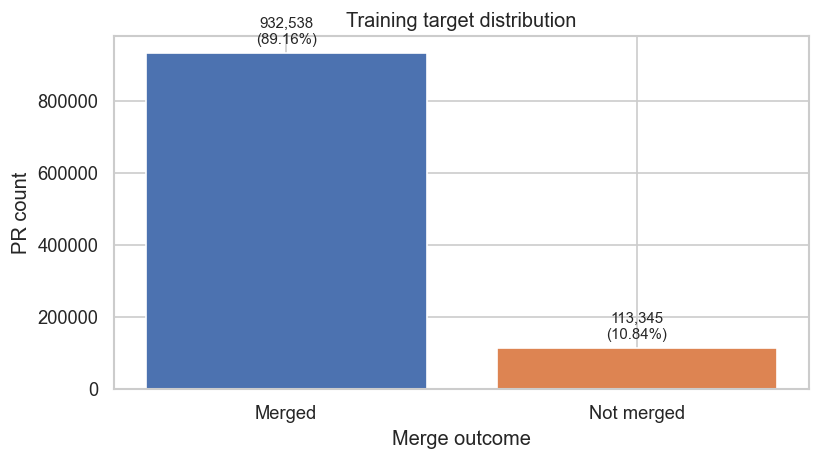

In [3]:
raw_headers = {
    "train": pd.read_csv(TRAIN_PATH, nrows=0),
    "test": pd.read_csv(TEST_PATH, nrows=0),
}
train_full = pd.read_csv(TRAIN_PATH, usecols=analysis_load_usecols, low_memory=False)
test_full = pd.read_csv(TEST_PATH, usecols=analysis_load_usecols, low_memory=False)
train_full["last_close_time"] = pd.to_datetime(train_full["last_close_time"], errors="coerce")
test_full["last_close_time"] = pd.to_datetime(test_full["last_close_time"], errors="coerce")

raw_fingerprint = raw_data_fingerprint(
    {
        "prfeatures_train_data": TRAIN_PATH,
        "prfeatures_test_data": TEST_PATH,
        "pr_comments_dataset_publish": DATA_DIR / "pr_comments_dataset_publish.csv",
        "survey_responses_raw": DATA_DIR / "survey_responses_raw.csv",
    }
)
raw_fingerprint.to_csv(FINAL_DIR / "raw_data_fingerprint.csv", index=False)

schema_summary = pd.DataFrame(
    [
        {"check": "train rows", "result": f"{len(train_full):,}"},
        {"check": "test rows", "result": f"{len(test_full):,}"},
        {"check": "train columns in raw file", "result": raw_headers["train"].shape[1]},
        {"check": "test columns in raw file", "result": raw_headers["test"].shape[1]},
        {"check": "same raw column names", "result": set(raw_headers["train"].columns) == set(raw_headers["test"].columns)},
        {"check": "same raw column order", "result": raw_headers["train"].columns.equals(raw_headers["test"].columns)},
        {"check": "loaded columns for analysis", "result": train_full.shape[1]},
        {"check": "target in train", "result": TARGET_COLUMN in train_full.columns},
        {"check": "target in test", "result": TARGET_COLUMN in test_full.columns},
        {"check": "explicit train nulls in loaded fields", "result": int(train_full.isna().sum().sum())},
        {"check": "explicit test nulls in loaded fields", "result": int(test_full.isna().sum().sum())},
        {"check": "duplicate loaded train rows", "result": int(train_full.duplicated().sum())},
        {"check": "duplicate loaded test rows", "result": int(test_full.duplicated().sum())},
    ]
)
target_dist = pd.concat(
    [target_distribution(train_full, "train"), target_distribution(test_full, "test")],
    ignore_index=True,
)
target_dist.to_csv(FINAL_DIR / "target_distribution_summary.csv", index=False)
quality_summary = data_quality_summary(train_full, test_full)
official_split_overlap = split_overlap_summary(train_full, test_full)
split_id_integrity = split_id_integrity_table(TRAIN_PATH, TEST_PATH)
quality_summary.to_csv(FINAL_DIR / "data_quality_summary.csv", index=False)
official_split_overlap.to_csv(FINAL_DIR / "split_overlap_summary.csv", index=False)
split_id_integrity.to_csv(FINAL_DIR / "split_id_integrity.csv", index=False)
display(schema_summary)
display(raw_fingerprint)
display(quality_summary)
display(official_split_overlap)
display(split_id_integrity)
display(target_dist)

train_target_plot = (
    target_dist[target_dist["split"] == "train"]
    .set_index("label")
    .loc[["Merged", "Not merged"]]
    .reset_index()
)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    train_target_plot["label"],
    train_target_plot["count"],
    color=["#4C72B0", "#DD8452"],
)
ax.set_title("Training target distribution")
ax.set_xlabel("Merge outcome")
ax.set_ylabel("PR count")
for patch, (_, row) in zip(bars, train_target_plot.iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()


## Leakage-aware feature review

The final headline model uses a stricter feature policy than the earlier checkpoints. It keeps fields that are defensible as PR-submission information, historical project/contributor context, or initial PR-diff context under a stated prediction-time contract. This is not called perfectly "safe": it is a headline leakage-safer policy whose assumptions are made explicit. PR evolution fields documented as close-time measures and target-adjacent success-rate fields are moved into sensitivity models instead of the headline claim.

Source notes used for this policy: the Zenodo PRFeatures record documents the 80/20 split and 72 PR-related variables; Zhang et al. describe pull-request decision factors and time-changing project context; the `new_pullreq_dataset` README distinguishes several unsuffixed close-time PR-size fields from `_open` submission-time variants. The source papers describe `prior_review_num` as integrator/reviewer experience, so it is no longer part of the headline model and appears only in a separate integrator-assumed sensitivity check.


In [4]:
feature_review = pd.DataFrame(
    [
        {"feature": TARGET_COLUMN, "status": "target", "reason": "Locked prediction target."},
        *[
            {"feature": feature, "status": "exclude_identifier", "reason": "Entity identifier; not a behavioral predictor."}
            for feature in exclude_ids
        ],
        *[
            {"feature": feature, "status": "exclude_post_outcome", "reason": "Depends on closure or post-decision information."}
            for feature in exclude_post_outcome
        ],
        *[
            {"feature": feature, "status": "hold_back_timing_sensitive", "reason": "Timing relative to merge decision is not yet defensible."}
            for feature in ambiguous_features
        ],
        *[
            {"feature": feature, "status": "used_headline_leakage_safer", "reason": availability_reason(feature)}
            for feature in headline_safe_features
        ],
        *[
            {"feature": feature, "status": "integrator_assumed_sensitivity", "reason": availability_reason(feature)}
            for feature in integrator_assumed_extension_features
        ],
        *[
            {"feature": feature, "status": "extended_timing_assumed", "reason": availability_reason(feature)}
            for feature in timing_assumed_extension_features
        ],
    ]
)
display(
    feature_review.groupby("status", as_index=False)
    .agg(feature_count=("feature", "count"))
    .sort_values("status")
)
display(feature_review)
feature_source_summary = pd.DataFrame(
    [{"source_id": source_id, "source_note": source_note} for source_id, source_note in feature_source_notes.items()]
)
feature_timing_evidence = feature_timing_evidence_table()
feature_timing_evidence.to_csv(FINAL_DIR / "feature_timing_evidence.csv", index=False)
prediction_contract_feature_map = prediction_contract_feature_map_table()
prediction_contract_feature_map.to_csv(FINAL_DIR / "prediction_contract_feature_map.csv", index=False)
review_process_feature_audit = review_process_feature_audit_table()
review_process_feature_audit.to_csv(FINAL_DIR / "review_process_feature_audit.csv", index=False)
comment_dataset_profile = comment_dataset_profile_table(DATA_DIR / "pr_comments_dataset_publish.csv")
comment_dataset_profile.to_csv(FINAL_DIR / "comment_dataset_profile.csv", index=False)
display(feature_source_summary)
display(feature_timing_evidence)
display(prediction_contract_feature_map.groupby(["contract", "contract_label"], as_index=False).agg(feature_count=("feature", "nunique")))
display(review_process_feature_audit)
display(comment_dataset_profile)
feature_timing_summary = pd.DataFrame(
    [
        {
            "group": "used",
            "feature_count": len(headline_safe_features),
            "fields": ", ".join(headline_safe_features),
            "professor_facing_assumption": "Used in the headline model only under the prediction-time contract: submission-time data, historical contributor/project context, project snapshots, or initial PR-diff context before final closure.",
        },
        {
            "group": "integrator-assumed sensitivity",
            "feature_count": len(integrator_assumed_extension_features),
            "fields": ", ".join(integrator_assumed_extension_features),
            "professor_facing_assumption": "Not used in the headline model because the field represents integrator/reviewer experience and may require knowing the eventual reviewer/integrator before the final decision.",
        },
        {
            "group": "held back",
            "feature_count": len(ambiguous_features) + len(timing_assumed_extension_features),
            "fields": ", ".join([*ambiguous_features, *timing_assumed_extension_features]),
            "professor_facing_assumption": "Not used in the headline model because comments, sentiment, CI outcomes, interaction fields, success rates, and close-time PR evolution fields can encode review or post-outcome information.",
        },
        {
            "group": "excluded",
            "feature_count": len(exclude_ids) + len(exclude_post_outcome),
            "fields": ", ".join([*exclude_ids, *exclude_post_outcome]),
            "professor_facing_assumption": "Identifiers and direct post-outcome fields are not behavioral predictors for the research question.",
        },
    ]
)
feature_timing_summary.to_csv(FINAL_DIR / "feature_timing_summary.csv", index=False)
display(feature_timing_summary)
feature_assumption_flags = pd.DataFrame(
    [
        {"feature_family": "project workload", "fields": "open_pr_num, open_issue_num", "remaining_assumption": "Snapshot is treated as available at or before PR submission."},
        {"feature_family": "project popularity/scale", "fields": "stars, fork_num, team_size, sloc", "remaining_assumption": "Snapshot/context fields may capture project-level differences as well as PR-level signal."},
        {"feature_family": "test density", "fields": "test_lines_per_kloc, test_cases_per_kloc, asserts_per_kloc", "remaining_assumption": "Interpreted as project-level test-density context, not evidence caused by the current PR."},
        {"feature_family": "initial PR diff", "fields": "churn_addition, churn_deletion, test_inclusion", "remaining_assumption": "Used as initial PR-scope information; close-time variants remain held back."},
        {"feature_family": "integrator-assumed sensitivity", "fields": ", ".join(integrator_assumed_extension_features), "remaining_assumption": "Held out of the headline model because integrator/reviewer experience may not be available until a reviewer or closer is known."},
        {"feature_family": "ultra-conservative subset", "fields": ", ".join(ultra_conservative_features), "remaining_assumption": "Diagnostic subset strips out richer project scale, workload, density, and churn context to test whether the conclusion survives stricter timing assumptions."},
    ]
)
feature_assumption_flags.to_csv(FINAL_DIR / "feature_assumption_flags.csv", index=False)
display(feature_assumption_flags)
display(Markdown(f'''
**Feature policy.** The headline model uses `{len(headline_safe_features)}` leakage-safer features under a stated prediction-time contract. The ultra-conservative sensitivity model uses `{len(ultra_conservative_features)}` least-controversial fields. Separate sensitivity checks add `{", ".join(integrator_assumed_extension_features)}` or `{", ".join(timing_assumed_extension_features)}` to estimate how much performance depends on stronger availability assumptions. These sensitivity results are robustness checks, not replacements for the headline claim.
'''))


,status,feature_count
0,exclude_identifier,4
1,exclude_post_outcome,3
2,extended_timing_assumed,6
3,hold_back_timing_sensitive,32
4,integrator_assumed_sensitivity,1
5,target,1
6,used_headline_leakage_safer,25


,feature,status,reason
0,merged_or_not,target,Locked prediction target.
1,id,exclude_identifier,Entity identifier; not a behavioral predictor.
2,project_id,exclude_identifier,Entity identifier; not a behavioral predictor.
3,creator_id,exclude_identifier,Entity identifier; not a behavioral predictor.
4,last_closer_id,exclude_identifier,Entity identifier; not a behavioral predictor.
...,...,...,...
67,requester_succ_rate,extended_timing_assumed,Target-adjacent requester merge-success rate; ...
68,num_commits,extended_timing_assumed,PR evolution field treated as timing-sensitive...
69,src_churn,extended_timing_assumed,PR evolution field treated as timing-sensitive...
70,files_changed,extended_timing_assumed,PR evolution field treated as timing-sensitive...


,source_id,source_note
0,zenodo_prfeatures,"Zenodo PRFeatures record: 80/20 split, 72 PR-r..."
1,msr2020_dataset,"Zhang, Rastogi, and Yu MSR 2020 dataset paper:..."
2,gitlink_field_readme,new_pullreq field README: field-level timing n...
3,tse2022_decisions,Zhang et al. TSE 2022 PR-decision paper: discu...


,feature,feature_family,documented_timing,evidence,risk_level,model_role,source
0,first_pr,contributor_history,pre-pr contributor history,Contributor first-PR flag before or at PR subm...,low,headline,MSR 2020 Table 1; GitLink README
1,core_member,contributor_history,pre-pr contributor/project role,Contributor core-member flag before review out...,low,headline,MSR 2020 Table 1; GitLink README
2,prior_interaction,contributor_history,historical interaction,Contributor-project interaction count from pri...,low,headline,MSR 2020 Table 1; GitLink README
3,followers,contributor_history,profile snapshot,Contributor profile context at PR submission.,low,headline,GitLink README
4,prev_pullreqs,contributor_history,pre-pr contributor history,Contributor previous PR count before the curre...,low,headline,MSR 2020 Table 1; GitLink README
5,account_creation_days,contributor_history,pre-pr contributor history,Account age at PR creation.,low,headline,MSR 2020 Table 1; GitLink README
6,contrib_perc_commit,contributor_history,historical contribution share,Contributor share of project commits before th...,medium,headline,GitLink README
7,sloc,project_context,submission-time project snapshot,Project source lines of code at PR submission.,low,headline,GitLink README
8,team_size,project_context,submission-time project snapshot,Core developer count at PR submission.,low,headline,GitLink README
9,language,project_context,project metadata,Main project language; encoded as nominal cate...,low,headline,MSR 2020 Table 1; Zenodo record


,contract,contract_label,feature_count
0,T0_creation,PR creation,22
1,T1_diff,Submitted diff,25
2,T2_review_process,Review process,58


,feature,stage,included_in_t2,excluded_from_early_reason,late_stage_rationale
0,num_comments,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
1,has_comments,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
2,num_participants,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
3,core_comment,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
4,contrib_comment,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
5,inte_comment,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
6,has_exchange,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
7,at_tag,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
8,num_code_comments,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...
9,num_code_comments_con,T2_review_process,True,"This field can encode review discussion, parti...",Used only to estimate the extra signal availab...


,metric,value,interpretation
0,raw_rows,588097,Comment-level rows available in the separate c...
1,unique_repositories,25460,Unique owner/repository keys in the comment da...
2,unique_repo_pr_keys,66281,Unique owner/repository/pull-number keys in th...
3,merged_comment_rows,463159,Comment rows labeled as merged by the comment ...
4,not_merged_comment_rows,124938,Comment rows labeled as not merged by the comm...
5,mean_word_count,20.2872,Average comment length in the comment dataset.
6,mean_negative_valence,0.0409,Average negative sentiment score in published ...
7,joined_to_prfeatures,false,The PRFeatures files expose numeric project/PR...


,group,feature_count,fields,professor_facing_assumption
0,used,25,"first_pr, core_member, prior_interaction, foll...",Used in the headline model only under the pred...
1,integrator-assumed sensitivity,1,prior_review_num,Not used in the headline model because the fie...
2,held back,38,"num_comments, has_comments, num_participants, ...",Not used in the headline model because comment...
3,excluded,7,"id, project_id, creator_id, last_closer_id, la...",Identifiers and direct post-outcome fields are...


,feature_family,fields,remaining_assumption
0,project workload,"open_pr_num, open_issue_num",Snapshot is treated as available at or before ...
1,project popularity/scale,"stars, fork_num, team_size, sloc",Snapshot/context fields may capture project-le...
2,test density,"test_lines_per_kloc, test_cases_per_kloc, asse...",Interpreted as project-level test-density cont...
3,initial PR diff,"churn_addition, churn_deletion, test_inclusion",Used as initial PR-scope information; close-ti...
4,integrator-assumed sensitivity,prior_review_num,Held out of the headline model because integra...
5,ultra-conservative subset,"first_pr, core_member, prior_interaction, foll...",Diagnostic subset strips out richer project sc...



**Feature policy.** The headline model uses `25` leakage-safer features under a stated prediction-time contract. The ultra-conservative sensitivity model uses `12` least-controversial fields. Separate sensitivity checks add `prior_review_num` or `pr_succ_rate, requester_succ_rate, num_commits, src_churn, files_changed, test_churn` to estimate how much performance depends on stronger availability assumptions. These sensitivity results are robustness checks, not replacements for the headline claim.


## Exploratory data analysis

EDA uses the headline leakage-safer variables plus clearly labeled timing-sensitive descriptors for context. These plots support interpretation and feature understanding; they are not used to make causal claims.


files_changed        churn_addition         churn_deletion  \
                       mean median           mean  median           mean   
merged_or_not                                                              
Not merged          15.4410 2.0000       618.5550 22.0000       344.6100   
Merged              10.9080 2.0000       412.5720 16.0000       277.5760   

                     description_length         num_commits         
              median               mean  median        mean median  
merged_or_not                                                       
Not merged    5.0000            59.9190 26.0000      4.6960 2.0000  
Merged        5.0000            45.9530 20.0000      3.9840 2.0000

,feature,value,count,merge_rate_pct
0,first_pr,0,1012149,89.4500
1,first_pr,1,33734,80.6800
2,core_member,0,206724,82.5600
3,core_member,1,839159,90.7900
4,test_inclusion,0,825940,89.4300
5,test_inclusion,1,219943,88.1700
6,friday_effect,0,872033,89.1100
7,friday_effect,1,173850,89.4200
8,ci_exists,0,318880,87.0500
9,ci_exists,1,727003,90.0900


,feature,mean,std,50%,90%,99%,max,skew,outlier_flag
0,first_pr,0.0323,0.1767,0.0000,0.0000,1.0000,1.0000,5.2950,no_extreme_tail
1,core_member,0.8023,0.3982,1.0000,1.0000,1.0000,1.0000,-1.5184,no_extreme_tail
2,prior_interaction,203.3687,340.7160,98.0000,513.0000,"1,405.0000","20,105.0000",13.5720,extreme_tail
3,followers,150.3622,"1,325.3189",18.0000,206.0000,"1,810.0000","53,972.0000",27.2437,extreme_tail
4,prev_pullreqs,110.6658,194.9010,38.0000,298.0000,952.0000,"3,744.0000",4.0939,extreme_tail
5,account_creation_days,"1,702.3634",891.4253,"1,683.0000","2,906.0000","3,684.0000","4,125.0000",0.1505,extreme_tail
6,contrib_perc_commit,0.1930,0.2393,0.0893,0.5736,0.9407,1.0000,1.5226,extreme_tail
7,sloc,"84,551.2183","223,192.6861","16,973.0000","207,807.0000","1,054,372.4600","7,199,716.0000",7.9729,extreme_tail
8,team_size,10.2739,13.5103,6.0000,21.0000,83.0000,267.0000,4.4337,extreme_tail
9,open_issue_num,169.8397,397.7580,38.0000,485.0000,"1,652.0000","6,893.0000",7.7533,extreme_tail


,language,pr_count,merge_rate,not_merged_rate
0,0,72007,90.7010,9.2990
1,1,220063,86.0320,13.9680
2,2,317852,89.8940,10.1060
3,3,294433,90.0310,9.9690
4,4,115109,89.8930,10.1070
5,5,26419,89.3900,10.6100


,size_bin,project_count,median_pr_count,median_not_merged_rate
0,large,2121,54.0000,5.7690
1,medium,2055,21.0000,5.2630
2,small,2255,6.0000,0.0000
3,very_large,2131,214.0000,6.7060


,split,entity,top_n,unique_entities,rows_covered,row_pct
0,train,project_id,10,8562,48819,4.6680
1,train,project_id,100,8562,243467,23.2790
2,train,project_id,500,8562,544208,52.0330
3,train,creator_id,10,44012,13956,1.3340
4,train,creator_id,100,44012,82524,7.8900
5,train,creator_id,500,44012,226446,21.6510
6,test,project_id,10,5837,13914,5.3480
7,test,project_id,100,5837,68304,26.2510
8,test,project_id,500,5837,149390,57.4150
9,test,creator_id,10,17669,8951,3.4400


,finding,evidence,interpretation
0,Class imbalance drives metric choice,"Merged PRs: 932,538 (89.16%); not merged: 113,...",Accuracy-only evaluation would reward the majo...
1,First-time contributors have visibly higher no...,First PR not-merged rate 19.32% vs 10.55% for ...,Contributor history is a meaningful associatio...
2,Core-member status separates outcomes,Non-core not-merged rate 17.44% vs 9.21% for c...,Role/context features help explain why contrib...
3,Merged PRs come from contributors with deeper ...,Median previous PRs: 22 for not-merged vs 41 f...,The model's reliance on contributor-history si...
4,Non-merged PRs are associated with larger or b...,Median open PRs: 22 for not-merged vs 12 for m...,"Project context is predictive, but it also rai..."
5,CI presence is associated with a lower non-mer...,CI-present not-merged rate 9.91% vs 12.95% whe...,CI is treated as context only; CI outcome fiel...
6,Rows are concentrated in recurring projects an...,Top 500 projects contain 52.03% of train rows;...,This supports project/creator overlap checks a...
7,"Language-code groups differ, but labels are en...",Highest not-merged language code 1: 13.97%; lo...,Language is useful as nominal project metadata...


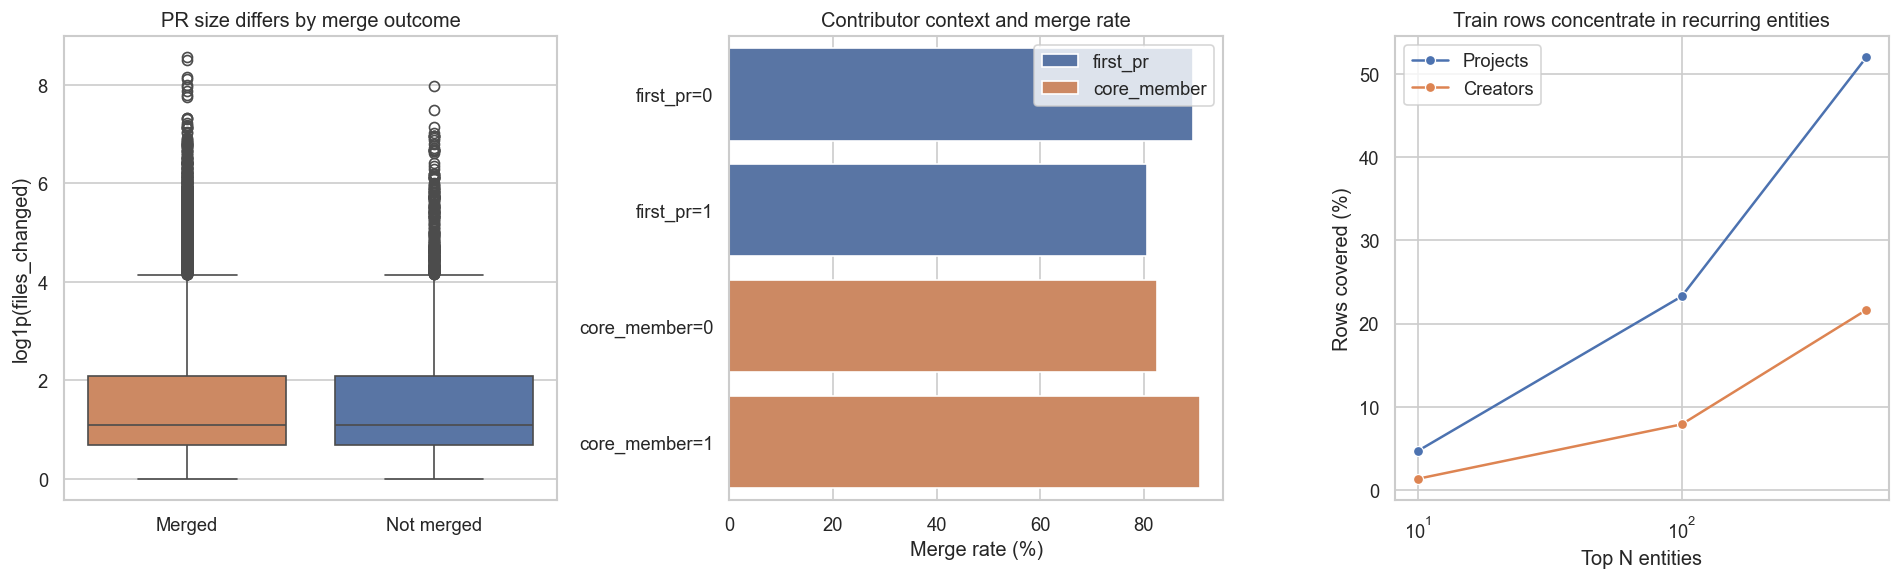

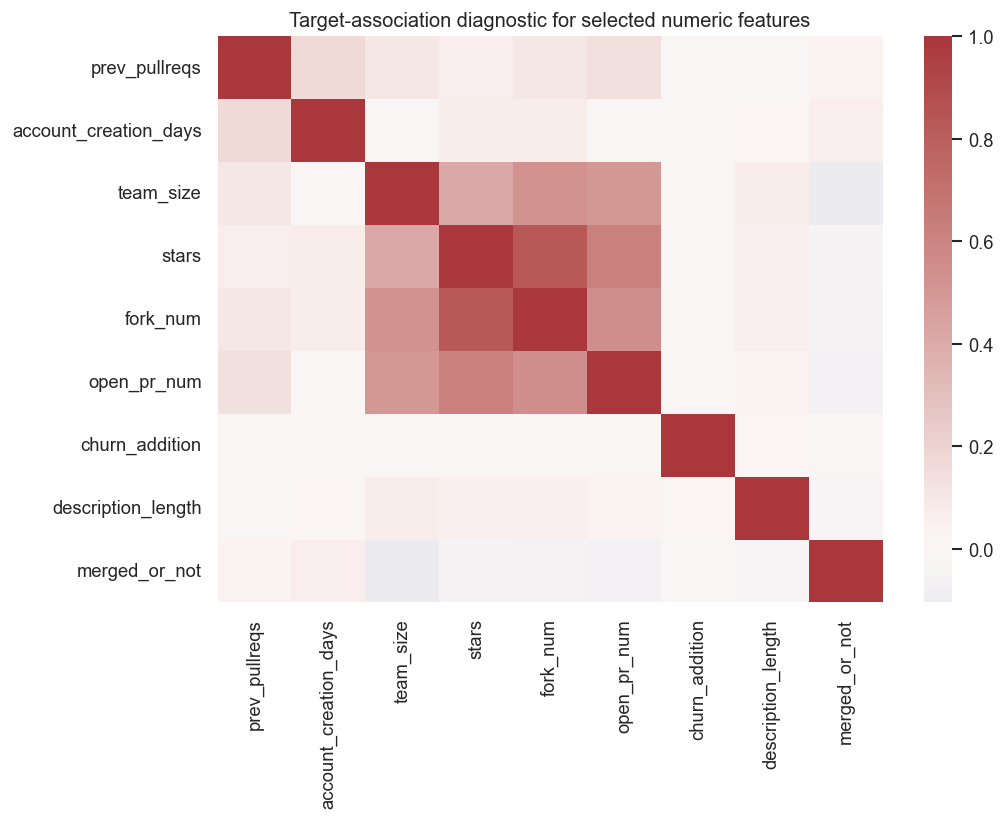


**EDA interpretation.** The class imbalance is large enough that accuracy alone would reward models that mostly predict merges. First-time PRs have a not-merged rate of `19.32%`, compared with `10.55%` for non-first PRs. Non-core contributors show a not-merged rate of `17.44%`, compared with `9.21%` for core members. Project concentration is also material: the top 500 projects contain `52.03%` of training rows. These patterns explain why model evidence must be paired with project/creator stress tests. None of these patterns should be read causally because the dataset is observational.


In [5]:
train_model = train_full[analysis_load_usecols].copy()
test_model = test_full[analysis_load_usecols].copy()

size_features = ["files_changed", "churn_addition", "churn_deletion", "description_length", "num_commits"]
size_summary = (
    train_model.groupby(TARGET_COLUMN)[size_features]
    .agg(["mean", "median"])
    .rename(index=TARGET_LABELS)
    .round(3)
)
display(size_summary)

binary_rate_features = ["first_pr", "core_member", "test_inclusion", "friday_effect", "ci_exists"]
binary_rates = pd.concat(
    [
        train_model.groupby(feature)[TARGET_COLUMN]
        .agg(merge_rate="mean", count="size")
        .reset_index()
        .rename(columns={feature: "value"})
        .assign(feature=feature, merge_rate_pct=lambda df: (df["merge_rate"] * 100).round(2))
        for feature in binary_rate_features
    ],
    ignore_index=True,
)[["feature", "value", "count", "merge_rate_pct"]]
display(binary_rates)

numeric_summary = numeric_distribution_summary(train_model, headline_safe_features)
class_feature_summary = class_conditioned_feature_summary(train_model, headline_safe_features)
language_summary, project_size_summary = language_project_context_summary(train_model)
project_creator_concentration_summary = pd.concat(
    [
        project_creator_concentration(train_model, "train"),
        project_creator_concentration(test_model, "test"),
    ],
    ignore_index=True,
)
eda_findings = eda_key_findings(train_model, target_dist, project_creator_concentration_summary)
numeric_summary.to_csv(FINAL_DIR / "numeric_distribution_summary.csv", index=False)
class_feature_summary.to_csv(FINAL_DIR / "class_conditioned_feature_summary.csv", index=False)
language_summary.to_csv(FINAL_DIR / "language_merge_summary.csv", index=False)
project_size_summary.to_csv(FINAL_DIR / "project_size_merge_summary.csv", index=False)
project_creator_concentration_summary.to_csv(FINAL_DIR / "project_creator_concentration.csv", index=False)
eda_findings.to_csv(FINAL_DIR / "eda_key_findings.csv", index=False)
display(numeric_summary.head(12))
display(language_summary)
display(project_size_summary)
display(project_creator_concentration_summary)
display(eda_findings)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sample_for_plot = stratified_sample(train_model[[TARGET_COLUMN, *size_features]], 60_000)
sample_for_plot["merge_label"] = sample_for_plot[TARGET_COLUMN].map(TARGET_LABELS)
sns.boxplot(
    data=sample_for_plot.assign(log_files_changed=np.log1p(sample_for_plot["files_changed"])),
    x="merge_label",
    y="log_files_changed",
    hue="merge_label",
    palette=["#DD8452", "#4C72B0"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("PR size differs by merge outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("log1p(files_changed)")

core_plot = binary_rates[binary_rates["feature"].isin(["first_pr", "core_member"])].copy()
core_plot["group"] = core_plot["feature"] + "=" + core_plot["value"].astype(str)
sns.barplot(data=core_plot, x="merge_rate_pct", y="group", hue="feature", dodge=False, ax=axes[1])
axes[1].set_title("Contributor context and merge rate")
axes[1].set_xlabel("Merge rate (%)")
axes[1].set_ylabel("")
axes[1].legend(title="")

train_project_concentration = project_creator_concentration_summary[
    (project_creator_concentration_summary["split"] == "train")
    & (project_creator_concentration_summary["entity"].isin(["project_id", "creator_id"]))
].copy()
train_project_concentration["entity_label"] = train_project_concentration["entity"].map(
    {"project_id": "Projects", "creator_id": "Creators"}
)
sns.lineplot(
    data=train_project_concentration,
    x="top_n",
    y="row_pct",
    hue="entity_label",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Train rows concentrate in recurring entities")
axes[2].set_xlabel("Top N entities")
axes[2].set_ylabel("Rows covered (%)")
axes[2].set_xscale("log")
axes[2].legend(title="")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_safe_feature_patterns.png", bbox_inches="tight")
plt.show()

corr_features = ["prev_pullreqs", "account_creation_days", "team_size", "stars", "fork_num", "open_pr_num", "churn_addition", "description_length", TARGET_COLUMN]
corr = train_model[corr_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
ax.set_title("Target-association diagnostic for selected numeric features")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "safe_feature_correlation.png", bbox_inches="tight")
plt.show()

display(Markdown(f'''
**EDA interpretation.** The class imbalance is large enough that accuracy alone would reward models that mostly predict merges. First-time PRs have a not-merged rate of `{(1 - train_model.loc[train_model["first_pr"] == 1, TARGET_COLUMN].mean()) * 100:.2f}%`, compared with `{(1 - train_model.loc[train_model["first_pr"] == 0, TARGET_COLUMN].mean()) * 100:.2f}%` for non-first PRs. Non-core contributors show a not-merged rate of `{(1 - train_model.loc[train_model["core_member"] == 0, TARGET_COLUMN].mean()) * 100:.2f}%`, compared with `{(1 - train_model.loc[train_model["core_member"] == 1, TARGET_COLUMN].mean()) * 100:.2f}%` for core members. Project concentration is also material: the top 500 projects contain `{project_creator_concentration_summary[(project_creator_concentration_summary["split"] == "train") & (project_creator_concentration_summary["entity"] == "project_id") & (project_creator_concentration_summary["top_n"] == 500)]["row_pct"].iloc[0]:.2f}%` of training rows. These patterns explain why model evidence must be paired with project/creator stress tests. None of these patterns should be read causally because the dataset is observational.
'''))


## Algorithm comprehension map

The assignment explicitly grades comprehension of the selected algorithms. The table below records each model's role, the reason it was selected, and the limitation we should mention during discussion.


In [6]:
algorithm_comprehension = pd.DataFrame(
    [
        {"algorithm": "Dummy majority", "role": "Baseline", "why_used": "Shows why raw accuracy is misleading under class imbalance.", "main_limitation": "Detects no not-merged PRs."},
        {"algorithm": "Logistic regression balanced", "role": "Linear supervised model", "why_used": "Interpretable weighted baseline for directional linear signal.", "main_limitation": "Cannot model non-linear feature interactions well."},
        {"algorithm": "Decision tree balanced", "role": "Interpretable non-linear baseline", "why_used": "Captures threshold rules and gives a simple tree-based comparison.", "main_limitation": "Can be unstable; depth is constrained to reduce overfitting."},
        {"algorithm": "Random forest balanced", "role": "Selected supervised model", "why_used": "Averages many class-balanced trees and performed best by validation not-merged F1.", "main_limitation": "Impurity importance is not causal and can favor high-cardinality/continuous features."},
        {"algorithm": "Histogram gradient boosting weighted", "role": "Boosted supervised comparator", "why_used": "Sequentially improves weak learners with class-balanced sample weights.", "main_limitation": "Higher recall/AP in some diagnostics but lower declared primary F1 than the selected model."},
        {"algorithm": "K-means", "role": "Unsupervised profiling", "why_used": "Groups PRs by feature similarity without using the target.", "main_limitation": "Assumes compact clusters and is sensitive to scaling."},
        {"algorithm": "PCA", "role": "Visualization only", "why_used": "Projects high-dimensional cluster features into two dimensions for inspection.", "main_limitation": "Two components explain only part of the transformed variance."},
    ]
)
algorithm_comprehension.to_csv(FINAL_DIR / "algorithm_comprehension.csv", index=False)
display(algorithm_comprehension)


,algorithm,role,why_used,main_limitation
0,Dummy majority,Baseline,Shows why raw accuracy is misleading under cla...,Detects no not-merged PRs.
1,Logistic regression balanced,Linear supervised model,Interpretable weighted baseline for directiona...,Cannot model non-linear feature interactions w...
2,Decision tree balanced,Interpretable non-linear baseline,Captures threshold rules and gives a simple tr...,Can be unstable; depth is constrained to reduc...
3,Random forest balanced,Selected supervised model,Averages many class-balanced trees and perform...,Impurity importance is not causal and can favo...
4,Histogram gradient boosting weighted,Boosted supervised comparator,Sequentially improves weak learners with class...,Higher recall/AP in some diagnostics but lower...
5,K-means,Unsupervised profiling,Groups PRs by feature similarity without using...,Assumes compact clusters and is sensitive to s...
6,PCA,Visualization only,Projects high-dimensional cluster features int...,Two components explain only part of the transf...


## Supervised modeling and validation comparison

Model selection uses the full training source file with an internal stratified validation split. Numeric features are median-imputed and scaled, binary features are most-frequent imputed, and `language` is one-hot encoded as a nominal category. The selected model is then retrained on all `1,045,883` training rows before touching the provided test split.

Repeated cross-validation remains a sampled diagnostic because running every model over six full-dataset folds would be computationally expensive and is not needed for the final holdout estimate.


,feature_policy,feature_count,source_rows,training_rows,validation_rows,training_scope,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,actual_not_merged_predicted_not_merged,actual_not_merged_predicted_merged,actual_merged_predicted_not_merged,actual_merged_predicted_merged,actual_not_merged,actual_merged,predicted_not_merged,predicted_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,headline_leakage_safer_features,25,1045883,784412,261471,full_source_internal_validation,Random forest balanced,default_model_threshold,None,0.7796,0.7016,0.2691,0.6020,0.3719,0.9431,0.8012,0.8664,0.7777,0.3878,17059,11277,46340,186795,28336,233135,63399,198072,17059,11277,46340,186795
1,headline_leakage_safer_features,25,1045883,784412,261471,full_source_internal_validation,Hist gradient boosting weighted,default_model_threshold,None,0.7255,0.6899,0.2284,0.6444,0.3372,0.9445,0.7354,0.8269,0.7589,0.3584,18260,10076,61699,171436,28336,233135,79959,181512,18260,10076,61699,171436
2,headline_leakage_safer_features,25,1045883,784412,261471,full_source_internal_validation,Decision tree balanced,default_model_threshold,None,0.7069,0.6512,0.2025,0.5801,0.3002,0.9340,0.7223,0.8146,0.7153,0.3082,16437,11899,64749,168386,28336,233135,81186,180285,16437,11899,64749,168386
3,headline_leakage_safer_features,25,1045883,784412,261471,full_source_internal_validation,Logistic regression balanced,default_model_threshold,None,0.6217,0.6100,0.1617,0.5951,0.2543,0.9270,0.6249,0.7466,0.6555,0.2053,16863,11473,87439,145696,28336,233135,104302,157169,16863,11473,87439,145696
4,headline_leakage_safer_features,25,1045883,784412,261471,full_source_internal_validation,Dummy majority,default_model_threshold,None,0.8916,0.5000,0.0000,0.0000,0.0000,0.8916,1.0000,0.9427,0.5000,0.1084,0,28336,0,233135,28336,233135,0,261471,0,28336,0,233135


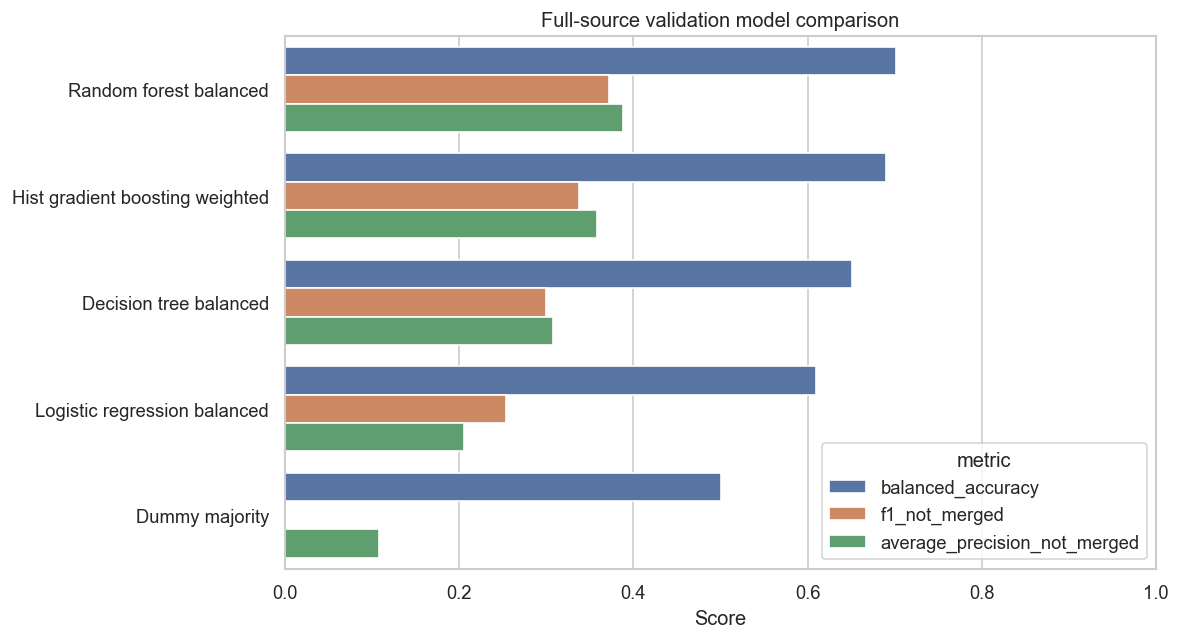

,model,cv_folds,model_sample_size,feature_policy,feature_count,source_rows,training_rows,validation_rows,training_scope,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_not_merged_mean,precision_not_merged_std,recall_not_merged_mean,recall_not_merged_std,f1_not_merged_mean,f1_not_merged_std,roc_auc_merged_mean,roc_auc_merged_std,average_precision_not_merged_mean,average_precision_not_merged_std
0,Random forest balanced,6,120000,headline_leakage_safer_features,25,1045883,80000,40000,120000_row_repeated_cv_diagnostic,0.7766,0.0014,0.6682,0.0054,0.2498,0.0038,0.5300,0.0110,0.3395,0.0057,0.7394,0.0048,0.3145,0.0073
1,Hist gradient boosting weighted,6,120000,headline_leakage_safer_features,25,1045883,80000,40000,120000_row_repeated_cv_diagnostic,0.7353,0.0071,0.6742,0.0034,0.2264,0.0045,0.5962,0.0093,0.3281,0.0045,0.7387,0.0040,0.3259,0.0111
2,Decision tree balanced,6,120000,headline_leakage_safer_features,25,1045883,80000,40000,120000_row_repeated_cv_diagnostic,0.6696,0.0179,0.6312,0.0043,0.1814,0.0056,0.5821,0.0213,0.2765,0.0051,0.6793,0.0048,0.2564,0.0053
3,Logistic regression balanced,6,120000,headline_leakage_safer_features,25,1045883,80000,40000,120000_row_repeated_cv_diagnostic,0.6217,0.0019,0.6139,0.0045,0.1633,0.0019,0.6040,0.0106,0.2571,0.0033,0.6584,0.0057,0.2061,0.0027
4,Dummy majority,6,120000,headline_leakage_safer_features,25,1045883,80000,40000,120000_row_repeated_cv_diagnostic,0.8916,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.1084,0.0000


,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,actual_not_merged_predicted_not_merged,actual_not_merged_predicted_merged,actual_merged_predicted_not_merged,actual_merged_predicted_merged,actual_not_merged,actual_merged,predicted_not_merged,predicted_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,Random forest balanced,default_model_threshold,NaN,0.7796,0.7016,0.2691,0.6020,0.3719,0.9431,0.8012,0.8664,0.7777,0.3878,17059,11277,46340,186795,28336,233135,63399,198072,17059,11277,46340,186795
1,Random forest balanced,validation_tuned_not_merged_f1,0.5778,0.8558,0.6786,0.3663,0.4524,0.4048,0.9315,0.9049,0.9180,0.7777,0.3878,12820,15516,22179,210956,28336,233135,34999,226472,12820,15516,22179,210956


,fold,model,model_sample_size,training_rows,validation_rows,best_threshold,default_precision_not_merged,default_recall_not_merged,default_f1_not_merged,tuned_precision_not_merged,tuned_recall_not_merged,tuned_f1_not_merged
0,1,Random forest balanced,120000,80000,40000,0.5421,0.2539,0.5278,0.3429,0.2965,0.4408,0.3545
1,2,Random forest balanced,120000,80000,40000,0.5450,0.2495,0.5373,0.3408,0.2922,0.4374,0.3503
2,3,Random forest balanced,120000,80000,40000,0.5520,0.2470,0.5343,0.3378,0.2967,0.4249,0.3494
3,4,Random forest balanced,120000,80000,40000,0.5636,0.2498,0.5296,0.3395,0.3126,0.3993,0.3507
4,5,Random forest balanced,120000,80000,40000,0.5490,0.2517,0.5315,0.3416,0.2995,0.4265,0.3519
5,6,Random forest balanced,120000,80000,40000,0.5472,0.2478,0.5336,0.3384,0.2938,0.4364,0.3512


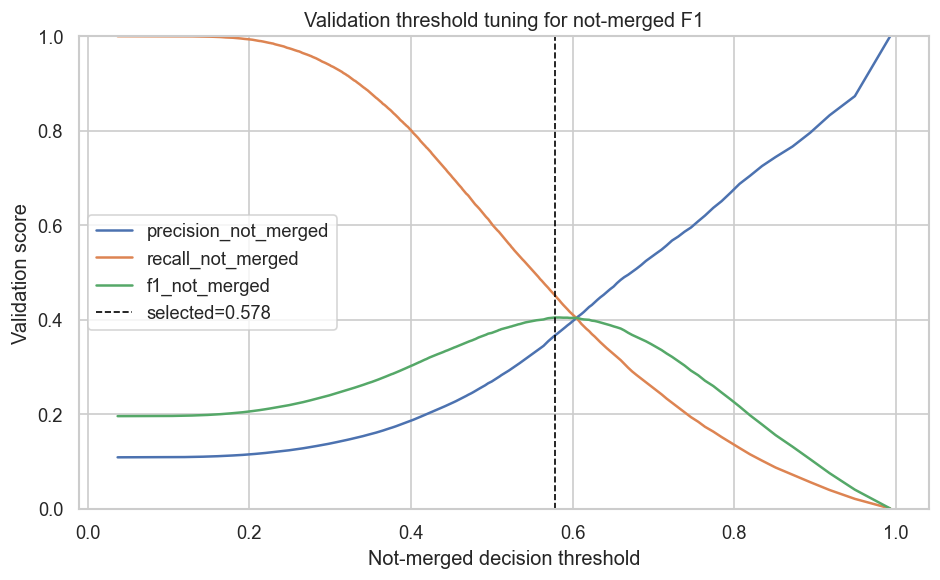


**Model-selection interpretation.** The selected model is **Random forest balanced**, chosen by validation not-merged F1 with balanced accuracy and not-merged average precision as secondary checks. The comparison above uses the full source training file for internal validation. The repeated 3x2 validation table is a sampled stability check, not the final training basis.

**Threshold rule.** The tuned not-merged threshold is `0.578` and was selected only from validation predictions. It is carried forward once to the test split, alongside default-threshold metrics, so the tuned result is not hidden inside model selection.


In [7]:
PRIMARY_MODEL_SAMPLE_SIZE = None
CV_SAMPLE_SIZE = 120_000
comparison, fitted_models, validation_data = fit_and_compare(
    train_model,
    PRIMARY_MODEL_SAMPLE_SIZE,
    feature_list=headline_safe_features,
    feature_policy="headline_leakage_safer_features",
)
comparison.to_csv(FINAL_DIR / "model_comparison.csv", index=False)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5.5))
metric_plot = comparison.melt(
    id_vars="model",
    value_vars=["balanced_accuracy", "f1_not_merged", "average_precision_not_merged"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=metric_plot, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Full-source validation model comparison")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

selected_model_name = comparison.iloc[0]["model"]
X_train, X_valid, y_train, y_valid = validation_data
selected_validation_model = fitted_models[selected_model_name]

cv_summary, cv_fold_scores = repeated_validation_summary(
    train_model,
    CV_SAMPLE_SIZE,
    feature_list=headline_safe_features,
    feature_policy="headline_leakage_safer_features",
)
cv_summary.to_csv(FINAL_DIR / "cross_validation_summary.csv", index=False)
cv_fold_scores.to_csv(FINAL_DIR / "cross_validation_fold_scores.csv", index=False)
display(cv_summary)

threshold_table = threshold_tuning_table(selected_validation_model, X_valid, y_valid)
threshold_table_export = add_metric_metadata(
    threshold_table,
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(X_train),
    validation_rows=len(X_valid),
    training_scope="full_source_internal_validation",
)
threshold_tuning_top, threshold_tuning_curve_sample = compact_threshold_outputs(threshold_table)
threshold_tuning_top = add_metric_metadata(
    threshold_tuning_top,
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(X_train),
    validation_rows=len(X_valid),
    training_scope="full_source_internal_validation",
)
threshold_tuning_curve_sample = add_metric_metadata(
    threshold_tuning_curve_sample,
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(X_train),
    validation_rows=len(X_valid),
    training_scope="full_source_internal_validation",
)
threshold_tuning_top.to_csv(FINAL_DIR / "threshold_tuning_top.csv", index=False)
threshold_tuning_curve_sample.to_csv(FINAL_DIR / "threshold_tuning_curve_sample.csv", index=False)
threshold_tuning_top.to_csv(FINAL_DIR / "threshold_tuning.csv", index=False)
best_threshold = float(threshold_table.iloc[0]["threshold"])
tuned_validation_metrics = pd.DataFrame([
    score_pipeline(selected_model_name, selected_validation_model, X_valid, y_valid),
    score_pipeline(
        selected_model_name,
        selected_validation_model,
        X_valid,
        y_valid,
        threshold=best_threshold,
        threshold_label="validation_tuned_not_merged_f1",
    ),
])
display(tuned_validation_metrics)

threshold_stability = threshold_stability_summary(
    train_model,
    selected_model_name,
    headline_safe_features,
    sample_size=120_000,
)
threshold_stability.to_csv(FINAL_DIR / "threshold_stability.csv", index=False)
display(threshold_stability)

threshold_plot = threshold_tuning_curve_sample.sort_values("threshold")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=threshold_plot.melt(
        id_vars="threshold",
        value_vars=["precision_not_merged", "recall_not_merged", "f1_not_merged"],
        var_name="metric",
        value_name="score",
    ),
    x="threshold",
    y="score",
    hue="metric",
    ax=ax,
)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1, label=f"selected={best_threshold:.3f}")
ax.set_title("Validation threshold tuning for not-merged F1")
ax.set_xlabel("Not-merged decision threshold")
ax.set_ylabel("Validation score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tuning.png", bbox_inches="tight")
plt.show()

display(Markdown(f'''
**Model-selection interpretation.** The selected model is **{selected_model_name}**, chosen by validation not-merged F1 with balanced accuracy and not-merged average precision as secondary checks. The comparison above uses the full source training file for internal validation. The repeated 3x2 validation table is a sampled stability check, not the final training basis.

**Threshold rule.** The tuned not-merged threshold is `{best_threshold:.3f}` and was selected only from validation predictions. It is carried forward once to the test split, alongside default-threshold metrics, so the tuned result is not hidden inside model selection.
'''))


## Final evaluation on the untouched test split


,feature_policy,feature_count,source_rows,training_rows,validation_rows,training_scope,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,actual_not_merged_predicted_not_merged,actual_not_merged_predicted_merged,actual_merged_predicted_not_merged,actual_merged_predicted_merged,actual_not_merged,actual_merged,predicted_not_merged,predicted_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,Random forest balanced,default_model_threshold,NaN,0.7562,0.6504,0.2254,0.5154,0.3136,0.9304,0.7853,0.8517,0.7108,0.3013,14494,13628,49818,182255,28122,232073,64312,195883,14494,13628,49818,182255
1,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,Random forest balanced,validation_tuned_not_merged_f1,0.5778,0.8375,0.6294,0.2955,0.3639,0.3262,0.9207,0.8949,0.9076,0.7108,0.3013,10234,17888,24393,207680,28122,232073,34627,225568,10234,17888,24393,207680


,feature_policy,training_rows,threshold_label,actual_not_merged_predicted_not_merged,actual_not_merged_predicted_merged,actual_merged_predicted_not_merged,actual_merged_predicted_merged
0,headline_leakage_safer_features,1045883,default_model_threshold,14494,13628,49818,182255
1,headline_leakage_safer_features,1045883,validation_tuned_not_merged_f1,10234,17888,24393,207680


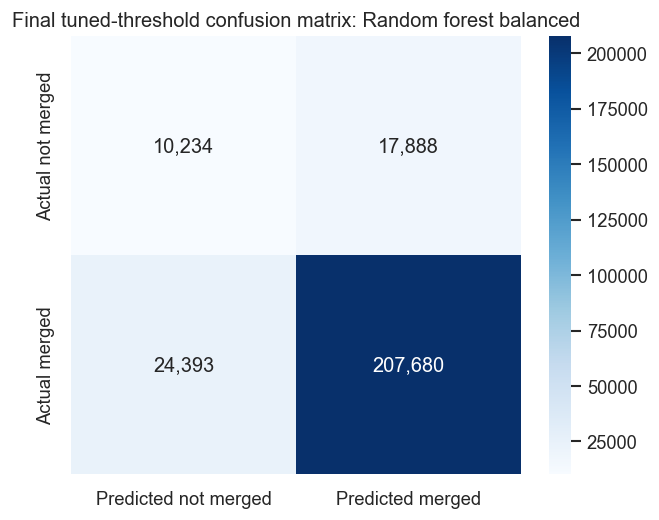

,risk_decile,risk_label,row_count,actual_not_merged,min_predicted_not_merged_score,mean_predicted_not_merged_score,max_predicted_not_merged_score,actual_not_merged_rate,actual_not_merged_rate_pct,baseline_not_merged_rate,baseline_not_merged_rate_pct,lift_vs_baseline
0,1,lowest predicted not-merged risk,26020,707,0.0899,0.2085,0.2446,0.0272,2.7171,0.1081,10.8080,0.2514
1,2,middle risk band,26019,1297,0.2446,0.2694,0.2916,0.0498,4.9848,0.1081,10.8080,0.4612
2,3,middle risk band,26020,1594,0.2916,0.3108,0.3294,0.0613,6.1261,0.1081,10.8080,0.5668
3,4,middle risk band,26019,1667,0.3294,0.3466,0.3635,0.0641,6.4069,0.1081,10.8080,0.5928
4,5,middle risk band,26020,2005,0.3635,0.3798,0.3963,0.0771,7.7056,0.1081,10.8080,0.7130
5,6,middle risk band,26019,2246,0.3963,0.4139,0.4324,0.0863,8.6322,0.1081,10.8080,0.7987
6,7,middle risk band,26019,2550,0.4324,0.4524,0.4737,0.0980,9.8005,0.1081,10.8080,0.9068
7,8,middle risk band,26020,3181,0.4737,0.4992,0.5280,0.1223,12.2252,0.1081,10.8080,1.1311
8,9,middle risk band,26019,4216,0.5280,0.5655,0.6103,0.1620,16.2035,0.1081,10.8080,1.4992
9,10,highest predicted not-merged risk,26020,8659,0.6103,0.7124,0.9917,0.3328,33.2782,0.1081,10.8080,3.0790


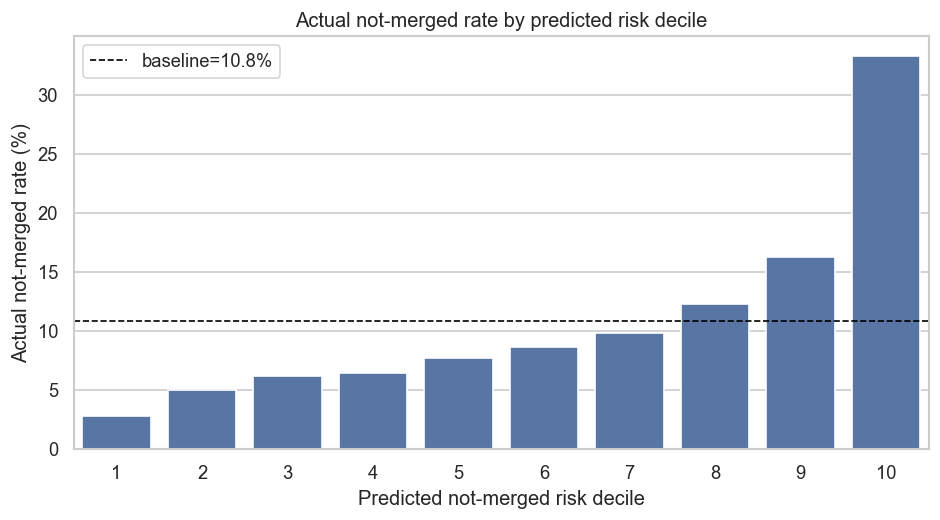

,calibration_bin,row_count,min_predicted_not_merged_score,mean_predicted_not_merged_score,max_predicted_not_merged_score,observed_not_merged_rate,calibration_error,absolute_calibration_error,brier_score_not_merged,observed_not_merged_rate_pct,mean_predicted_not_merged_score_pct
0,1,26020,0.0899,0.2085,0.2446,0.0272,-0.1813,0.1813,0.1873,2.7171,20.8488
1,2,26019,0.2446,0.2694,0.2916,0.0498,-0.2196,0.2196,0.1873,4.9848,26.9438
2,3,26020,0.2916,0.3108,0.3294,0.0613,-0.2495,0.2495,0.1873,6.1261,31.0802
3,4,26019,0.3294,0.3466,0.3635,0.0641,-0.2825,0.2825,0.1873,6.4069,34.6586
4,5,26020,0.3635,0.3798,0.3963,0.0771,-0.3028,0.3028,0.1873,7.7056,37.9846
5,6,26019,0.3963,0.4139,0.4324,0.0863,-0.3276,0.3276,0.1873,8.6322,41.3908
6,7,26019,0.4324,0.4524,0.4737,0.0980,-0.3544,0.3544,0.1873,9.8005,45.2445
7,8,26020,0.4737,0.4992,0.5280,0.1223,-0.3770,0.3770,0.1873,12.2252,49.9239
8,9,26019,0.5280,0.5655,0.6103,0.1620,-0.4034,0.4034,0.1873,16.2035,56.5462
9,10,26020,0.6103,0.7124,0.9917,0.3328,-0.3796,0.3796,0.1873,33.2782,71.2422


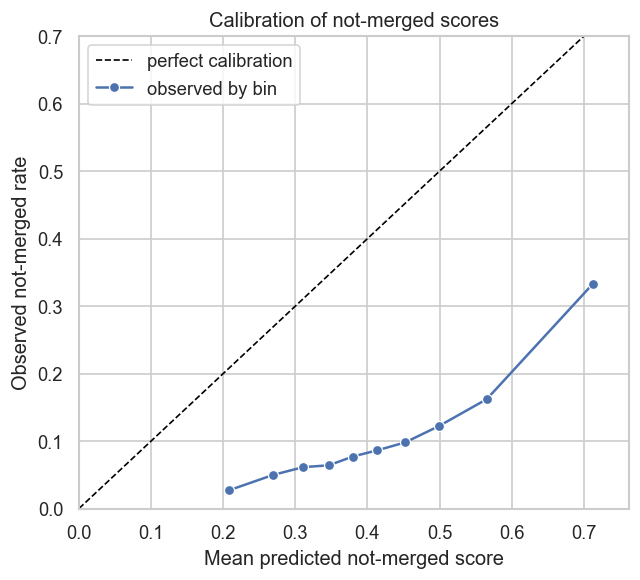

,outcome_group,row_count,actual_not_merged_rate,predicted_not_merged_rate,mean_predicted_not_merged_score,first_pr_rate,non_core_rate,ci_exists_rate,test_inclusion_rate,median_prev_pullreqs,median_contrib_perc_commit,median_open_pr_num,median_stars,median_churn_addition,median_description_length,share_of_test_pct,display_order
0,correct_not_merged,10234,1.0000,1.0000,0.7283,0.1195,0.5752,0.4990,0.2534,7.0000,0.0021,39.0000,761.5000,27.0000,33.0000,3.9332,1
1,missed_not_merged,17888,1.0000,0.0000,0.4179,0.0238,0.1955,0.7119,0.1928,33.0000,0.0819,13.0000,125.0000,19.0000,21.0000,6.8748,2
2,false_not_merged,24393,0.0000,1.0000,0.6638,0.1113,0.6089,0.5901,0.2320,6.0000,0.0021,35.0000,608.0000,21.0000,27.0000,9.3749,3
3,correct_merged,207680,0.0000,0.0000,0.3712,0.0201,0.1374,0.7095,0.1967,45.0000,0.1214,10.0000,92.0000,15.0000,19.0000,79.8171,4


,finding,evidence,interpretation
0,Predicted risk ranks concentrate not-merged ou...,Top risk decile actual not-merged rate 33.28% ...,The model is more defensible as a risk-ranking...
1,Missed not-merged PRs receive lower risk score...,Mean not-merged score 0.418 for missed not-mer...,The main failure mode is ambiguous not-merged ...
2,False not-merged predictions are concentrated ...,False not-merged median open PRs 35 and stars ...,Project context is useful but can make accepte...
3,Scores are imperfectly calibrated,Weighted mean absolute calibration error 0.308...,Predicted scores should be treated as ranking ...


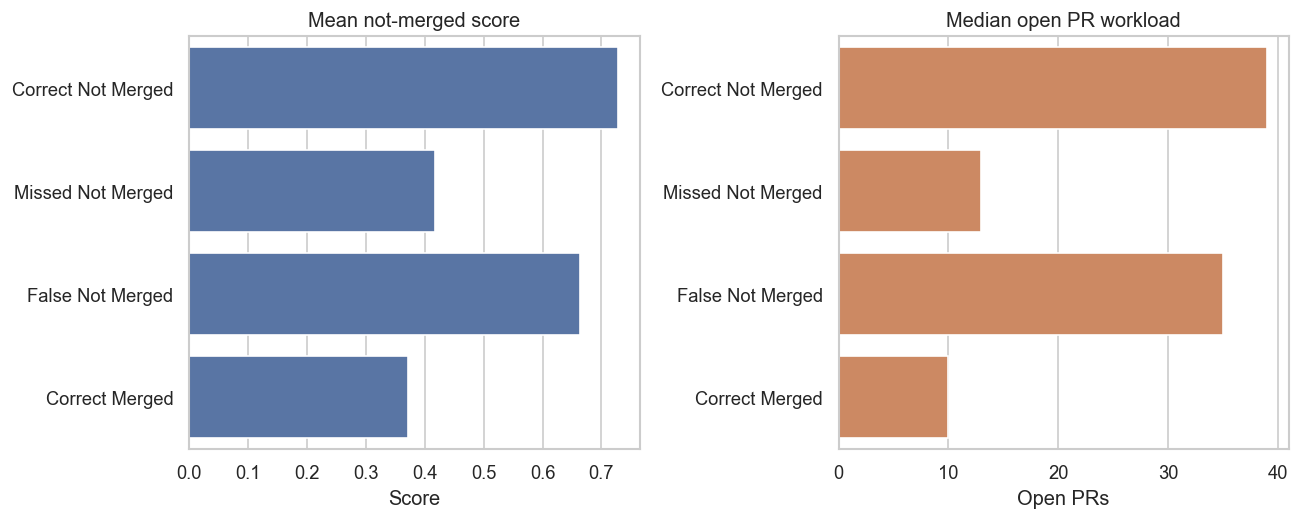

,feature_policy,feature,importance
0,headline_leakage_safer_features,contrib_perc_commit,0.1439
1,headline_leakage_safer_features,open_pr_num,0.0646
2,headline_leakage_safer_features,fork_num,0.0636
3,headline_leakage_safer_features,prior_interaction,0.0618
4,headline_leakage_safer_features,prev_pullreqs,0.0602
5,headline_leakage_safer_features,sloc,0.0578
6,headline_leakage_safer_features,account_creation_days,0.0499
7,headline_leakage_safer_features,test_lines_per_kloc,0.0498
8,headline_leakage_safer_features,stars,0.0496
9,headline_leakage_safer_features,open_issue_num,0.0489


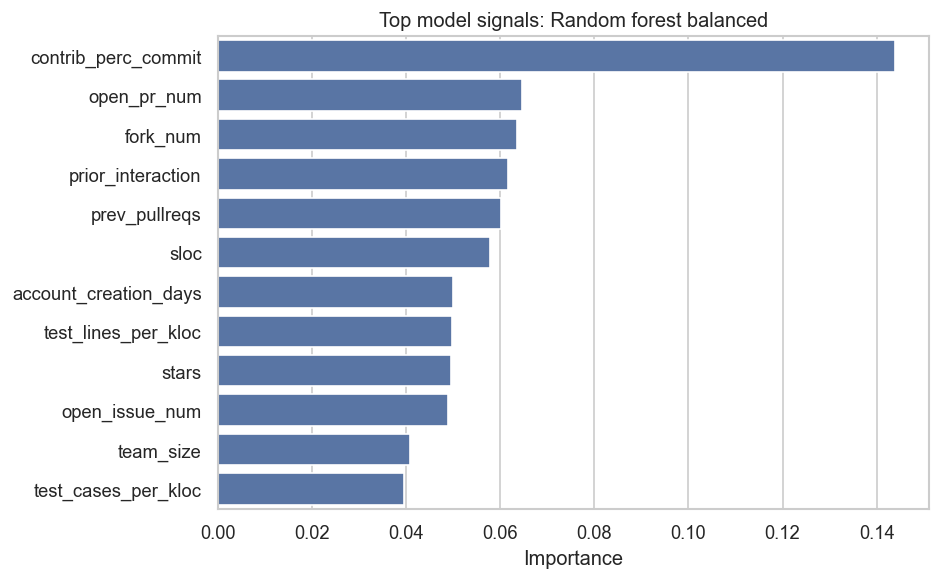

,feature_policy,feature_count,source_rows,training_rows,validation_rows,training_scope,threshold_label,metric,estimate,bootstrap_mean,ci_lower_95,ci_upper_95,bootstrap_resamples
0,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,precision_not_merged,0.2254,0.2254,0.2221,0.2287,500
1,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,recall_not_merged,0.5154,0.5152,0.5093,0.5208,500
2,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,f1_not_merged,0.3136,0.3136,0.3096,0.3172,500
3,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,balanced_accuracy,0.6504,0.6503,0.6470,0.6530,500
4,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,roc_auc_merged,0.7108,0.7107,0.7074,0.7140,500
5,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,precision_not_merged,0.2955,0.2955,0.2905,0.3004,500
6,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,recall_not_merged,0.3639,0.3639,0.3584,0.3695,500
7,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,f1_not_merged,0.3262,0.3261,0.3212,0.3310,500
8,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,balanced_accuracy,0.6294,0.6294,0.6264,0.6322,500
9,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,roc_auc_merged,0.7108,0.7107,0.7074,0.7140,500


,feature_policy,feature_count,source_rows,training_rows,validation_rows,training_scope,threshold_label,metric,estimate,cluster_bootstrap_mean,ci_lower_95,ci_upper_95,bootstrap_resamples,cluster_unit
0,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,precision_not_merged,0.2254,0.2254,0.2068,0.2473,300,project_id
1,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,recall_not_merged,0.5154,0.5141,0.4768,0.5585,300,project_id
2,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,f1_not_merged,0.3136,0.3133,0.2905,0.3409,300,project_id
3,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,default_model_threshold,balanced_accuracy,0.6504,0.6500,0.6326,0.6686,300,project_id
4,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,precision_not_merged,0.2955,0.2956,0.2645,0.3275,300,project_id
5,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,recall_not_merged,0.3639,0.3626,0.3225,0.4076,300,project_id
6,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,f1_not_merged,0.3262,0.3255,0.2957,0.3600,300,project_id
7,headline_leakage_safer_features,25,1045883,1045883,261471,full_training_split,validation_tuned_not_merged_f1,balanced_accuracy,0.6294,0.6289,0.6111,0.6502,300,project_id


,feature_set,evaluation_split,model,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,ultra_conservative_features,validation,Random forest balanced,0.6562,0.2127,0.5678,0.3095,0.2757
1,headline_leakage_safer_features,validation,Random forest balanced,0.7016,0.2691,0.6020,0.3719,0.3878
2,integrator_assumed_features,validation,Random forest balanced,0.7252,0.3284,0.5995,0.4243,0.4487
3,extended_timing_assumed_features,validation,Random forest balanced,0.7025,0.2730,0.5987,0.3750,0.3934
4,ultra_conservative_features,test,Random forest balanced,0.6190,0.1876,0.5009,0.2729,0.2217
5,headline_leakage_safer_features,test,Random forest balanced,0.6504,0.2254,0.5154,0.3136,0.3013
6,integrator_assumed_features,test,Random forest balanced,0.6833,0.2905,0.5208,0.3730,0.3823
7,extended_timing_assumed_features,test,Random forest balanced,0.6510,0.2268,0.5145,0.3148,0.3031


,evaluation_split,threshold_label,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged,f1_gap_vs_best_validation
0,internal_validation,default_model_threshold,0.7796,0.7016,0.2691,0.6020,0.3719,0.3878,-0.0329
1,internal_validation,validation_tuned_not_merged_f1,0.8558,0.6786,0.3663,0.4524,0.4048,0.3878,0.0000
2,official_test,default_model_threshold,0.7562,0.6504,0.2254,0.5154,0.3136,0.3013,-0.0912
3,official_test,validation_tuned_not_merged_f1,0.8375,0.6294,0.2955,0.3639,0.3262,0.3013,-0.0786


,stress_test,training_rows,validation_rows,validation_not_merged_rate,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,roc_auc_merged,average_precision_not_merged
0,random_stratified_sample,165000,55000,10.8382,0.6838,0.2578,0.5655,0.3542,0.7561,0.3408
1,temporal_last_25pct_sample,165000,55000,8.0000,0.6102,0.1964,0.3420,0.2495,0.6795,0.1963
2,project_group_holdout_sample,162856,57144,10.4508,0.5928,0.1851,0.3814,0.2493,0.6514,0.1932
3,creator_group_holdout_sample,164403,55597,10.7218,0.6415,0.2270,0.4788,0.3080,0.7003,0.2770


,stress_test,model,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
3,random_stratified_sample,Random forest balanced,0.6777,0.2583,0.5460,0.3507,0.3342
8,temporal_last_25pct_sample,Random forest balanced,0.6118,0.2028,0.3398,0.2540,0.1998
14,project_group_holdout_sample,Hist gradient boosting weighted,0.6435,0.2026,0.5570,0.2971,0.2286
18,creator_group_holdout_sample,Random forest balanced,0.6559,0.2444,0.4952,0.3273,0.3231


,feature,importance_mean,importance_std,sample_size,scoring
0,open_pr_num,0.0252,0.0019,35000,validation_not_merged_f1_drop
1,fork_num,0.0201,0.0014,35000,validation_not_merged_f1_drop
2,open_issue_num,0.0165,0.0020,35000,validation_not_merged_f1_drop
3,account_creation_days,0.0163,0.0009,35000,validation_not_merged_f1_drop
4,followers,0.0135,0.0006,35000,validation_not_merged_f1_drop
5,project_age,0.0124,0.0018,35000,validation_not_merged_f1_drop
6,sloc,0.0123,0.0009,35000,validation_not_merged_f1_drop
7,test_lines_per_kloc,0.0123,0.0014,35000,validation_not_merged_f1_drop
8,ci_exists,0.0121,0.0008,35000,validation_not_merged_f1_drop
9,contrib_perc_commit,0.0112,0.0041,35000,validation_not_merged_f1_drop


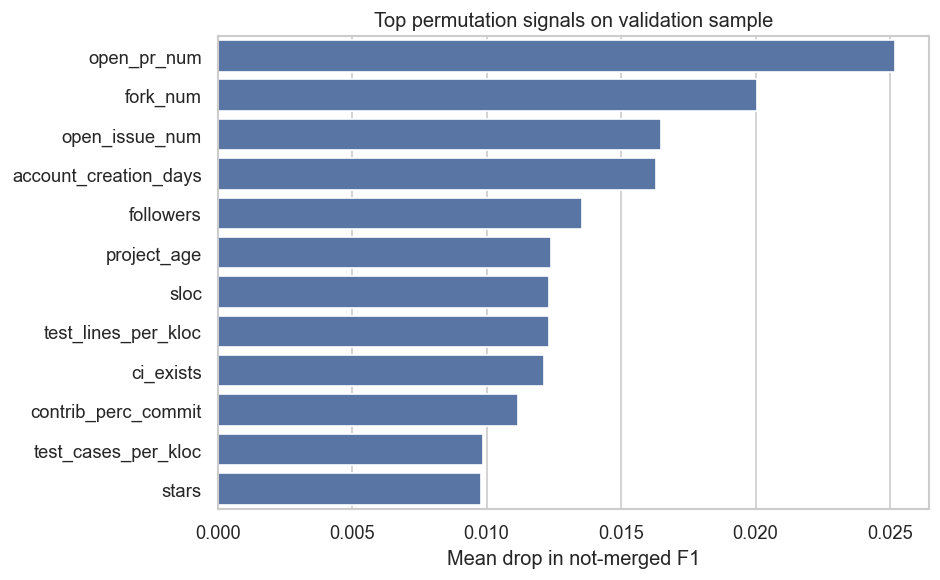

,ablation,removed_family,remaining_feature_count,balanced_accuracy,f1_not_merged,average_precision_not_merged,delta_f1_not_merged_vs_full,delta_average_precision_vs_full
0,none_full_headline,none,25,0.6821,0.3542,0.3424,0.0000,0.0000
1,without_contributor_history,contributor_history,18,0.6551,0.3351,0.3229,-0.0191,-0.0195
2,without_project_context,project_context,17,0.6605,0.3241,0.3020,-0.0300,-0.0404
3,without_pr_scope,pr_scope,22,0.6836,0.3536,0.3495,-0.0006,0.0071
4,without_testing_ci_context,testing_ci_context,20,0.6748,0.3421,0.3285,-0.0120,-0.0139
5,without_language_calendar,language_calendar,23,0.6815,0.3537,0.3395,-0.0004,-0.0029


,requested_sample_size,actual_sample_size,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,100000,100000,0.6717,0.2532,0.5353,0.3438,0.3170
1,260000,260000,0.6828,0.2600,0.5589,0.3549,0.3414
2,500000,500000,0.6921,0.2668,0.5767,0.3648,0.3576


,evaluation_split,training_scope,training_rows,validation_rows,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,sample_validation,stratified_sample_100000_diagnostic,75000,25000,0.7786,0.6717,0.2532,0.5353,0.3438,0.3170
1,sample_validation,stratified_sample_260000_diagnostic,195000,65000,0.7798,0.6828,0.2600,0.5589,0.3549,0.3414
2,sample_validation,stratified_sample_500000_diagnostic,375000,125000,0.7824,0.6921,0.2668,0.5767,0.3648,0.3576
3,full_source_validation,full_source_internal_validation,784412,261471,0.7796,0.7016,0.2691,0.6020,0.3719,0.3878
4,full_test,full_training_split,1045883,261471,0.7562,0.6504,0.2254,0.5154,0.3136,0.3013



**Final-test interpretation.** The final headline model is retrained on the full training split before test evaluation. The default-threshold row is the direct model output. The tuned-threshold row applies a validation-selected rule that is more conservative about predicting not-merged PRs: it predicts fewer not-merged cases, raises precision and F1, and lowers recall/balanced accuracy. The ultra-conservative, extended-feature, and sample-size tables are diagnostics, not replacements for the headline leakage-safer result.


In [8]:
final_train_df = train_model[[TARGET_COLUMN, *headline_safe_features]].copy()
X_final_train = final_train_df[headline_safe_features]
y_final_train = final_train_df[TARGET_COLUMN]
X_test = test_model[headline_safe_features]
y_test = test_model[TARGET_COLUMN]

final_model = fit_pipeline(
    selected_model_name,
    build_models(y_final_train, headline_safe_features)[selected_model_name],
    X_final_train,
    y_final_train,
)
final_metrics = add_metric_metadata(pd.DataFrame([
    score_pipeline(selected_model_name, final_model, X_test, y_test),
    score_pipeline(
        selected_model_name,
        final_model,
        X_test,
        y_test,
        threshold=best_threshold,
        threshold_label="validation_tuned_not_merged_f1",
    ),
]),
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(final_train_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)
final_metrics.to_csv(FINAL_DIR / "final_test_metrics.csv", index=False)
display(final_metrics)

default_pred_test = final_model.predict(X_test)
tuned_pred_test = predict_with_not_merged_threshold(final_model, X_test, best_threshold)
final_score_merged = score_merged_probability(final_model, X_test)
final_score_not_merged = 1 - final_score_merged
confusion_rows = []
for label, predictions in {
    "default_model_threshold": default_pred_test,
    "validation_tuned_not_merged_f1": tuned_pred_test,
}.items():
    cm = confusion_matrix(y_test, predictions, labels=[0, 1])
    confusion_rows.append({
        "feature_policy": "headline_leakage_safer_features",
        "training_rows": len(final_train_df),
        "threshold_label": label,
        "actual_not_merged_predicted_not_merged": int(cm[0, 0]),
        "actual_not_merged_predicted_merged": int(cm[0, 1]),
        "actual_merged_predicted_not_merged": int(cm[1, 0]),
        "actual_merged_predicted_merged": int(cm[1, 1]),
    })
final_confusion = pd.DataFrame(confusion_rows)
final_confusion.to_csv(FINAL_DIR / "final_confusion_matrix.csv", index=False)
display(final_confusion)

tuned_cm = confusion_matrix(y_test, tuned_pred_test, labels=[0, 1])
cm_df = pd.DataFrame(
    tuned_cm,
    index=["Actual not merged", "Actual merged"],
    columns=["Predicted not merged", "Predicted merged"],
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title(f"Final tuned-threshold confusion matrix: {selected_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_confusion_matrix.png", bbox_inches="tight")
plt.show()

risk_bands = test_prediction_risk_bands(y_test, final_score_not_merged, n_bins=10)
risk_bands.to_csv(FINAL_DIR / "test_prediction_risk_bands.csv", index=False)
display(risk_bands)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=risk_bands,
    x="risk_decile",
    y="actual_not_merged_rate_pct",
    color="#4C72B0",
    ax=ax,
)
baseline_pct = risk_bands["baseline_not_merged_rate_pct"].iloc[0]
ax.axhline(baseline_pct, color="black", linestyle="--", linewidth=1, label=f"baseline={baseline_pct:.1f}%")
ax.set_title("Actual not-merged rate by predicted risk decile")
ax.set_xlabel("Predicted not-merged risk decile")
ax.set_ylabel("Actual not-merged rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "risk_band_lift.png", bbox_inches="tight")
plt.show()

calibration_summary = calibration_summary_table(y_test, final_score_not_merged, n_bins=10)
calibration_summary.to_csv(FINAL_DIR / "calibration_summary.csv", index=False)
display(calibration_summary)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="perfect calibration")
sns.lineplot(
    data=calibration_summary,
    x="mean_predicted_not_merged_score",
    y="observed_not_merged_rate",
    marker="o",
    ax=ax,
    color="#4C72B0",
    label="observed by bin",
)
ax.set_title("Calibration of not-merged scores")
ax.set_xlabel("Mean predicted not-merged score")
ax.set_ylabel("Observed not-merged rate")
ax.set_xlim(0, max(0.7, calibration_summary["mean_predicted_not_merged_score"].max() + 0.05))
ax.set_ylim(0, max(0.7, calibration_summary["observed_not_merged_rate"].max() + 0.05))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_curve.png", bbox_inches="tight")
plt.show()

error_profile = error_profile_summary_table(
    X_test,
    y_test,
    tuned_pred_test,
    final_score_not_merged,
)
error_profile.to_csv(FINAL_DIR / "error_profile_summary.csv", index=False)
display(error_profile)

error_analysis_findings = error_analysis_findings_table(
    risk_bands,
    calibration_summary,
    error_profile,
)
error_analysis_findings.to_csv(FINAL_DIR / "error_analysis_key_findings.csv", index=False)
display(error_analysis_findings)

error_plot = error_profile.copy()
error_plot["outcome_label"] = error_plot["outcome_group"].str.replace("_", " ").str.title()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(
    data=error_plot,
    x="mean_predicted_not_merged_score",
    y="outcome_label",
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title("Mean not-merged score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("")
sns.barplot(
    data=error_plot,
    x="median_open_pr_num",
    y="outcome_label",
    color="#DD8452",
    ax=axes[1],
)
axes[1].set_title("Median open PR workload")
axes[1].set_xlabel("Open PRs")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "error_profile.png", bbox_inches="tight")
plt.show()

importances = feature_importance_table(final_model)
if not importances.empty:
    importances.insert(0, "feature_policy", "headline_leakage_safer_features")
importances.to_csv(FINAL_DIR / "feature_importance.csv", index=False)
display(importances.head(15))
if not importances.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=importances.head(12), x="importance", y="feature", ax=ax)
    ax.set_title(f"Top model signals: {selected_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()

ci_default = bootstrap_metric_intervals(
    y_test,
    default_pred_test,
    final_score_merged,
    threshold_label="default_model_threshold",
    point_estimates=final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0].to_dict(),
    n_resamples=500,
)
ci_tuned = bootstrap_metric_intervals(
    y_test,
    tuned_pred_test,
    final_score_merged,
    threshold_label="validation_tuned_not_merged_f1",
    point_estimates=final_metrics[final_metrics["threshold_label"] == "validation_tuned_not_merged_f1"].iloc[0].to_dict(),
    n_resamples=500,
)
final_metric_confidence_intervals = pd.concat([ci_default, ci_tuned], ignore_index=True)
final_metric_confidence_intervals = add_metric_metadata(
    final_metric_confidence_intervals,
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(final_train_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)
final_metric_confidence_intervals.to_csv(FINAL_DIR / "final_metric_confidence_intervals.csv", index=False)
display(final_metric_confidence_intervals)

project_cluster_ci = pd.concat(
    [
        project_cluster_bootstrap_intervals(
            y_test,
            default_pred_test,
            test_model["project_id"],
            threshold_label="default_model_threshold",
            point_estimates=final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0].to_dict(),
            n_resamples=300,
        ),
        project_cluster_bootstrap_intervals(
            y_test,
            tuned_pred_test,
            test_model["project_id"],
            threshold_label="validation_tuned_not_merged_f1",
            point_estimates=final_metrics[final_metrics["threshold_label"] == "validation_tuned_not_merged_f1"].iloc[0].to_dict(),
            n_resamples=300,
        ),
    ],
    ignore_index=True,
)
project_cluster_ci = add_metric_metadata(
    project_cluster_ci,
    feature_policy="headline_leakage_safer_features",
    feature_count=len(headline_safe_features),
    source_rows=len(train_model),
    training_rows=len(final_train_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)
project_cluster_ci.to_csv(FINAL_DIR / "project_cluster_metric_confidence_intervals.csv", index=False)
display(project_cluster_ci)

X_integrator = train_model[integrator_assumed_features]
y_integrator = train_model[TARGET_COLUMN]
X_integrator_train, X_integrator_valid, y_integrator_train, y_integrator_valid = train_test_split(
    X_integrator,
    y_integrator,
    test_size=0.25,
    stratify=y_integrator,
    random_state=RANDOM_STATE,
)
integrator_validation_model = fit_pipeline(
    selected_model_name,
    build_models(y_integrator_train, integrator_assumed_features)[selected_model_name],
    X_integrator_train,
    y_integrator_train,
)
integrator_validation_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, integrator_validation_model, X_integrator_valid, y_integrator_valid),
    feature_policy="integrator_assumed_features",
    feature_count=len(integrator_assumed_features),
    source_rows=len(train_model),
    training_rows=len(X_integrator_train),
    validation_rows=len(X_integrator_valid),
    training_scope="full_source_internal_validation",
)

integrator_final_df = train_model[[TARGET_COLUMN, *integrator_assumed_features]].copy()
X_integrator_final_train = integrator_final_df[integrator_assumed_features]
y_integrator_final_train = integrator_final_df[TARGET_COLUMN]
X_integrator_test = test_model[integrator_assumed_features]
integrator_final_model = fit_pipeline(
    selected_model_name,
    build_models(y_integrator_final_train, integrator_assumed_features)[selected_model_name],
    X_integrator_final_train,
    y_integrator_final_train,
)
integrator_test_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, integrator_final_model, X_integrator_test, y_test),
    feature_policy="integrator_assumed_features",
    feature_count=len(integrator_assumed_features),
    source_rows=len(train_model),
    training_rows=len(integrator_final_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)

X_extended = train_model[extended_timing_assumed_features]
y_extended = train_model[TARGET_COLUMN]
X_extended_train, X_extended_valid, y_extended_train, y_extended_valid = train_test_split(
    X_extended,
    y_extended,
    test_size=0.25,
    stratify=y_extended,
    random_state=RANDOM_STATE,
)
extended_validation_model = fit_pipeline(
    selected_model_name,
    build_models(y_extended_train, extended_timing_assumed_features)[selected_model_name],
    X_extended_train,
    y_extended_train,
)
extended_validation_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, extended_validation_model, X_extended_valid, y_extended_valid),
    feature_policy="extended_timing_assumed_features",
    feature_count=len(extended_timing_assumed_features),
    source_rows=len(train_model),
    training_rows=len(X_extended_train),
    validation_rows=len(X_extended_valid),
    training_scope="full_source_internal_validation",
)

extended_final_df = train_model[[TARGET_COLUMN, *extended_timing_assumed_features]].copy()
X_extended_final_train = extended_final_df[extended_timing_assumed_features]
y_extended_final_train = extended_final_df[TARGET_COLUMN]
X_extended_test = test_model[extended_timing_assumed_features]
extended_final_model = fit_pipeline(
    selected_model_name,
    build_models(y_extended_final_train, extended_timing_assumed_features)[selected_model_name],
    X_extended_final_train,
    y_extended_final_train,
)
extended_test_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, extended_final_model, X_extended_test, y_test),
    feature_policy="extended_timing_assumed_features",
    feature_count=len(extended_timing_assumed_features),
    source_rows=len(train_model),
    training_rows=len(extended_final_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)
X_ultra = train_model[ultra_conservative_features]
y_ultra = train_model[TARGET_COLUMN]
X_ultra_train, X_ultra_valid, y_ultra_train, y_ultra_valid = train_test_split(
    X_ultra,
    y_ultra,
    test_size=0.25,
    stratify=y_ultra,
    random_state=RANDOM_STATE,
)
ultra_validation_model = fit_pipeline(
    selected_model_name,
    build_models(y_ultra_train, ultra_conservative_features)[selected_model_name],
    X_ultra_train,
    y_ultra_train,
)
ultra_validation_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, ultra_validation_model, X_ultra_valid, y_ultra_valid),
    feature_policy="ultra_conservative_features",
    feature_count=len(ultra_conservative_features),
    source_rows=len(train_model),
    training_rows=len(X_ultra_train),
    validation_rows=len(X_ultra_valid),
    training_scope="full_source_internal_validation",
)

ultra_final_df = train_model[[TARGET_COLUMN, *ultra_conservative_features]].copy()
X_ultra_final_train = ultra_final_df[ultra_conservative_features]
y_ultra_final_train = ultra_final_df[TARGET_COLUMN]
X_ultra_test = test_model[ultra_conservative_features]
ultra_final_model = fit_pipeline(
    selected_model_name,
    build_models(y_ultra_final_train, ultra_conservative_features)[selected_model_name],
    X_ultra_final_train,
    y_ultra_final_train,
)
ultra_test_metrics = add_metric_metadata(
    score_pipeline(selected_model_name, ultra_final_model, X_ultra_test, y_test),
    feature_policy="ultra_conservative_features",
    feature_count=len(ultra_conservative_features),
    source_rows=len(train_model),
    training_rows=len(ultra_final_df),
    validation_rows=len(X_valid),
    training_scope="full_training_split",
)
primary_validation_metrics = comparison[comparison["model"] == selected_model_name].iloc[0].to_dict()
primary_test_metrics = final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0].to_dict()
leakage_sensitivity = pd.DataFrame([
    {
        "feature_set": "ultra_conservative_features",
        "evaluation_split": "validation",
        "timing_assumed_features": "none; stricter subset of headline policy",
        **ultra_validation_metrics,
    },
    {
        "feature_set": "headline_leakage_safer_features",
        "evaluation_split": "validation",
    "timing_assumed_features": "",
    **primary_validation_metrics,
},
{
    "feature_set": "integrator_assumed_features",
    "evaluation_split": "validation",
    "timing_assumed_features": ", ".join(integrator_assumed_extension_features),
    **integrator_validation_metrics,
},
{
    "feature_set": "extended_timing_assumed_features",
    "evaluation_split": "validation",
        "timing_assumed_features": ", ".join(timing_assumed_extension_features),
        **extended_validation_metrics,
    },
    {
        "feature_set": "ultra_conservative_features",
        "evaluation_split": "test",
        "timing_assumed_features": "none; stricter subset of headline policy",
        **ultra_test_metrics,
    },
    {
        "feature_set": "headline_leakage_safer_features",
        "evaluation_split": "test",
    "timing_assumed_features": "",
    **primary_test_metrics,
},
{
    "feature_set": "integrator_assumed_features",
    "evaluation_split": "test",
    "timing_assumed_features": ", ".join(integrator_assumed_extension_features),
    **integrator_test_metrics,
},
{
    "feature_set": "extended_timing_assumed_features",
    "evaluation_split": "test",
        "timing_assumed_features": ", ".join(timing_assumed_extension_features),
        **extended_test_metrics,
    },
])
leakage_sensitivity.to_csv(FINAL_DIR / "leakage_sensitivity.csv", index=False)
display(leakage_sensitivity[[
    "feature_set", "evaluation_split", "model", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged",
]])

validation_test_gap = pd.concat(
    [
        add_metric_metadata(
            tuned_validation_metrics.assign(evaluation_split="internal_validation"),
            feature_policy="headline_leakage_safer_features",
            feature_count=len(headline_safe_features),
            source_rows=len(train_model),
            training_rows=len(X_train),
            validation_rows=len(X_valid),
            training_scope="full_source_internal_validation",
        ),
        final_metrics.assign(evaluation_split="official_test"),
    ],
    ignore_index=True,
    sort=False,
)
validation_test_gap["f1_gap_vs_best_validation"] = (
    validation_test_gap["f1_not_merged"]
    - validation_test_gap.loc[
        (validation_test_gap["evaluation_split"] == "internal_validation")
        & (validation_test_gap["threshold_label"] == "validation_tuned_not_merged_f1"),
        "f1_not_merged",
    ].iloc[0]
)
validation_test_gap.to_csv(FINAL_DIR / "validation_test_gap.csv", index=False)
display(validation_test_gap[[
    "evaluation_split", "threshold_label", "accuracy", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged", "f1_gap_vs_best_validation",
]])

stress_tests = generalization_stress_tests(
    train_model,
    selected_model_name,
    headline_safe_features,
    sample_size=220_000,
)
stress_tests.insert(0, "training_scope", "220000_row_generalization_stress_diagnostic")
stress_tests.insert(0, "source_rows", len(train_model))
stress_tests.insert(0, "feature_count", len(headline_safe_features))
stress_tests.insert(0, "feature_policy", "headline_leakage_safer_features")
stress_tests.to_csv(FINAL_DIR / "generalization_stress_tests.csv", index=False)
display(stress_tests[[
    "stress_test", "training_rows", "validation_rows", "validation_not_merged_rate",
    "balanced_accuracy", "precision_not_merged", "recall_not_merged",
    "f1_not_merged", "roc_auc_merged", "average_precision_not_merged",
]])

stress_model_comparison = stress_model_family_comparison(
    train_model,
    headline_safe_features,
    sample_size=160_000,
)
stress_model_comparison.insert(0, "training_scope", "160000_row_model_family_stress_diagnostic")
stress_model_comparison.insert(0, "source_rows", len(train_model))
stress_model_comparison.insert(0, "feature_count", len(headline_safe_features))
stress_model_comparison.insert(0, "feature_policy", "headline_leakage_safer_features")
stress_model_comparison.to_csv(FINAL_DIR / "stress_model_comparison.csv", index=False)
display(
    stress_model_comparison[
        stress_model_comparison["rank_within_stress_f1"] == 1
    ][[
        "stress_test", "model", "balanced_accuracy",
        "precision_not_merged", "recall_not_merged",
        "f1_not_merged", "average_precision_not_merged",
    ]]
)

permutation_importances = validation_permutation_importance(
    selected_validation_model,
    X_valid,
    y_valid,
    headline_safe_features,
    sample_size=35_000,
)
permutation_importances.to_csv(FINAL_DIR / "permutation_importance.csv", index=False)
display(permutation_importances.head(15))
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=permutation_importances.head(12),
    x="importance_mean",
    y="feature",
    ax=ax,
    color="#4C72B0",
)
ax.set_title("Top permutation signals on validation sample")
ax.set_xlabel("Mean drop in not-merged F1")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "permutation_importance.png", bbox_inches="tight")
plt.show()

ablation_results = feature_family_ablation(
    train_model,
    selected_model_name,
    headline_safe_features,
    sample_size=260_000,
)
ablation_results.to_csv(FINAL_DIR / "feature_family_ablation.csv", index=False)
display(ablation_results[[
    "ablation", "removed_family", "remaining_feature_count",
    "balanced_accuracy", "f1_not_merged", "average_precision_not_merged",
    "delta_f1_not_merged_vs_full", "delta_average_precision_vs_full",
]])

sample_size_rows = []
for requested_size in [100_000, 260_000, 500_000]:
    actual_size = min(requested_size, len(train_model))
    sample_df = stratified_sample(train_model[safe_usecols], actual_size, random_state=RANDOM_STATE + requested_size)
    X_sample = sample_df[headline_safe_features]
    y_sample = sample_df[TARGET_COLUMN]
    X_sample_train, X_sample_valid, y_sample_train, y_sample_valid = train_test_split(
        X_sample,
        y_sample,
        test_size=0.25,
        stratify=y_sample,
        random_state=RANDOM_STATE,
    )
    sample_model = fit_pipeline(
        selected_model_name,
        build_models(y_sample_train, headline_safe_features)[selected_model_name],
        X_sample_train,
        y_sample_train,
    )
    row = add_metric_metadata(
        score_pipeline(selected_model_name, sample_model, X_sample_valid, y_sample_valid),
        feature_policy="headline_leakage_safer_features",
        feature_count=len(headline_safe_features),
        source_rows=len(train_model),
        training_rows=len(X_sample_train),
        validation_rows=len(X_sample_valid),
        training_scope=f"stratified_sample_{actual_size}_diagnostic",
    )
    row["requested_sample_size"] = requested_size
    row["actual_sample_size"] = actual_size
    sample_size_rows.append(row)
sample_size_sensitivity = pd.DataFrame(sample_size_rows)
sample_size_sensitivity.to_csv(FINAL_DIR / "sample_size_sensitivity.csv", index=False)
display(sample_size_sensitivity[[
    "requested_sample_size", "actual_sample_size", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged",
]])

training_scope_summary = pd.concat(
    [
        sample_size_sensitivity.assign(evaluation_split="sample_validation"),
        comparison[comparison["model"] == selected_model_name].assign(evaluation_split="full_source_validation"),
        final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].assign(evaluation_split="full_test"),
    ],
    ignore_index=True,
    sort=False,
)
training_scope_summary.to_csv(FINAL_DIR / "training_scope_summary.csv", index=False)
display(training_scope_summary[[
    "evaluation_split", "training_scope", "training_rows", "validation_rows",
    "accuracy", "balanced_accuracy", "precision_not_merged",
    "recall_not_merged", "f1_not_merged", "average_precision_not_merged",
]])

display(Markdown('''
**Final-test interpretation.** The final headline model is retrained on the full training split before test evaluation. The default-threshold row is the direct model output. The tuned-threshold row applies a validation-selected rule that is more conservative about predicting not-merged PRs: it predicts fewer not-merged cases, raises precision and F1, and lowers recall/balanced accuracy. The ultra-conservative, extended-feature, and sample-size tables are diagnostics, not replacements for the headline leakage-safer result.
'''))


## Prediction-time contracts, calibration, and statistical deltas

The high-stakes methodological question is not only "which model scores best?" It is also "what information was available when the prediction was supposedly made?" This section compares PR-creation, submitted-diff, and review-process contracts; checks whether calibration can improve probability quality; and reports paired uncertainty for the Random Forest versus its strongest alternative.


,contract,contract_label,evaluation_split,feature_count,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged,interpretation
0,T0_creation,PR creation,validation,22,0.7033,0.2679,0.6090,0.3721,0.3902,Earliest defensible model: contributor history...
1,T0_creation,PR creation,test,22,0.6493,0.2227,0.5175,0.3114,0.3022,Earliest defensible model: contributor history...
2,T1_diff,Submitted diff,validation,25,0.7016,0.2691,0.6020,0.3719,0.3878,Headline early-information model: T0 plus init...
3,T1_diff,Submitted diff,test,25,0.6504,0.2254,0.5154,0.3136,0.3013,Headline early-information model: T0 plus init...
4,T2_review_process,Review process,validation,58,0.7868,0.3307,0.7607,0.4609,0.5315,"Late-stage process model: adds comments, discu..."
5,T2_review_process,Review process,test,58,0.7607,0.3153,0.7076,0.4362,0.4792,"Late-stage process model: adds comments, discu..."


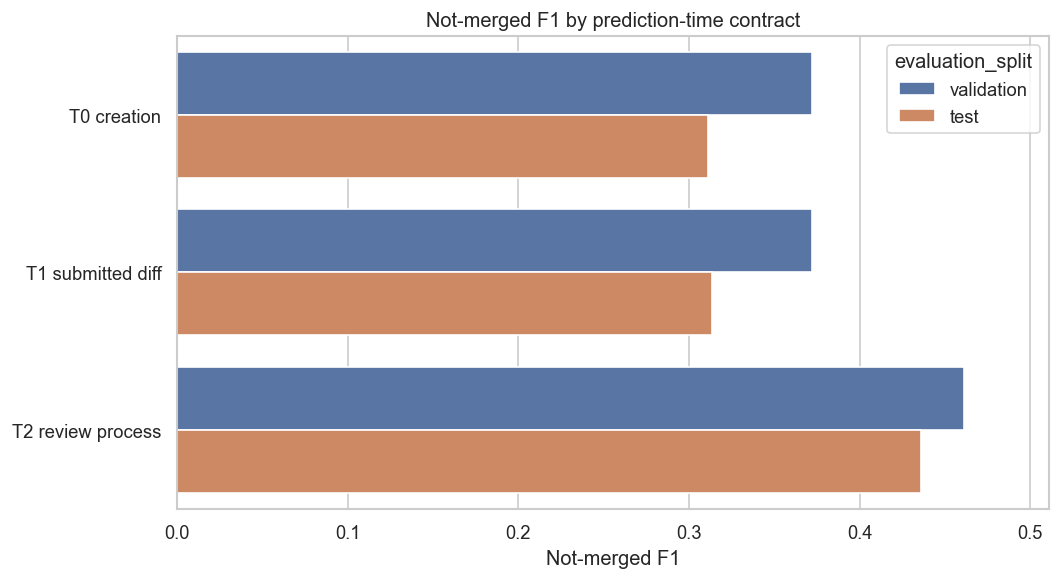

,calibration_method,model_sample_size,training_rows,calibration_rows,validation_rows,brier_score_not_merged,weighted_abs_calibration_error,average_precision_not_merged,roc_auc_merged,f1_not_merged
0,uncalibrated,180000,108000,36000,36000,0.1749,0.2918,0.3261,0.7456,0.3455
1,sigmoid,180000,108000,36000,36000,0.0857,0.0038,0.3261,0.7456,0.1227
2,isotonic,180000,108000,36000,36000,0.0857,0.0047,0.3144,0.7448,0.1358


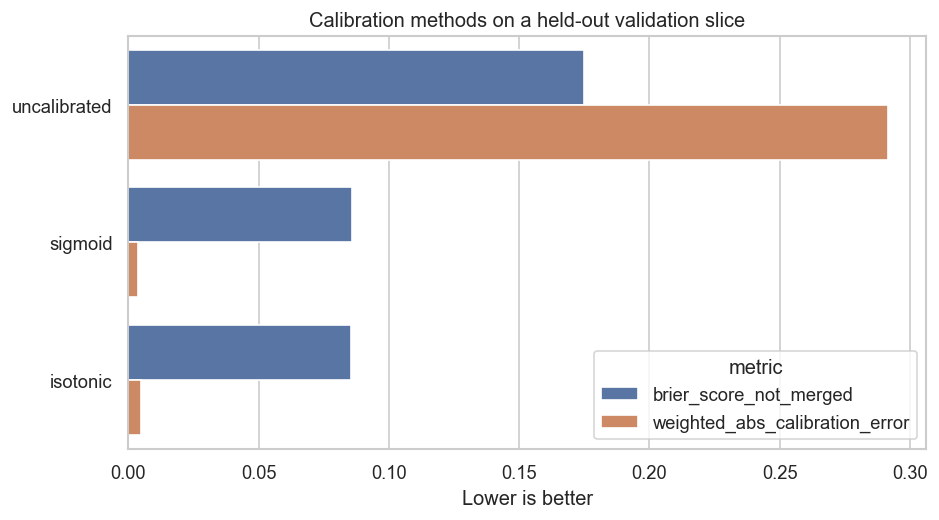

,benchmark,benchmark_scope,training_rows,validation_rows,validation_not_merged_rate,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,average_precision_not_merged
0,official_test,official_train_test_files,1045883,260195,10.8080,0.6504,0.2254,0.5154,0.3136,0.3013
1,temporal_holdout,500000_row_large_holdout,375000,125000,7.8824,0.6096,0.1911,0.3437,0.2456,0.1972
2,project_holdout,500000_row_large_holdout,372830,127170,11.5137,0.6396,0.2258,0.5040,0.3119,0.2488
3,creator_holdout,500000_row_large_holdout,375150,124850,10.1946,0.6497,0.2306,0.4819,0.3119,0.2763


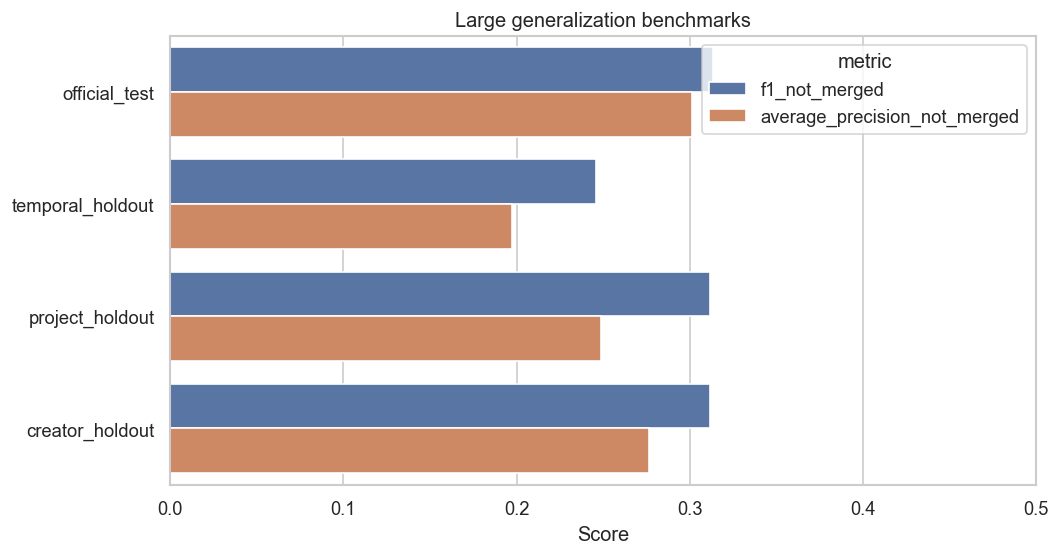

,baseline_model,comparison_model,metric,delta,ci_lower_95,ci_upper_95,bootstrap_mean,bootstrap_resamples,interpretation
0,Random forest balanced,Hist gradient boosting weighted,f1_not_merged,0.0347,0.0326,0.0367,0.0347,400,Positive delta favors the selected Random Fore...
1,Random forest balanced,Hist gradient boosting weighted,average_precision_not_merged,0.0294,0.0272,0.0314,0.0293,400,Positive delta favors the selected Random Fore...



**Prediction-time interpretation.** The contract table separates early PR-creation evidence from submitted-diff evidence and late review-process evidence. If T2 improves, that is not a better early predictor; it is evidence that the review process itself carries extra signal. The comment dataset is profiled but not joined because it lacks the numeric PRFeatures join keys, so the project avoids fabricating a linkage.

**Calibration interpretation.** Calibrated models are evaluated on a held-out slice with Brier score and weighted calibration error. A lower calibration score improves probability honesty even if F1 is similar.

**Model-delta interpretation.** Paired bootstrap intervals compare the selected model and histogram gradient boosting on the same validation cases. This prevents over-reading small leaderboard differences.


In [9]:
prediction_contract_comparison = evaluate_prediction_contracts(
    train_model,
    test_model,
    selected_model_name,
)
prediction_contract_comparison.to_csv(FINAL_DIR / "prediction_contract_comparison.csv", index=False)
display(prediction_contract_comparison[[
    "contract", "contract_label", "evaluation_split", "feature_count",
    "balanced_accuracy", "precision_not_merged", "recall_not_merged",
    "f1_not_merged", "average_precision_not_merged", "interpretation",
]])

fig, ax = plt.subplots(figsize=(9, 5))
contract_plot = prediction_contract_comparison.copy()
contract_plot["contract_display"] = contract_plot["contract"].map({
    "T0_creation": "T0 creation",
    "T1_diff": "T1 submitted diff",
    "T2_review_process": "T2 review process",
})
sns.barplot(
    data=contract_plot,
    x="f1_not_merged",
    y="contract_display",
    hue="evaluation_split",
    ax=ax,
)
ax.set_title("Not-merged F1 by prediction-time contract")
ax.set_xlabel("Not-merged F1")
ax.set_ylabel("")
ax.set_xlim(0, max(0.5, contract_plot["f1_not_merged"].max() + 0.05))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "prediction_contract_comparison.png", bbox_inches="tight")
plt.show()

calibration_models = calibration_model_comparison(
    train_model,
    selected_model_name,
    headline_safe_features,
    sample_size=180_000,
)
calibration_models.to_csv(FINAL_DIR / "calibration_model_comparison.csv", index=False)
display(calibration_models[[
    "calibration_method", "model_sample_size", "training_rows",
    "calibration_rows", "validation_rows", "brier_score_not_merged",
    "weighted_abs_calibration_error", "average_precision_not_merged",
    "roc_auc_merged", "f1_not_merged",
]])

calibration_plot = calibration_models.melt(
    id_vars="calibration_method",
    value_vars=["brier_score_not_merged", "weighted_abs_calibration_error"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=calibration_plot, x="score", y="calibration_method", hue="metric", ax=ax)
ax.set_title("Calibration methods on a held-out validation slice")
ax.set_xlabel("Lower is better")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_model_comparison.png", bbox_inches="tight")
plt.show()

full_benchmarks = full_generalization_benchmarks(
    train_model,
    test_model,
    selected_model_name,
    headline_safe_features,
    sample_size=500_000,
)
full_benchmarks.insert(0, "feature_policy", "headline_leakage_safer_features")
full_benchmarks.insert(1, "feature_count", len(headline_safe_features))
full_benchmarks.to_csv(FINAL_DIR / "full_generalization_benchmarks.csv", index=False)
display(full_benchmarks[[
    "benchmark", "benchmark_scope", "training_rows", "validation_rows",
    "validation_not_merged_rate", "balanced_accuracy",
    "precision_not_merged", "recall_not_merged", "f1_not_merged",
    "average_precision_not_merged",
]])

benchmark_plot = full_benchmarks.melt(
    id_vars="benchmark",
    value_vars=["f1_not_merged", "average_precision_not_merged"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=benchmark_plot, x="score", y="benchmark", hue="metric", ax=ax)
ax.set_title("Large generalization benchmarks")
ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xlim(0, max(0.5, benchmark_plot["score"].max() + 0.05))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "full_generalization_benchmarks.png", bbox_inches="tight")
plt.show()

paired_deltas = paired_model_delta_intervals(
    fitted_models,
    X_valid,
    y_valid,
    baseline_model=selected_model_name,
    comparison_model="Hist gradient boosting weighted",
    n_resamples=400,
)
paired_deltas.to_csv(FINAL_DIR / "paired_model_delta_intervals.csv", index=False)
display(paired_deltas)

display(Markdown(f'''
**Prediction-time interpretation.** The contract table separates early PR-creation evidence from submitted-diff evidence and late review-process evidence. If T2 improves, that is not a better early predictor; it is evidence that the review process itself carries extra signal. The comment dataset is profiled but not joined because it lacks the numeric PRFeatures join keys, so the project avoids fabricating a linkage.

**Calibration interpretation.** Calibrated models are evaluated on a held-out slice with Brier score and weighted calibration error. A lower calibration score improves probability honesty even if F1 is similar.

**Model-delta interpretation.** Paired bootstrap intervals compare the selected model and histogram gradient boosting on the same validation cases. This prevents over-reading small leaderboard differences.
'''))


## Unsupervised analysis: clustering PR profiles


,k,silhouette,inertia
0,2,0.5389,"1,290,509.1596"
1,3,0.1488,"1,176,388.2807"
2,4,0.1486,"1,099,719.9516"
3,5,0.1303,"1,060,916.2476"
4,6,0.1291,"994,740.2818"


,cluster,pr_count,merge_rate,not_merged_rate,median_churn_addition,median_churn_deletion,median_description_length,median_team_size,median_stars,median_open_pr_num,cluster_label,interpretation
0,0,67183,89.5700,10.4300,17.0000,5.0000,20.0000,6.0000,123.0000,12.0000,lower not-merged / larger-change / smaller-pro...,Cluster 0 groups lower not-merged / larger-cha...
1,1,2817,79.4500,20.5500,15.0000,5.0000,42.0000,51.0000,"21,147.0000",314.0000,higher not-merged / smaller-change / larger-pr...,Cluster 1 groups higher not-merged / smaller-c...


,cluster,cluster_label,pr_count,merge_rate,not_merged_rate,interpretation,pc1_explained_variance,pc2_explained_variance,two_component_explained_variance
0,0,lower not-merged / larger-change / smaller-pro...,67183,89.5700,10.4300,Cluster 0 groups lower not-merged / larger-cha...,0.1696,0.1175,0.2872
1,1,higher not-merged / smaller-change / larger-pr...,2817,79.4500,20.5500,Cluster 1 groups higher not-merged / smaller-c...,0.1696,0.1175,0.2872


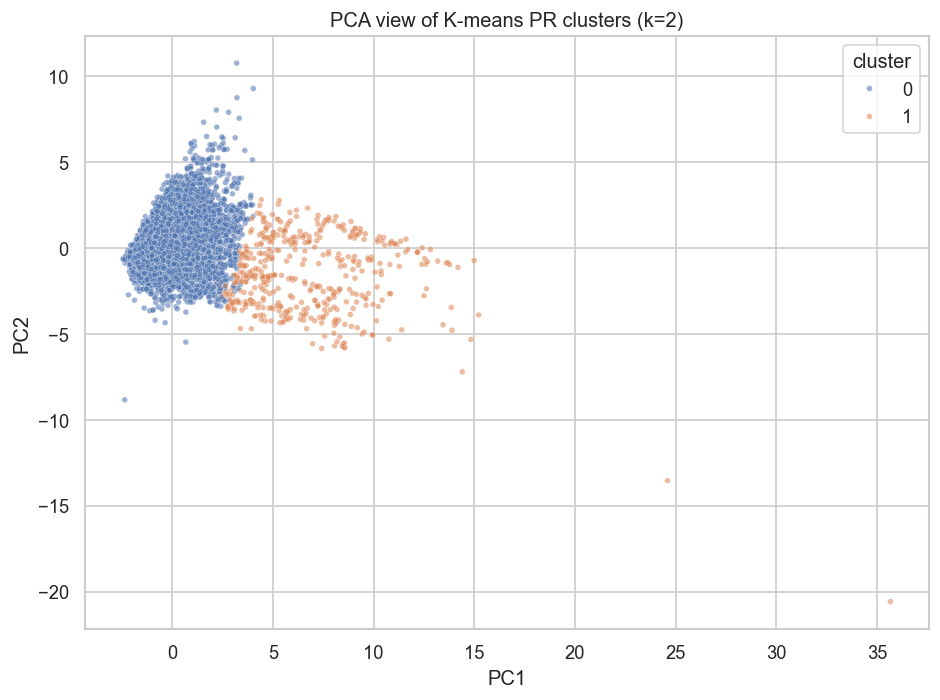


**Cluster interpretation.** The PCA figure is only a two-dimensional projection; PC1 and PC2 explain `0.287` of the transformed feature variance. The clustering is therefore used as a profile summary, not as proof of naturally separated PR types. The labels make the profile differences explicit and keep the unsupervised section tied to the research question.


In [10]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CLUSTER_SAMPLE_SIZE = 70_000
cluster_df = stratified_sample(train_model[analysis_usecols], CLUSTER_SAMPLE_SIZE)
X_cluster_raw = cluster_df[headline_safe_features]
cluster_preprocessor = make_preprocessor()
X_cluster = cluster_preprocessor.fit_transform(X_cluster_raw)

silhouette_rows = []
silhouette_eval_size = min(12_000, X_cluster.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
eval_indices = rng.choice(X_cluster.shape[0], size=silhouette_eval_size, replace=False)
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(X_cluster[eval_indices], labels[eval_indices])
    silhouette_rows.append({"k": k, "silhouette": score, "inertia": model.inertia_})

k_selection = pd.DataFrame(silhouette_rows)
k_selection.to_csv(FINAL_DIR / "cluster_k_selection.csv", index=False)
display(k_selection)

selected_k = int(k_selection.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
kmeans = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

profile_features = ["churn_addition", "churn_deletion", "description_length", "team_size", "stars", "open_pr_num"]
cluster_profile = (
    cluster_df.groupby("cluster")
    .agg(
        pr_count=(TARGET_COLUMN, "size"),
        merge_rate=(TARGET_COLUMN, "mean"),
        not_merged_rate=(TARGET_COLUMN, lambda values: 1 - values.mean()),
        **{f"median_{feature}": (feature, "median") for feature in profile_features},
    )
    .reset_index()
)
cluster_profile["merge_rate"] = (cluster_profile["merge_rate"] * 100).round(2)
cluster_profile["not_merged_rate"] = (cluster_profile["not_merged_rate"] * 100).round(2)
size_median = cluster_profile["median_churn_addition"].median()
team_median = cluster_profile["median_team_size"].median()
not_merged_median = cluster_profile["not_merged_rate"].median()
def label_cluster(row: pd.Series) -> str:
    risk = "higher not-merged" if row["not_merged_rate"] >= not_merged_median else "lower not-merged"
    size = "larger-change" if row["median_churn_addition"] >= size_median else "smaller-change"
    team = "larger-project" if row["median_team_size"] >= team_median else "smaller-project"
    return f"{risk} / {size} / {team}"
cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile["interpretation"] = cluster_profile.apply(
    lambda row: (
        f"Cluster {int(row['cluster'])} groups {row['cluster_label']} PRs. "
        f"It contains {int(row['pr_count']):,} sampled PRs with a {row['not_merged_rate']:.2f}% not-merged rate."
    ),
    axis=1,
)
cluster_profile.to_csv(FINAL_DIR / "cluster_profile.csv", index=False)
display(cluster_profile)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(X_cluster)
pca_variance = pca.explained_variance_ratio_
cluster_interpretation = cluster_profile[[
    "cluster", "cluster_label", "pr_count", "merge_rate",
    "not_merged_rate", "interpretation",
]].copy()
cluster_interpretation["pc1_explained_variance"] = pca_variance[0]
cluster_interpretation["pc2_explained_variance"] = pca_variance[1]
cluster_interpretation["two_component_explained_variance"] = pca_variance.sum()
cluster_interpretation.to_csv(FINAL_DIR / "cluster_interpretation.csv", index=False)
display(cluster_interpretation)
plot_points = pd.DataFrame(
    {
        "pc1": pca_points[:, 0],
        "pc2": pca_points[:, 1],
        "cluster": cluster_df["cluster"].astype(str),
        "merge_label": cluster_df[TARGET_COLUMN].map(TARGET_LABELS),
    }
)
plot_points = plot_points.sample(n=min(12_000, len(plot_points)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_points, x="pc1", y="pc2", hue="cluster", s=12, alpha=0.55, ax=ax)
ax.set_title(f"PCA view of K-means PR clusters (k={selected_k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "cluster_pca.png", bbox_inches="tight")
plt.show()

display(Markdown(f'''
**Cluster interpretation.** The PCA figure is only a two-dimensional projection; PC1 and PC2 explain `{pca_variance.sum():.3f}` of the transformed feature variance. The clustering is therefore used as a profile summary, not as proof of naturally separated PR types. The labels make the profile differences explicit and keep the unsupervised section tied to the research question.
'''))


## How this answers the assignment


In [11]:
assignment_coverage = pd.DataFrame(
    [
        {
            "requirement": "problem description and clarity",
            "weight_or_source": "10%",
            "status": "done",
            "evidence": "Research question, target, dataset scope, feature-availability boundary, and non-causal framing are stated at the start and conclusion.",
            "notebook_section": "Research question and dataset; Final interpretation",
            "report_section": "Executive Answer; Dataset and Feature-Availability Contract",
            "slide": "1, 3, 19",
            "artifact": "README.md; final_report.pdf; final_presentation.pdf",
        },
        {
            "requirement": "exploratory data analysis",
            "weight_or_source": "20%",
            "status": "done",
            "evidence": "Target imbalance, contributor history, project concentration, language-code context, skew/outliers, and class-conditioned differences are reported with numeric findings.",
            "notebook_section": "Data loading and audit; Exploratory data analysis",
            "report_section": "Exploratory Data Analysis",
            "slide": "4, 6, 7",
            "artifact": "eda_key_findings.csv; target_distribution_summary.csv; eda_safe_feature_patterns.png",
        },
        {
            "requirement": "empirical data analysis study",
            "weight_or_source": "20%",
            "status": "done",
            "evidence": "Supervised validation, final official test, prediction-time contracts, threshold tuning/stability, risk-band lift, calibration, error analysis, stress tests, feature-policy sensitivity, paired model deltas, and clustering are separated and compared.",
            "notebook_section": "Supervised modeling and validation comparison; Final evaluation; Prediction-time contracts, calibration, and statistical deltas; Unsupervised analysis",
            "report_section": "Supervised Study; Prediction-Time Contract Study; Risk Ranking, Calibration, and Error Analysis; Generalization and Robustness; Sensitivity and Unsupervised Profiles",
            "slide": "8-21",
            "artifact": "model_comparison.csv; final_test_metrics.csv; prediction_contract_comparison.csv; calibration_model_comparison.csv; full_generalization_benchmarks.csv; paired_model_delta_intervals.csv; test_prediction_risk_bands.csv; calibration_summary.csv; error_profile_summary.csv; threshold_stability.csv; stress_model_comparison.csv",
        },
        {
            "requirement": "algorithm comprehension",
            "weight_or_source": "10%",
            "status": "done",
            "evidence": "Algorithm comprehension table explains each model's role, reason for inclusion, and limitation.",
            "notebook_section": "Algorithm comprehension map",
            "report_section": "Supervised Study",
            "slide": "8",
            "artifact": "algorithm_comprehension.csv",
        },
        {
            "requirement": "data characteristics",
            "weight_or_source": "assignment note",
            "status": "done",
            "evidence": "Missingness, duplicates, imbalance, skew/outliers, leakage timing, PR-id integrity, split overlap, project concentration, comment-dataset join limits, and project correlation are explicitly handled.",
            "notebook_section": "Data loading and audit; Leakage-aware feature review; Exploratory data analysis",
            "report_section": "Dataset and Prediction-Time Contracts; Generalization and Robustness",
            "slide": "3-5, 14",
            "artifact": "data_quality_summary.csv; feature_timing_evidence.csv; prediction_contract_feature_map.csv; review_process_feature_audit.csv; comment_dataset_profile.csv; split_id_integrity.csv; split_overlap_summary.csv",
        },
        {
            "requirement": "main findings and conclusions",
            "weight_or_source": "10%",
            "status": "done",
            "evidence": "Final answer emphasizes moderate predictive association, risk-ranking usefulness, calibration limits, external-validity limits, and no deployment/causal claim.",
            "notebook_section": "Final interpretation",
            "report_section": "Executive Answer; Risk Ranking, Calibration, and Error Analysis; Threats to Validity",
            "slide": "1, 12-13, 20-22",
            "artifact": "final_report.pdf; final_presentation.pdf; error_analysis_key_findings.csv; self_review.md",
        },
        {
            "requirement": "notebook/code organization",
            "weight_or_source": "10%",
            "status": "done",
            "evidence": "Notebook is generated from a script, outputs are named, validator checks metrics and deliverables, and final report/slides are reproducible.",
            "notebook_section": "All generated notebook sections",
            "report_section": "Appendix Evidence Map",
            "slide": "18",
            "artifact": "scripts/build_analysis_notebooks.py; scripts/build_final_report.py; scripts/validate_final_outputs.py",
        },
        {
            "requirement": "slides and discussion support",
            "weight_or_source": "20%",
            "status": "done",
            "evidence": "Slide deck includes protocol, concrete EDA findings, results, robustness, threats, assignment coverage, and Q&A-ready takeaway.",
            "notebook_section": "How this answers the assignment",
            "report_section": "Appendix Evidence Map",
            "slide": "all",
            "artifact": "slides/final_presentation.md; slides/final_presentation.pdf",
        },
    ]
)
assignment_coverage.to_csv(FINAL_DIR / "assignment_coverage.csv", index=False)
display(assignment_coverage)
display(Markdown('''
**Grading map.** This section is deliberately redundant with the analysis so a reviewer can see that the notebook covers the requested project components. It does not add a new claim; it ties the evidence above back to the assignment.
'''))


,requirement,weight_or_source,status,evidence,notebook_section,report_section,slide,artifact
0,problem description and clarity,10%,done,"Research question, target, dataset scope, feat...",Research question and dataset; Final interpret...,Executive Answer; Dataset and Feature-Availabi...,"1, 3, 19",README.md; final_report.pdf; final_presentatio...
1,exploratory data analysis,20%,done,"Target imbalance, contributor history, project...",Data loading and audit; Exploratory data analysis,Exploratory Data Analysis,"4, 6, 7",eda_key_findings.csv; target_distribution_summ...
2,empirical data analysis study,20%,done,"Supervised validation, final official test, pr...",Supervised modeling and validation comparison;...,Supervised Study; Prediction-Time Contract Stu...,8-21,model_comparison.csv; final_test_metrics.csv; ...
3,algorithm comprehension,10%,done,Algorithm comprehension table explains each mo...,Algorithm comprehension map,Supervised Study,8,algorithm_comprehension.csv
4,data characteristics,assignment note,done,"Missingness, duplicates, imbalance, skew/outli...",Data loading and audit; Leakage-aware feature ...,Dataset and Prediction-Time Contracts; General...,"3-5, 14",data_quality_summary.csv; feature_timing_evide...
5,main findings and conclusions,10%,done,Final answer emphasizes moderate predictive as...,Final interpretation,"Executive Answer; Risk Ranking, Calibration, a...","1, 12-13, 20-22",final_report.pdf; final_presentation.pdf; erro...
6,notebook/code organization,10%,done,"Notebook is generated from a script, outputs a...",All generated notebook sections,Appendix Evidence Map,18,scripts/build_analysis_notebooks.py; scripts/b...
7,slides and discussion support,20%,done,"Slide deck includes protocol, concrete EDA fin...",How this answers the assignment,Appendix Evidence Map,all,slides/final_presentation.md; slides/final_pre...



**Grading map.** This section is deliberately redundant with the analysis so a reviewer can see that the notebook covers the requested project components. It does not add a new claim; it ties the evidence above back to the assignment.


## Final interpretation


In [12]:
best_validation = comparison.iloc[0]
default_test_row = final_metrics[final_metrics["threshold_label"] == "default_model_threshold"].iloc[0]
tuned_test_row = final_metrics[final_metrics["threshold_label"] == "validation_tuned_not_merged_f1"].iloc[0]
ultra_test_row = leakage_sensitivity[
    (leakage_sensitivity["feature_set"] == "ultra_conservative_features")
    & (leakage_sensitivity["evaluation_split"] == "test")
].iloc[0]
integrator_test_row = leakage_sensitivity[
    (leakage_sensitivity["feature_set"] == "integrator_assumed_features")
    & (leakage_sensitivity["evaluation_split"] == "test")
].iloc[0]
extended_test_row = leakage_sensitivity[
    (leakage_sensitivity["feature_set"] == "extended_timing_assumed_features")
    & (leakage_sensitivity["evaluation_split"] == "test")
].iloc[0]
contract_test = prediction_contract_comparison[
    prediction_contract_comparison["evaluation_split"] == "test"
].set_index("contract")
best_calibration = calibration_models.sort_values("brier_score_not_merged").iloc[0]
project_benchmark = full_benchmarks[full_benchmarks["benchmark"] == "project_holdout"].iloc[0]
paired_f1_delta = paired_deltas[paired_deltas["metric"] == "f1_not_merged"].iloc[0]
weakest_stress = stress_tests.sort_values("f1_not_merged").iloc[0]
top_cluster = cluster_profile.sort_values("not_merged_rate", ascending=False).iloc[0]
display(Markdown(f'''
### Answer to the Research Question

**Yes, PR-level features help explain and predict GitHub PR merge outcomes, but the signal is moderate and should be framed as moderate predictive association rather than causality.** The selected model is **{selected_model_name}**, chosen by validation not-merged F1. On the untouched test split:

- Default threshold balanced accuracy: `{default_test_row["balanced_accuracy"]:.3f}`
- Default threshold not-merged F1: `{default_test_row["f1_not_merged"]:.3f}`
- Tuned threshold: `{best_threshold:.3f}` from validation only
- Tuned threshold not-merged precision: `{tuned_test_row["precision_not_merged"]:.3f}`
- Tuned threshold not-merged recall: `{tuned_test_row["recall_not_merged"]:.3f}`
- Tuned threshold not-merged F1: `{tuned_test_row["f1_not_merged"]:.3f}`
- Tuned threshold not-merged average precision: `{tuned_test_row["average_precision_not_merged"]:.3f}`

**Confidence intervals.** The bootstrap intervals in `final_metric_confidence_intervals.csv` quantify sampling uncertainty around the final predictions. The `estimate` column is the observed test-set metric, while `bootstrap_mean` is reported separately. These intervals do not remove dataset or feature-timing bias, but they prevent the final notebook from over-reading tiny metric differences.

**Risk ranking and error analysis.** `test_prediction_risk_bands.csv` shows whether the score concentrates not-merged PRs in the highest-risk deciles, while `calibration_summary.csv` checks whether scores behave like literal probabilities. `error_profile_summary.csv` explains the tuned-threshold failure modes: missed not-merged PRs are the cases that look too much like merged PRs under the available feature contract, while false not-merged predictions are accepted PRs whose project context looks risky. This is why the final claim is ranking-oriented and moderate.

**Feature-policy sensitivity.** The ultra-conservative model uses only `{len(ultra_conservative_features)}` least-controversial fields and reaches test not-merged F1 `{ultra_test_row["f1_not_merged"]:.3f}`. The headline model excludes `{", ".join(integrator_assumed_extension_features)}` because source documentation describes it as integrator/reviewer experience; adding it back as an integrator-assumed sensitivity reaches test not-merged F1 `{integrator_test_row["f1_not_merged"]:.3f}` versus `{default_test_row["f1_not_merged"]:.3f}` for the headline default-threshold model. The extended timing-assumed model adds `{", ".join(timing_assumed_extension_features)}` and reaches test not-merged F1 `{extended_test_row["f1_not_merged"]:.3f}`. These checks show how much the conclusion depends on stronger availability assumptions.

**Prediction-time contract result.** The staged contract table is the upgraded answer. T0 PR-creation features reach test not-merged F1 `{contract_test.loc["T0_creation", "f1_not_merged"]:.3f}`; T1 submitted-diff features reach `{contract_test.loc["T1_diff", "f1_not_merged"]:.3f}`; T2 review-process features reach `{contract_test.loc["T2_review_process", "f1_not_merged"]:.3f}`. If T2 is stronger, it is not a better early model; it measures extra signal available after review starts. The separate comment dataset is profiled but not joined because the local files do not expose a reliable shared PR key.

**Calibration and model-delta result.** The best Brier score in the calibration comparison comes from `{best_calibration["calibration_method"]}` calibration with Brier `{best_calibration["brier_score_not_merged"]:.3f}` and weighted calibration error `{best_calibration["weighted_abs_calibration_error"]:.3f}`. The paired bootstrap F1 delta versus histogram gradient boosting is `{paired_f1_delta["delta"]:.3f}` with 95% interval `{paired_f1_delta["ci_lower_95"]:.3f}` to `{paired_f1_delta["ci_upper_95"]:.3f}`.

**Generalization stress tests.** `split_id_integrity.csv` confirms zero duplicate PR ids and zero exact train/test PR-id overlap. The official test split is still not a clean unseen-project split; `split_overlap_summary.csv` shows that many test PRs come from projects and creators already observed in training. The sampled stress tests therefore add temporal, project-group, and creator-group validation. The weakest sampled stress case is `{weakest_stress["stress_test"]}` with not-merged F1 `{weakest_stress["f1_not_merged"]:.3f}`, which should be discussed as evidence that the result weakens under stricter generalization.

The larger project-holdout benchmark reaches not-merged F1 `{project_benchmark["f1_not_merged"]:.3f}`, which is the strongest evidence that the official split is easier than unseen-project-style evaluation.

**Unsupervised result.** K-means identified `{selected_k}` PR profile clusters without using the target during fitting. Cluster `{int(top_cluster["cluster"])}` has the highest observed not-merged rate after profiling (`{top_cluster["not_merged_rate"]:.2f}%`) and is labeled `{top_cluster["cluster_label"]}`. This supports interpretation of PR profiles rather than serving as a separate predictor.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, closure-derived variables, target-adjacent success rates, and close-time PR evolution fields are held out of the headline model unless their availability before the outcome can be defended. The final supervised model is trained on the full training split, while repeated CV, clustering, and sample-size checks remain runtime-bounded diagnostics. Results are not causal and are not suitable for automated merge decisions; they should be framed as a reproducible course-scale empirical analysis.
'''))



### Answer to the Research Question

**Yes, PR-level features help explain and predict GitHub PR merge outcomes, but the signal is moderate and should be framed as moderate predictive association rather than causality.** The selected model is **Random forest balanced**, chosen by validation not-merged F1. On the untouched test split:

- Default threshold balanced accuracy: `0.650`
- Default threshold not-merged F1: `0.314`
- Tuned threshold: `0.578` from validation only
- Tuned threshold not-merged precision: `0.296`
- Tuned threshold not-merged recall: `0.364`
- Tuned threshold not-merged F1: `0.326`
- Tuned threshold not-merged average precision: `0.301`

**Confidence intervals.** The bootstrap intervals in `final_metric_confidence_intervals.csv` quantify sampling uncertainty around the final predictions. The `estimate` column is the observed test-set metric, while `bootstrap_mean` is reported separately. These intervals do not remove dataset or feature-timing bias, but they prevent the final notebook from over-reading tiny metric differences.

**Risk ranking and error analysis.** `test_prediction_risk_bands.csv` shows whether the score concentrates not-merged PRs in the highest-risk deciles, while `calibration_summary.csv` checks whether scores behave like literal probabilities. `error_profile_summary.csv` explains the tuned-threshold failure modes: missed not-merged PRs are the cases that look too much like merged PRs under the available feature contract, while false not-merged predictions are accepted PRs whose project context looks risky. This is why the final claim is ranking-oriented and moderate.

**Feature-policy sensitivity.** The ultra-conservative model uses only `12` least-controversial fields and reaches test not-merged F1 `0.273`. The headline model excludes `prior_review_num` because source documentation describes it as integrator/reviewer experience; adding it back as an integrator-assumed sensitivity reaches test not-merged F1 `0.373` versus `0.314` for the headline default-threshold model. The extended timing-assumed model adds `pr_succ_rate, requester_succ_rate, num_commits, src_churn, files_changed, test_churn` and reaches test not-merged F1 `0.315`. These checks show how much the conclusion depends on stronger availability assumptions.

**Prediction-time contract result.** The staged contract table is the upgraded answer. T0 PR-creation features reach test not-merged F1 `0.311`; T1 submitted-diff features reach `0.314`; T2 review-process features reach `0.436`. If T2 is stronger, it is not a better early model; it measures extra signal available after review starts. The separate comment dataset is profiled but not joined because the local files do not expose a reliable shared PR key.

**Calibration and model-delta result.** The best Brier score in the calibration comparison comes from `isotonic` calibration with Brier `0.086` and weighted calibration error `0.005`. The paired bootstrap F1 delta versus histogram gradient boosting is `0.035` with 95% interval `0.033` to `0.037`.

**Generalization stress tests.** `split_id_integrity.csv` confirms zero duplicate PR ids and zero exact train/test PR-id overlap. The official test split is still not a clean unseen-project split; `split_overlap_summary.csv` shows that many test PRs come from projects and creators already observed in training. The sampled stress tests therefore add temporal, project-group, and creator-group validation. The weakest sampled stress case is `project_group_holdout_sample` with not-merged F1 `0.249`, which should be discussed as evidence that the result weakens under stricter generalization.

The larger project-holdout benchmark reaches not-merged F1 `0.312`, which is the strongest evidence that the official split is easier than unseen-project-style evaluation.

**Unsupervised result.** K-means identified `2` PR profile clusters without using the target during fitting. Cluster `1` has the highest observed not-merged rate after profiling (`20.55%`) and is labeled `higher not-merged / smaller-change / larger-project`. This supports interpretation of PR profiles rather than serving as a separate predictor.

**Threats to validity.** Feature timing remains the main risk. Discussion, sentiment, CI progression, closure-derived variables, target-adjacent success rates, and close-time PR evolution fields are held out of the headline model unless their availability before the outcome can be defended. The final supervised model is trained on the full training split, while repeated CV, clustering, and sample-size checks remain runtime-bounded diagnostics. Results are not causal and are not suitable for automated merge decisions; they should be framed as a reproducible course-scale empirical analysis.
